# **Итоговый проект модуля 4: Прогноз отмены бронирования сети отелей UrbanStay**


Выполнил: Артем Буров DS12  
Ссылка на GiHub: https://github.com/TemaQDX/project_module_04_urbanstay  

---

Сеть отелей среднего сегмента **UrbanStay** работает стабильно: гости оставляют положительные отзывы, финансовые показатели в норме. Однако внутренняя аналитика выявила тревожную тенденцию — за последние два года каждый третий гость отменяет бронирование незадолго до заезда. Доля поздних отмен превысила 30%, из-за чего реальная загрузка отелей держится на уровне 60–70%, хотя по плану должна составлять более 80%.

Отмена брони — рядовое событие в гостиничном бизнесе. Но когда отмены становятся массовыми, систематическими и происходят в последний момент — за 12–24 часа до заселения — это превращается в серьёзную проблему. Найти новых постояльцев за такое короткое время почти невозможно: номер остаётся пустым, отель не получает деньги за проживание, теряет доход от дополнительных услуг и несёт косвенные потери из-за низкой нагрузки на персонал. Кроме того, массовые отмены ломают операционное планирование: персонал зря готовит номера и проводит уборку, купленные продукты портятся, договорённости с партнёрами — такси, экскурсоводами — срываются. Частые отмены ведут к нарушению условий сотрудничества с онлайн-платформами бронирования, что грозит штрафами, а также подрывают доверие партнёров, которые не хотят работать с ненадёжным отелем.

Сейчас UrbanStay компенсирует отмены с помощью овербукинга — намеренно оформляет больше бронирований, чем доступно номеров. Эта стратегия не так безответственна, как кажется: значительная часть гостей действительно отменяет бронь, так что проблем с размещением обычно не возникает. Но всегда есть риск, что приедут все — и изначальные, и новые гости, — и тогда часть из них некуда будет поселить, что ведёт к репутационному ущербу. По сути, овербукинг — неуправляемый процесс: отель полагается на опыт и интуицию, надеясь, что кто-то отменит. Это ненадёжная стратегия с высоким риском, и заказчик хочет перейти к управляемой модели, которая позволит точно рассчитывать экономическую эффективность принимаемых решений.

UrbanStay нужен инструмент, который заранее выявит рискованные бронирования, позволит принять превентивные меры — например, предложить неуверенным клиентам гибкие условия или альтернативные даты — и снизит долю поздних отмен с 30% до 10% за ближайшие шесть месяцев. Достижение этой цели повысит загрузку до 80% и более, сократит потери выручки от простоя номеров, наладит планирование работы персонала и закупок, укрепит доверие партнёров и высвободит ресурсы для развития сервиса. Полностью исключить отмены невозможно, но заказчик хочет не реагировать на проблему постфактум, а предотвращать её. При этом решение должно быть финансово эффективным — у компании должна быть возможность сравнить прибыль до и после внедрения модели.

---

## Постановка задачи

1. Разработать ML‑модель, прогнозирующую вероятность отмены бронирования. Она должна минимизировать финансовые потери сети отелей и по возможности повышать загрузку номеров. Её задача — предсказывать вероятность отмены брони по входным данным. Это позволит UrbanStay принимать обоснованные решения о повторном бронировании или сохранении брони.

2. Оценить экономическую эффективность модели. Для этого используйте три показателя:
    - Динамику доли отмен бронирования.
    - Динамику загрузки отелей.
    - Прирост дохода благодаря модели.

---

## Метрики оценки модели

### Стандартные метрики машинного обучения
Для базовой оценки качества модели применяются классические метрики:
- **Accuracy** — общая доля верных предсказаний;
- **Precision** — доля действительно отменённых бронирований среди тех, что модель предсказала как отменённые;
- **Recall** — доля верно предсказанных отмен среди всех фактических отмен;
- **F1‑мера** — гармоническое среднее Precision и Recall, полезно при дисбалансе классов.


### Бизнес‑метрики для оценки экономической эффективности

1. **IR (Incremental Revenue) — прирост дохода благодаря модели**  

   Показывает чистый финансовый эффект от внедрения модели через сравнение сценариев «до» и «после».  
   Формула:  
   $IR = IR_{после} - IR_{до}$  
   Относительный прирост дохода:  
   $Относительный\ IR = \frac{IR_{после} - IR_{до}}{IR_{до}} \times 100\%$  

   Компоненты расчёта:  
   - $IR_{до} = (TotalSuccess \times AvgRev) - (TotalCancellations \times LostRev)$  
     где $TotalSuccess$ — успешные брони, $AvgRev$ — средний доход с номера, $TotalCancellations$ — все отмены, $LostRev$ — упущенный доход с одной отмены.  
   - $IR_{после} = (TP \times PerRebooking) + (TN \times AvgRev) - (FP \times CostFP) - (FN \times LostRev)$  
     где $TP$ — верно предсказанные отмены, $PerRebooking$ — доход от повторной сдачи номера, $TN$ — верно предсказанные приезды, $FP$ — ложные срабатывания, $CostFP$ — издержки на одно ложное срабатывание, $FN$ — пропущенные отмены.  

   Фиксированные параметры для расчётов:  
   - $AvgRev = 64\ 500$ руб.;  
   - $CostFP = 7\ 000$ руб.;  
   - $LostRev = 64\ 500$ руб.;  
   - $PerRebooking = 45\ 000$ руб.  

2. **Динамика доли отмен бронирования**  

   Отражает снижение частоты отмен благодаря работе модели.  

   Формула:  

   $Динамика\ отмен = \frac{Доля\ отмен_{до} - Доля\ отмен_{после}}{Доля\ отмен_{до}} \times 100\%$  

   где $Доля\ отмен_{до} = \frac{Число\ отмен_{до}}{Число\ бронирований_{до}}$,  

   $Доля\ отмен_{после} = \frac{Число\ отмен_{после}}{Число\ бронирований_{после}}$.  

3. **Динамика загрузки отеля**  

   Показывает изменение эффективности использования номерного фонда.  

   Формула:  

   $Динамика\ загрузки = \frac{Загрузка_{до} - Загрузка_{после}}{Загрузка_{до}} \times 100\%$  

   где $Загрузка_{до} = \frac{Число\ занятых\ номеров_{до}}{Число\ доступных\ номеров_{до}}$,  

   $Загрузка_{после} = \frac{Число\ занятых\ номеров_{после}}{Число\ доступных\ номеров_{после}}$.  


### Методика расчёта
Для корректной оценки эффекта модель тестируется на одной и той же выборке:  
- Значения «до» рассчитываются по фактическим данным ($y_{test}$).  
- Значения «после» — по предсказаниям модели ($y_{pred}$) на тех же данных.  
Это позволяет изолировать эффект от работы модели и исключить влияние внешних факторов. Итоговые метрики представляются в абсолютных и относительных (процентных) значениях для наглядной интерпретации бизнес‑эффекта.

---


## Постановка задачи на языке машинного обучения

### Формулировка задачи
Задача относится к классу **бинарной классификации с бизнес‑ориентированной оптимизацией порога**.  

Целевая переменная:  
- $y = 1$, если бронирование будет отменено (статус `booking_status = отказ_брони`);  
- $y = 0$, если бронирование останется активным (статус `booking_status = нет_отказа`).  

Цель модели — **максимизировать Incremental Revenue (IR)**, то есть прирост дохода сети UrbanStay за счёт своевременного выявления рискованных бронирований. Для этого необходимо подобрать оптимальный порог классификации, при котором совокупный финансовый эффект (выгода от повторной сдачи номеров минус издержки от ложных срабатываний и упущенной выгоды от пропущенных отмен) будет максимальным, **при соблюдении целевых KPI по балансу метрик**.


### Доступные данные и формирование признаков

#### Таблица `hotel_bookings` (35 341 запись)
На её основе формируются следующие группы признаков:
- **Идентификационные и временные**: `booking_id` (для связывания с отзывами), `booking_date`, `days_until_checkin` (критичен для оценки «горизонта риска» — чем ближе заезд, тем выше вероятность поздней отмены).  
- **Характеристики бронирования**: `room_type`, `booking_value`, `meal_plan`, `parking_included`, `customer_special_requests`.  
- **Состав гостей**: `adult_count`, `child_count`, `weekend_nights`, `weekday_nights` (позволяют оценить тип поездки — семейный, уикенд‑отдых и т. п.).  
- **Поведенческие признаки клиента**: `returning_customer`, `previous_cancellations`, `previous_no_shows` (прямые индикаторы склонности к отменам и неявкам).  
- **Канал бронирования**: `sales_channel` (офлайн/онлайн/корпоративный) — может коррелировать с дисциплиной клиента и политикой отмены.  

#### Таблица `hotel_reviews` (25 177 записей)
Используется для обогащения профиля клиента и контекста бронирования:
- **Связь с бронированием**: `customer_id` и `booking_id` позволяют привязать отзывы к конкретным гостям и их прошлым/текущим бронированиям.  
- **Количественные оценки**: `stay_rating` (1–5) — агрегируется в средний рейтинг клиента, долю высоких/низких оценок.  
- **Текстовые данные**: `review_text` — источник для извлечения скрытых паттернов поведения через NLP:  
  - тональность отзыва (позитивная/негативная/нейтральная);  
  - тематические признаки (например, «жалобы на сервис», «похвалы за чистоту») — могут косвенно указывать на лояльность и предсказуемость клиента;  
  - частота и характер обратной связи (активный комментатор vs молчаливый гость).  


### План решения задачи в терминах ML‑пайплайна

#### Этап 1. Подготовка данных
1. **Загрузка данных из Postgres** — извлечение таблиц `hotel_bookings` и `hotel_reviews` в аналитическое окружение.  
2. **Исследовательский анализ данных (EDA)** — проверка распределения целевой переменной (ожидаемый дисбаланс ~30% отмен), анализ пропусков, проверка согласованности дат (`booking_date`, `review_date`), выявление аномалий в числовых признаках.  
3. **Объединение данных** — соединение таблиц по `booking_id` и `customer_id` с учётом временного окна: в признаки для текущего бронирования включаются только отзывы, оставленные **до** момента принятия решения о риске отмены (например, за 7–30 дней до заезда).  
4. **Feature Engineering** — создание новых признаков. Например:  
   - агрегированные метрики по истории клиента: средний `stay_rating`, доля негативных отзывов, количество отзывов, средняя длительность проживания;  
   - поведенческие индексы: отношение `previous_cancellations` к общему числу бронирований, доля неявок (`previous_no_shows`);  
   - NLP‑признаки из `review_text`: тональность (sentiment score), TF‑IDF‑векторы для ключевых тем (сервис, чистота, питание), бинарные флаги («жаловался на персонал», «хвалил расположение»);  
   - временные признаки: день недели заезда, признак «праздничный период», сезонность (месяц/квартал).  

#### Этап 2. Моделирование
1. **Выбор и обучение моделей** — обучение не менее двух моделей из списка: Random Forest, CatBoost, LightGBM, XGBoost. CatBoost и LightGBM предпочтительны из‑за хорошей работы с категориальными признаками (`room_type`, `sales_channel`, `meal_plan`) и дисбалансом.  
2. **Калибровка лучшей модели** — применение Isotonic Regression или Platt Scaling для приведения предсказанных вероятностей к реальным частотам отмен. Это критично для корректного расчёта IR.  
3. **Подбор оптимального порога классификации** — на основе откалиброванных вероятностей и заданных бизнес‑параметров ($AvgRev = 64\ 500$, $CostFP = 7\ 000$, $LostRev = 64\ 500$, $PerRebooking = 45\ 000$) рассчитывается IR для диапазона порогов (например, от 0.1 до 0.9). Выбирается порог, максимизирующий IR **при условии соблюдения целевых KPI**.  
4. **Оценка стабильности метрик** — сравнение матрицы ошибок и значения IR на калибровочной и тестовой выборках. Проверка устойчивости порога: если оптимальный порог сильно «плавает» между выборками, требуется дополнительная регуляризация или пересмотр признаков.  
5. **Анализ важности признаков** — интерпретация модели через SHAP‑значения или важность признаков в ансамбле. Особое внимание — признакам из `previous_cancellations`, `days_until_checkin`, NLP‑метрикам из отзывов: они должны быть среди топ‑5 по влиянию.  

#### Этап 3. Расчёт экономической эффективности модели

**Цель этапа** — оценить, насколько выгодно внедрять выбранную модель в работу отеля: какой экономический эффект она даёт и укладываются ли ключевые метрики в заданный уровень. Если расчёты покажут, что какой‑либо показатель не достигает необходимого уровня, это сигнал к доработке модели — пересмотру порога классификации, добавлению новых признаков, замене модели или изменению предобработки данных. Экспериментируем, пока модель не станет удовлетворять всем требованиям бизнеса.

**Модель должна достичь следующего баланса метрик**:  
- доля отмен после внедрения — **не более 10%**;  
- загрузка отеля не должна уменьшиться больше чем на **8%**;  
- относительный IR должен составить **не менее 50%**.  

**Шаг 4. Интерпретация результатов**  
На основе рассчитанных показателей делается вывод о том, удалось ли достичь целевых значений для бизнеса. Если хотя бы один показатель не достигает цели, это основание для итеративной доработки: пересмотра порога, набора признаков, выбора модели или предобработки данных.  

Оценка успешности проводится на тестовой выборке. При другом размере выборки значения показателей могут быть иными, так как количество бронирований будет отличаться. Тем не менее работа с тестовой выборкой — разумное ограничение проекта: его цель — именно на текущей тестовой выборке показать экономическую привлекательность ML‑решения для отеля.


#### Этап 4. Оформление выводов
Подготовка итогового отчёта, включающего:
- описание качества модели с точки зрения ML‑метрик (Precision, Recall, F1, AUC‑ROC) и бизнес‑метрик (IR, динамика отмен и загрузки);  
- подтверждение достижения целевых KPI (доля отмен ≤ 10%, снижение загрузки ≤ 8%, относительный IR ≥ 50%);  
- рекомендации по внедрению: выбранный порог, правила обработки предсказаний (например, при вероятности >0.7 — предлагать гостю перенос или предлагать номер другому клиенту), интеграция в CRM/PMS‑систему;  
- список ключевых признаков для мониторинга и возможных доработок модели (учёт сезонности, добавление данных о локальных событиях);  
- оценку рисков и ограничений (чувствительность к сезонным колебаниям, изменениям в политике отмены, задержкам в получении отзывов).  

---


## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

In [1]:
# Импорт библиотек подключения к БД Postgres
from sqlalchemy import create_engine

# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки работы с текстом
from collections import Counter
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
from phik import phik_matrix

# Загрузка модулей sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, f1_score, accuracy_score, recall_score, precision_score, brier_score_loss, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedShuffleSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier

# Импортируем XGBoost для задачи регрессии
from xgboost import XGBClassifier
from xgboost import plot_importance
# Импортируем LightGBM для задачи регрессии
from lightgbm import LGBMClassifier
# Импортируем CatBoost для задачи регрессии
from catboost import CatBoostClassifier

# Импорт Optuna
import optuna

# Модули для построения диаграммы калибровки
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Импорт shap
import shap

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
import re
import cyrtranslit

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

RANDOM_SEED = 57
hlink = 'https://code.s3.yandex.net/datasets/'

## Подготовка функций и метрик

In [2]:
# =========================
# Функция оптимизации датафрейма

def optimize_dataframe(df: pd.DataFrame, col_translation: dict | None = None) -> pd.DataFrame:
    """
    Оптимизирует имена колонок и типы данных в DataFrame.
    
    Параметры:
        df: входной DataFrame.
        col_translation: словарь {русское_имя: английское_имя}. Если None или ключ отсутствует,
                          применяется транслитерация. Для уже английских имён — только snake_case.
    
    Возвращает:
        Оптимизированный DataFrame.
    """

    # 0. Функция формирования уникальных имён (на случай дублей после транслитерации)
    def make_unique_columns(cols):
        seen = {}
        new_cols = []
        for c in cols:
            if c not in seen:
                seen[c] = 1
                new_cols.append(c)
            else:
                seen[c] += 1
                new_cols.append(f"{c}_{seen[c]}")
        return new_cols

    # 1. Замена по словарю ИЛИ транслитерация
    def normalize_col_name(col: str) -> str:
        col = str(col).strip()

        # Если имя уже английское (нет кириллицы) — сразу к snake_case
        if not any('а' <= ch <= 'я' or 'А' <= ch <= 'Я' for ch in col):
            return col

        # Если есть перевод в словаре — используем его
        if col_translation and col in col_translation:
            return col_translation[col]

        # Иначе — транслитерация
        return cyrtranslit.to_latin(col, 'ru')

    df.columns = df.columns.map(normalize_col_name)

    # 2. Приводим к нижнему регистру
    df.columns = df.columns.astype(str).str.lower()

    # 3. Убираем апострофы и кавычки отдельно (это частая проблема cyrtranslit)
    df.columns = df.columns.str.replace(r"['\"‘’`]", "", regex=True)

    # 4. Заменяем любые не-буквенно-цифровые символы (кроме подчёркивания) на _
    df.columns = df.columns.str.replace(r'[^a-z0-9_]', '_', regex=True)

    # 5. Схлопываем множественные подчёркивания и убираем их по краям
    df.columns = df.columns.str.replace(r'_+', '_', regex=True).str.strip('_')

    # 6. Защита от пустых имён колонок
    empty_cols = df.columns == ''
    if empty_cols.any():
        for i, col in enumerate(df.columns):
            if col == '':
                df.columns.values[i] = f'col_{i}'

    # 7. Делаем имена уникальными (на случай дублей после транслитерации)
    df.columns = make_unique_columns(df.columns)

    # 8. Оптимизация типов float
    float_cols = df.select_dtypes(include=['float64', 'float32']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # 9. Оптимизация типов int
    int_cols = df.select_dtypes(include=['int64', 'int32']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

# =========================
# Анализ пропущенных значений

def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        print("Пропусков в данных нет")
        return
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))


# =========================
# bar chart
def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Число наблюдений',
    title='Столбчатая диаграмма',
    top_n=5
):
    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Подписи абсолютных значений
    for i, v in enumerate(value_counts):
        y_offset = 0.005 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    # Проценты в рамочке с тёмно‑серым фоном
    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        text_obj = ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )
        # Добавляем рамку с тёмно‑серым фоном
        text_obj.set_bbox(dict(facecolor='#333333', edgecolor='none', boxstyle='round,pad=0.3'))

    plt.tight_layout()
    plt.show()

# ========================
# histogram
def histogram_chart(df, attr='Признак', bins=10, kde=True, figsize=(10,6), title_text='Распределение признака', ylabel='Число наблюдений', xlabel='Признак'):
    _, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=df, x=attr, bins=bins, ax=ax, kde=kde)
    plt.title(title_text)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    median_val = df[attr].median()
    mean_val = df[attr].mean()
    plt.axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val:.1f}')
    plt.axvline(mean_val, color='purple', linestyle='-.', label=f'Средняя: {mean_val:.1f}')
    plt.legend()
    plt.show()

# =========================
# boxplot
def boxplot_chart(df, feature_list, diagram_name='Диаграммы размаха значений количественных признаков'):
    n_plots = len(feature_list)
    _, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(12, 2 * n_plots), squeeze=False)
    
    for i, feature in enumerate(feature_list):
        df[feature].plot.box(ax=axes[i, 0], vert=False)
        axes[i, 0].set_title(f'Boxplot: {feature}')
        axes[i, 0].tick_params(axis='x', labelrotation=0)
        axes[i, 0].grid(axis='x', alpha=0.5)

    plt.suptitle(diagram_name, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


# =========================
# phik heatmap
def phik_coolwarm_matrix(df, target_var, interval_cols, matrix_view=True, figsize=(12, 12)):
    
    plt.figure(figsize=figsize)
    correlation_matrix = df.phik_matrix(interval_cols=interval_cols)
    if matrix_view:
        data_heatmap = correlation_matrix
    else:
        data_heatmap = correlation_matrix.loc[correlation_matrix.index != target_var][[target_var]].sort_values(by=target_var, ascending=False)
    sns.heatmap(data_heatmap,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
            )
    plt.yticks(rotation=0)
    plt.title('Тепловая карта коэффициента Phik \n')
    plt.show()

# ============================================================
# Бизнес‑метрики для оценки экономической эффективности
# ============================================================

# Фиксированные параметры для расчётов
AVG_REV = 64_500         # Средний доход с номера, руб.
COST_FP = 7_000          # Издержки на одно ложное срабатывание, руб.
LOST_REV = 64_500        # Упущенный доход с одной отмены, руб.
PER_REBOOKING = 45_000   # Доход от повторной сдачи номера, руб.


def incremental_revenue(y_true, y_pred):
    """
    Incremental Revenue — прирост дохода благодаря модели.

    Параметры:
        y_true — истинные метки (1 = отмена, 0 = приезд).
        y_pred — предсказанные метки.

    Возвращает:
        ir_value     — абсолютный прирост дохода, руб.
        ir_relative  — относительный прирост дохода, %.
        ir_before    — доход без модели, руб.
        ir_after     — доход с моделью, руб.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Компоненты матрицы ошибок
    tp = np.sum((y_pred == 1) & (y_true == 1))   # верно предсказанные отмены
    tn = np.sum((y_pred == 0) & (y_true == 0))   # верно предсказанные приезды
    fp = np.sum((y_pred == 1) & (y_true == 0))   # ложные срабатывания
    fn = np.sum((y_pred == 0) & (y_true == 1))   # пропущенные отмены

    total_success = tn + fp        # все фактические приезды (без модели)
    total_cancellations = tp + fn  # все фактические отмены (без модели)

    # Доход без модели: выручка от приездов минус потери от отмен
    ir_before = total_success * AVG_REV - total_cancellations * LOST_REV

    # Доход с моделью: перебронирование + приезды − штрафы FP − потери FN
    ir_after = tp * PER_REBOOKING + tn * AVG_REV - fp * COST_FP - fn * LOST_REV

    # Прирост
    ir_value = ir_after - ir_before
    ir_relative = (ir_value / ir_before) if ir_before != 0 else 0.0

    return ir_value, ir_relative, ir_before, ir_after


def cancellation_dynamics(y_true, y_pred):
    """
    Динамика доли отмен бронирования.

    Без модели отменами считаются все фактические отмены.
    С моделью — только пропущенные (FN), поскольку пойманные (TP)
    перебранированы и не приводят к потере номера.

    Возвращает:
        dynamics    — снижение доли отмен, %.
        rate_before — доля отмен без модели.
        rate_after  — доля отмен с моделью.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    total = len(y_true)

    total_cancellations = np.sum(y_true == 1)  # все фактические отмены

    rate_before = total_cancellations / total if total != 0 else 0.0

    # С моделью «потерянными» остаются только пропущенные отмены
    fn = np.sum((y_pred == 0) & (y_true == 1))
    rate_after = fn / total if total != 0 else 0.0

    dynamics = ((rate_before - rate_after) / rate_before) if rate_before != 0 else 0.0

    return dynamics, rate_before, rate_after


def occupancy_dynamics(y_true, y_pred):
    """
    Динамика загрузки отеля.

    Без модели занятыми считаются все фактические приезды.
    С моделью — приезды (TN + FP) плюс перебронированные номера (TP).
    Пропущенные отмены (FN) оставляют номер пустым.

    Возвращает:
        dynamics         — изменение загрузки, %.
        occupancy_before — загрузка без модели.
        occupancy_after  — загрузка с моделью.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    total = len(y_true)

    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    # Без модели: занятые = все фактические приезды
    occupancy_before = (tn + fp) / total if total != 0 else 0.0

    # С моделью: занятые = приезды (TN) + ложно предсказанные, но приехавшие (FP)
    #           + перебронированные номера (TP); FN — пустые
    occupancy_after = (tn + tp + fp) / total if total != 0 else 0.0

    dynamics = ((occupancy_before - occupancy_after) / occupancy_before) if occupancy_before != 0 else 0.0

    return dynamics, occupancy_before, occupancy_after

# ============================================================
# Функция обновления датасета с метриками
# ============================================================

def update_metrics_df(metrics_dict, model_name, df_in=None):
    """
    Усредняет метрики кросс-валидации по фолдам и добавляет строку в таблицу.

    Параметры:
        metrics_dict — результат cross_validate (словарь с ключами 'test_...').
        model_name   — название модели для столбца 'model'.
        df_in        — существующая таблица с метриками (None для создания новой).

    Возвращает:
        df_out — таблица с добавленной (или обновлённой) строкой.
    """

    def data_row(metrics_dict=metrics_dict, model_name=model_name):
        df_row = pd.DataFrame(metrics_dict).mean().round(4).to_frame().T
        column_names = [col for col in df_row.columns if col.startswith('test_')]
        df_row = df_row[column_names]
        df_row.columns = [col.replace('test_', '', 1) for col in column_names if col.startswith('test_')]
        df_row['model'] = model_name
        cols = ['model'] + [col for col in df_row.columns if col != 'model']
        return df_row[cols]

    if df_in is None:
        df_out = data_row(metrics_dict, model_name)
        return df_out

    if model_name in df_in['model'].values:
        df_in = df_in[df_in['model'] != model_name]

    df_out = pd.concat([df_in, data_row(metrics_dict, model_name)], ignore_index=True)

    return df_out

# ============================================================
# Функция форматирования таблицы результатов
# ============================================================

def format_cv_results(df: pd.DataFrame):
    """
    Возвращает отформатированный Styler для таблицы результатов кросс-валидации.
    
    Параметры:
        df — DataFrame с метриками (как df_cv_results).
    
    Возвращает:
        pd.Styler с нужным форматированием колонок.
    """
    format_dict = {
        'accuracy': '{:,.4f}',
        'precision': '{:,.4f}',
        'recall': '{:,.4f}',
        'f1': '{:,.4f}',
        'ir': '{:,.0f}',
        'ir_relative': '{:,.4f}',
        'ir_before': '{:,.0f}',
        'ir_after': '{:,.0f}',
        'cancellation_dynamics': '{:,.4f}',
        'cancellation_rate_before': '{:,.4f}',
        'cancellation_rate_after': '{:,.4f}',
        'occupancy_dynamics': '{:,.4f}',
        'occupancy_before': '{:,.4f}',
        'occupancy_after': '{:,.4f}',
    }
    # Оставляем только те колонки, которые реально есть в датафрейме, чтобы не было ошибок
    format_subset = {k: v for k, v in format_dict.items() if k in df.columns}
    
    return df.style.format(format_subset)



## Этап 1: подготовка данных

### 1.1 Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия нужных вам таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).

In [3]:
# Задаем параметры и создаем подключение

db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-scientist-hotels' # название базы данных
            }

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

engine = create_engine(connection_string) 

In [4]:
%%time
# Выгружаем данные из БД

query_hotel_bookings = '''
SELECT * FROM public.hotel_bookings
'''

query_hotel_reviews = '''
SELECT * FROM public.hotel_reviews
'''

df_hotel_bookings_load_pg = pd.read_sql_query(query_hotel_bookings, con=engine)
df_hotel_reviews_load_pg = pd.read_sql_query(query_hotel_reviews, con=engine)

print("Данные из БД Postgres загружены")

Данные из БД Postgres загружены
CPU times: total: 359 ms
Wall time: 6.61 s


In [5]:
# Оптимизируем датасеты
df_hotel_bookings = optimize_dataframe(df_hotel_bookings_load_pg.copy())
df_hotel_reviews = optimize_dataframe(df_hotel_reviews_load_pg.copy())

# Удаляем первичные загрузки, они более не понадобятся
del(df_hotel_bookings_load_pg)
del(df_hotel_reviews_load_pg)

print("Датасеты оптимизированы")
print("Первичные загрузки удалены")

Датасеты оптимизированы
Первичные загрузки удалены


In [6]:
# Посмотрим структуру датафрейма таблицы hotel_bookings
df_hotel_bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int16  
 4   child_count                35341 non-null  int8   
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int8   
 7   previous_no_shows          35341 non-null  int8   
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int16  
 11  weekday_nights             35341 non-null  int8   
 12  weekend_nights             35341 non-null  int8   
 13  meal_plan                  35341 non-null  str    
 14  p

In [7]:
# Выведем первые строки для знакомства с данными hotel_bookings
df_hotel_bookings.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [8]:
# Посмотрим структуру датафрейма таблицы hotel_reviews
df_hotel_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  str   
 1   booking_id   25177 non-null  str   
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int8  
 4   review_text  25177 non-null  str   
dtypes: int8(1), object(1), str(3)
memory usage: 811.5+ KB


In [9]:
# Выведем первые строки для знакомства с данными hotel_reviews
df_hotel_reviews.head()

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


### Комментарий по итогам загрузки данных

Загрузка данных из БД Postgres прошла успешно, на этапе загрузки сразу выполнена оптимизация датафреймов с помощью функции `optimize_dataframe`.

**Датасет `df_hotel_bookings`:**
- Количество строк: 35 341.
- Количество признаков: 17.
- Основные типы данных: `str` (5 колонок), `int8` (6 колонок), `bool` (2 колонки), `int16` (2 колонки), `float64` (1 колонка), `object` (1 колонка).
- Пропуски отсутствуют — все признаки заполнены на 100 %.
- Ключевые признаки включают идентификаторы брони и даты, демографические параметры (количество взрослых/детей), поведенческие метрики клиента (возвращаемость, предыдущие отмены и no‑show), параметры бронирования (статус, стоимость, дни до заезда, тип питания, тип номера и др.).

**Датасет `df_hotel_reviews`:**
- Количество строк: 25 177.
- Количество признаков: 5.
- Типы данных: `str` (3 колонки), `int8` (1 колонка), `object` (1 колонка).
- Пропуски не обнаружены — все значения присутствуют.
- В составе данных: идентификатор клиента и брони, дата отзыва, рейтинг пребывания и текстовый отзыв.

---

### 1.2 Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

In [10]:
# =======================
# Приведение типов данных
# =======================

# === target ===
# Целевая переменная booking_status
target = 'booking_status'

# Приводим целевую переменную к бинарному виду (1/0)
df_hotel_bookings[target] = df_hotel_bookings[target].map({'нет_отказа': 0, 'отказ_брони': 1})
df_hotel_bookings[target] = pd.to_numeric(df_hotel_bookings[target], downcast='integer')

# === datetime ===
# Даты приводим к формату datetime
df_hotel_bookings['booking_date'] = pd.to_datetime(df_hotel_bookings['booking_date'], format='%Y-%m-%d')
df_hotel_reviews['review_date'] = pd.to_datetime(df_hotel_reviews['review_date'], format='%Y-%m-%d')

# === bool ===
# Приведем тип bool к int
for col in df_hotel_bookings.select_dtypes(include='bool'):
    df_hotel_bookings[col] = pd.to_numeric(df_hotel_bookings[col].astype('int'), downcast='integer')


# =====================================
# Распределение признаков по категориям 
# =====================================

# === Числовые признаки ===
numerical_features_hb = ['booking_value', 'days_until_checkin'] 

# === Порядковые признаки ===
ordinal_features_hb = ['adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 'weekday_nights', 'weekend_nights', 'customer_special_requests']

# === Категориальные признаки ===
categorical_features_hb = [x for x in df_hotel_bookings.select_dtypes(include='str').columns.to_list() if x not in ['booking_id', 'booking_status']]

# === Бинарные признаки ===
binary_features_hb = ['returning_customer', 'parking_included']


In [11]:
print('===hotel_booking===')
print('Целевая переменная:', target)
print('Числовые признаки hotel_booking:', numerical_features_hb)
print('Порядковые признаки hotel_booking:', ordinal_features_hb)
print('Категориальные признаки hotel_booking:', categorical_features_hb)
print('Бинарные категориальные признаки hotel_booking:', binary_features_hb)


===hotel_booking===
Целевая переменная: booking_status
Числовые признаки hotel_booking: ['booking_value', 'days_until_checkin']
Порядковые признаки hotel_booking: ['adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 'weekday_nights', 'weekend_nights', 'customer_special_requests']
Категориальные признаки hotel_booking: ['sales_channel', 'meal_plan', 'room_type']
Бинарные категориальные признаки hotel_booking: ['returning_customer', 'parking_included']


#### Комментарий

Что сделано и зачем:
- Целевая переменная `booking_status` приведена к бинарному виду (1 — отказ_брони, 0 — нет_отказа) и типизирована как integer. Это необходимо для корректной работы ML‑моделей (в т. ч. градиентного бустинга, RandomForest и др.) и единообразия метрик (precision/recall/F1). `downcast='integer'` экономит память — критично при масштабировании пайплайна.
- Даты (`booking_date`, `review_date`) приведены к типу datetime: это позволяет в дальнейшем извлекать временные признаки (день недели, месяц, сезонность и т. п.) и строить фичи, важные для прогноза отмен (например, зависимость от близости заезда).
- Булевы столбцы переведены в int (0/1): это упрощает пайплайн, делает типы консистентными и избегает потенциальных ошибок в sklearn/CatBoost/LightGBM.
- Признаки распределены по семантическим группам (числовые, порядковые, категориальные, бинарные). Такое разделение нужно для гибкой настройки preprocessing‑пайплайна: например, для категориальных — OneHot/Target Encoding, для порядковых — сохранение порядка, для числовых — масштабирование или биннинг.

Что получили:
- Чёткое разделение признаков по типам для `df_hotel_bookings`:
    * Целевая переменная: `booking_status` (бинарная).
    * Числовые: `booking_value`, `days_until_checkin`.
    * Порядковые: `adult_count`, `child_count`, `previous_cancellations`, `previous_no_shows`, `weekday_nights`, `weekend_nights`, `customer_special_requests`.
    * Категориальные: `sales_channel`, `meal_plan`, `room_type`.
    * Бинарные: `returning_customer`, `parking_included`.

Важные оговорки (учтены в стратегии подготовки данных):
- Идентификаторы (`customer_id`, `booking_id`) намеренно не включены в списки признаков и будут удалены из обучающей, калибровочной и тестовой выборок: они не несут предсказательной силы и могут привести к утечке данных или переобучению.
- Даты вынесены отдельно: на этом этапе мы только типизируем их, а генерацию временных фич планируем на следующем шаге (это даст больше контроля и прозрачности в пайплайне).
- Признаки из `df_hotel_review` не разбивались на отдельные категории: в текущем срезе там по одному признаку на логическую группу, поэтому выделение категорий не даёт выигрыша в структуре пайплайна и усложняет код без пользы.

Этот этап закладывает основу для прозрачного и воспроизводимого ML‑пайплайна, что особенно важно при работе с ансамблями, кросс‑валидацией (в т. ч. через Optuna) и интерпретацией (SHAP и т. д.).

---


#### 1.2.1 Проверка пропусков и дубликатов

In [12]:
# Проверка пропущенных значений hotel_bookings
show_missing_stats(df_hotel_bookings)

Пропусков в данных нет


In [13]:
# Проверка пропущенных значений hotel_reviews
show_missing_stats(df_hotel_reviews)

Пропусков в данных нет


In [14]:
# Проверка на явные дубликаты
print('В датасете hotel_bookings обнаружено явных дубликатов:', df_hotel_bookings.duplicated().sum())
print('В датасете hotel_reviews обнаружено явных дубликатов:', df_hotel_reviews.duplicated().sum())

В датасете hotel_bookings обнаружено явных дубликатов: 4608
В датасете hotel_reviews обнаружено явных дубликатов: 0


In [15]:
# Устраняем дубликаты в hotel_bookings
df_hotel_bookings = df_hotel_bookings.drop_duplicates()
print('В датасете hotel_bookings обнаружено явных дубликатов:', df_hotel_bookings.duplicated().sum())

В датасете hotel_bookings обнаружено явных дубликатов: 0


In [16]:
# Проверка уникальности booking_id df_hotel_bookings
# После удаления явных дубликатов booking_id является первичным ключом для df_hotel_bookings 
df_hotel_bookings['booking_id'].describe()

count        30733
unique       30733
top       INN00000
freq             1
Name: booking_id, dtype: object

In [17]:
# Проверка уникальности booking_id df_hotel_reviews
# booking_id не является первичным ключом для df_hotel_reviews
df_hotel_reviews['booking_id'].describe()

count        25177
unique       21883
top       INN01741
freq             4
Name: booking_id, dtype: object

In [18]:
# Явных дубликатов не обнаружено, но даже состав всех id признаков вместе с датой не даёт уникальности
# Присутсвуют неявные дубликаты, которые могут оказать воздействие на объединение таблиц в дальнейшем
(df_hotel_reviews['booking_id'] + df_hotel_reviews['review_date'].astype('str') + df_hotel_reviews['customer_id']).describe()

count                       25177
unique                      25047
top       INN002002018-01-26C0112
freq                            2
dtype: object

In [19]:
# Ищем неявные дубликаты
# Составной ключ: booking_id + review_date + customer_id
# Находим строки, для которых этот ключ встречается больше одного раза

# У некоторых клиентов есть несколько отзывов в одинаковую дату для одной booking_id
# Это повлияет на дальнейшее объединеие таблиц и приведет к декартовому произведению и дублированию строк
# Но более того, у одного и тоже же посещения у одного и того же клиента может быть несколько оценок stay_rating (C16449 INN30676 2018-03-18)

# Решение следующее: если оценки stay_rating по составному ключу booking_id, customer_id, review_date одинаковые - объединяем отзывы (клиент определился с оценкой, но решил дополнить отзыв)
# Если разные - берем отзыв с минималной оценкой (клиент мог столкнуться с проблемой и добавить негативный отзыв)
# Отзыв с минимальной оценкой берём, так как мы ищем причины отмен, а именно негативные отзывы, вероятнее всего, имеют большее влияние на отмены, нежели позитивные.

duplicate_mask = df_hotel_reviews.duplicated(
    subset=['booking_id', 'review_date', 'customer_id'],
    keep=False
)

df_hotel_reviews_dups = df_hotel_reviews.loc[duplicate_mask].sort_values(
    ['booking_id', 'review_date', 'customer_id']
)

print(f"Количество строк с дубликатами по составному ключу: {len(df_hotel_reviews_dups)}")
df_hotel_reviews_dups


Количество строк с дубликатами по составному ключу: 260


,customer_id,booking_id,review_date,stay_rating,review_text
154,C0112,INN00200,2018-01-26,3,"Неплохо. красивый интерьер, но дорого для такого качества. Для детей ничего нет, им было скучно. Кондиционер не справлялся, тяжело в номере"
22646,C0112,INN00200,2018-01-26,3,"Неплохо. дружелюбная атмосфера, но насекомые в номере. Для детей ничего нет, им было скучно. Кондиционер не справлялся, тяжело в номере"
225,C0169,INN00311,2019-10-19,3,"Неплохо. качественные продукты на завтрак, но не работает телевизор. Для детей ничего нет, им было скучно."
23638,C0169,INN00311,2019-10-19,3,"Неплохо. комфортабельные зоны отдыха, но отсутствие парковки. Для детей ничего нет, им было скучно."
273,C0200,INN00373,2018-04-19,4,"Отличный отель! приятный аромат в холле. это больше, чем отель — это дом вдали от дома"
...,...,...,...,...,...
24825,C16230,INN30291,2021-05-20,4,Отличный отель! хороший кондиционер. рекомендую всем знакомым — не пожалеете! Зимой отель хорошо отапливается.
21638,C16265,INN30352,2020-08-10,3,"Неплохо. очень чисто, но холодная еда в ресторане. В номерах холодно. второго одеяла пришлось выпрашивать"
24590,C16265,INN30352,2020-08-10,3,"Неплохо. удобный трансфер из аэропорта, но неудобное расположение. В номерах холодно. второго одеяла пришлось выпрашивать"
21852,C16449,INN30676,2018-03-18,4,Отличный отель! оперативное решение проблем. здесь каждый гость — особенный Зимой отель хорошо отапливается.


In [20]:
# Удаляем датафрейм с дубликатами. Он более не нужен.
del(df_hotel_reviews_dups)

In [21]:
# === Устранение неявных дубликатов в df_hotel_reviews ===
# Логика:
#   1. Группируем по составному ключу booking_id + customer_id + review_date
#   2. Если stay_rating в группе одинаковый — объединяем тексты и устраняем повторяющиеся фразы в отзывах. 
#   3. Если stay_rating различается — берём строку с минимальной оценкой

def resolve_duplicates(df):
    key = ['booking_id', 'customer_id', 'review_date']

    # 1. Строки без дубликатов — проходят как есть
    is_dup = df.duplicated(subset=key, keep=False)
    no_dups = df[~is_dup].copy()

    # 2. Строки с дубликатами — обрабатываем по группам
    dups = df[is_dup].copy()

    resolved_rows = []

    for _, group in dups.groupby(key, sort=False):
        if group['stay_rating'].nunique() == 1:
            # Одинаковая оценка — объединяем тексты, убирая повторяющиеся фразы
            row = group.iloc[0].copy()
            
            # Собираем все тексты в список
            texts = group['review_text'].tolist()
            
            # Разбиваем на предложения (по точке, восклицательному или вопросительному знаку + пробел)
            sentences = []
            for t in texts:
                if not isinstance(t, str):
                    continue
                # Разбиваем по . ! ? с пробелом после, но оставляем сами знаки
                parts = re.split(r'(?<=[.!?])\s+', t)
                sentences.extend(parts)
            
            # Дедупликация фраз с сохранением порядка
            seen = set()
            unique_sentences = []
            for s in sentences:
                # Нормализуем для проверки: нижний регистр + убираем лишние пробелы
                norm = s.strip().lower()
                if norm and norm not in seen:
                    seen.add(norm)
                    unique_sentences.append(s)
            
            # Собираем обратно
            row['review_text'] = ' '.join(unique_sentences)
            resolved_rows.append(row)
        else:
            # Разная оценка — берём строку с минимальной оценкой
            min_idx = group['stay_rating'].idxmin()
            resolved_rows.append(group.loc[min_idx])

    resolved_df = pd.DataFrame(resolved_rows, columns=df.columns)

    # 3. Собираем обратно
    result = pd.concat([no_dups, resolved_df], ignore_index=True)

    # Проверка: дубликатов по ключу быть не должно
    assert result.duplicated(subset=key).sum() == 0, "Остались дубликаты по составному ключу!"

    return result

In [22]:
print(f"Строк до обработки: {len(df_hotel_reviews)}")

df_hotel_reviews = resolve_duplicates(df_hotel_reviews)


print(f"Строк после обработки: {len(df_hotel_reviews)}")
print(f"Удалено дубликатов: {len(df_hotel_reviews) - len(df_hotel_reviews)}")
print(f"Дубликатов по составному ключу: {df_hotel_reviews.duplicated(subset=['booking_id', 'customer_id', 'review_date']).sum()}")


Строк до обработки: 25177
Строк после обработки: 25047
Удалено дубликатов: 0
Дубликатов по составному ключу: 0


In [23]:
# Проверим результат на конкретных примерах customer_id 'C0112', 'C0169', 'C16449' и booking_id 'INN00200', 'INN00311', 'INN30676'
#  C0112 - INN00200, C0169 - INN00311: объединение текстов отзывов
# C16449 - INN30676 - отзыв с рейтингом 3 (рейтинга 4 нет)
mask = df_hotel_reviews['customer_id'].isin(['C0112', 'C0169', 'C16449']) & df_hotel_reviews['booking_id'].isin(['INN00200', 'INN00311', 'INN30676'])
df_hotel_reviews[mask].sort_values(by='customer_id')

,customer_id,booking_id,review_date,stay_rating,review_text
24917,C0112,INN00200,2018-01-26,3,"Неплохо. красивый интерьер, но дорого для такого качества. Для детей ничего нет, им было скучно. Кондиционер не справлялся, тяжело в номере дружелюбная атмосфера, но насекомые в номере."
24918,C0169,INN00311,2019-10-19,3,"Неплохо. качественные продукты на завтрак, но не работает телевизор. Для детей ничего нет, им было скучно. комфортабельные зоны отдыха, но отсутствие парковки."
25033,C16449,INN30676,2018-03-18,3,"Неплохо. красивое оформление территории, но сырость в ванной. В номерах холодно. второго одеяла пришлось выпрашивать"


#### Комментарий

Что сделано и зачем:
- Проверены пропуски в обоих датасетах (`df_hotel_bookings`, `df_hotel_reviews`): пропущенных значений не обнаружено.
- Обнаружены и удалены 4608 явных дубликатов в `df_hotel_bookings` (в `df_hotel_reviews` явных дубликатов не было). Удаление выполнено до разбиения на выборки — это важно для будущего объединения таблиц и предотвращает утечку данных между train/calibration/test и сохраняет корректность кросс‑валидации.
- Проверена уникальность `booking_id`: после очистки `df_hotel_bookings` он становится первичным ключом (30 733 уникальных значения), а в `df_hotel_reviews` — нет (21 883 уникальных из 25 177, максимальная частота — 4). Это критично для будущего объединения таблиц: без устранения неявных дубликатов объединение привело бы к декартову произведению и некорректному раздуванию строк.
- Выявлены неявные дубликаты в `df_hotel_reviews` по составному ключу `booking_id + customer_id + review_date` — всего 260 строк (130 дублирующихся пар). Анализ показал два сценария:
    * Одинаковая оценка `stay_rating` в группе — клиент дополнил отзыв. Тексты объединены с дедупликацией повторяющихся предложений (нормализация по нижнему регистру и удалению дублей фраз с сохранением порядка).
    * Разная оценка — оставлена строка с минимальным `stay_rating`. Логика выбрана под задачу прогноза отмен: негативные отзывы вероятнее связаны с риском отмены, и худшая оценка лучше отражает негативный опыт, потенциально ведущий к будущим отменам.
- Реализована функция `resolve_duplicates()` с явной проверкой через `assert`, гарантирующей отсутствие дубликатов по составному ключу после обработки. Это повышает надёжность пайплайна и снижает риск ошибок при последующих операциях (merge, агрегации, генерации признаков).
- Результат верифицирован на контрольных примерах (`C0112`, `C0169` — объединение текстов; `C16449` — оставлен отзыв с оценкой 3 вместо 4), что подтверждает корректность логики и воспроизводимость шага.

Что получили:
- `df_hotel_bookings`: 30 733 строки, без дубликатов, `booking_id` — первичный ключ. Данные готовы к безопасному объединению и дальнейшей генерации признаков.
- `df_hotel_reviews_clean`: 25 047 строк (из 25 177), без дубликатов по ключу `booking_id + customer_id + review_date`. Чистые данные позволяют корректно агрегировать отзывы на уровне бронирования без риска многократного учёта одного и того же события.

---

#### 1.2.2 Числовые переменные

In [24]:
df_hotel_bookings[numerical_features_hb].describe()

,booking_value,days_until_checkin
count,30733.000000,30733.000000
mean,61679.168347,100.598770
std,42737.289170,71.933406
min,0.000000,2.000000
25%,33500.000000,45.000000
50%,60300.000000,90.000000
75%,80400.000000,144.000000
max,417221.200000,300.000000


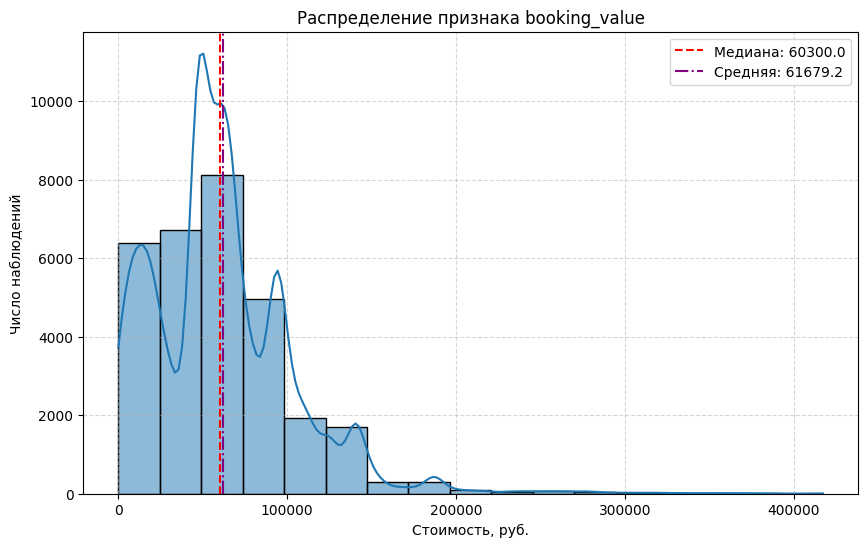

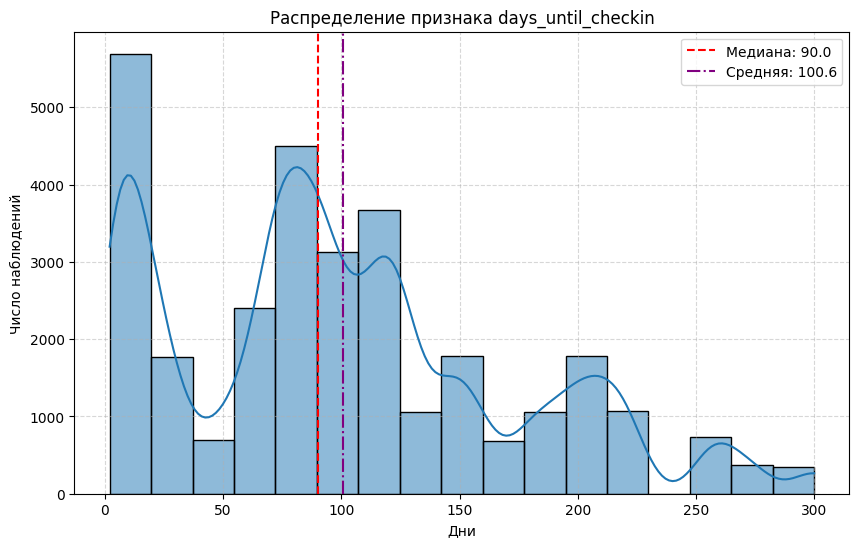

In [25]:
x_labels = {'booking_value': 'Стоимость, руб.', 'days_until_checkin': 'Дни'}

for col in numerical_features_hb:
    histogram_chart(df=df_hotel_bookings, attr=col, bins=17, title_text=f'Распределение признака {col}', xlabel=x_labels[col])

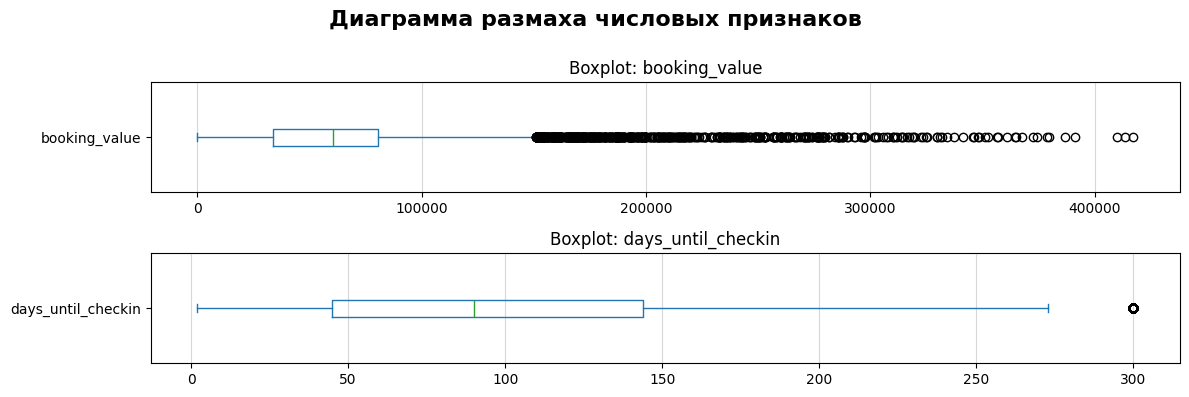

In [26]:
boxplot_chart(df=df_hotel_bookings, feature_list=numerical_features_hb, diagram_name='Диаграмма размаха числовых признаков')

#### Анализ числовых признаков: booking_value и days_until_checkin

**booking_value (стоимость бронирования)**  
Распределение признака сильно смещено вправо: медиана (60 300 руб.) практически совпадает со средним (61 679 руб.), однако длинный правый хвост и экстремальные значения (максимум — 417 221 руб.) указывают на выраженную асимметрию. На boxplot заметно множество выбросов в правой части — это могут быть премиальные бронирования либо аномальные транзакции. Такое поведение признака способно искажать работу моделей, чувствительных к масштабу (линейные модели, kNN), а также влиять на интерпретацию SHAP‑значений. Для снижения влияния хвоста можно применить логарифмическое преобразование — оно уменьшит разброс и приблизит распределение к нормальному.

**days_until_checkin (дни до заезда)**  
Распределение также имеет правостороннюю асимметрию, но менее выраженную: медиана (90 дней) и среднее (100,6 дней) близки, максимум ограничен 300 днями. На графике присутствует один изолированный выброс в районе 300 дней — вероятно, сверхраннее бронирование. В целом признак менее подвержен искажениям по сравнению с `booking_value`, но его длинный хвост всё же может влиять на масштабирование. Логарифмирование здесь необязательно, но допустимо.

**Выводы и рекомендации**  
- `booking_value`: обязательно логарифмировать перед подачей в модели, которые чувствительны к масштабу; при использовании ансамблевых моделей (CatBoost, LightGBM) преобразование не обязательно.  
- `days_until_checkin`: преобразование опционально; достаточно контролировать влияние выброса на масштабирование.   
- Наличие выбросов важно учитывать при выборе метрик качества и валидации: в отдельных сегментах (например, премиальные бронирования) поведение модели может существенно отличаться.

---


#### 1.2.3 Порядковые признаки

In [27]:
df_hotel_bookings[ordinal_features_hb].describe()

,adult_count,child_count,previous_cancellations,previous_no_shows,weekday_nights,weekend_nights,customer_special_requests
count,30733.000000,30733.000000,30733.000000,30733.00000,30733.000000,30733.000000,30733.000000
mean,14.082387,0.356685,0.357303,0.83900,6.536687,1.954772,0.620603
std,48.832586,0.584576,0.629688,0.93191,3.336198,1.476409,0.784428
min,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.00000,5.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,1.00000,6.000000,2.000000,0.000000
75%,3.000000,1.000000,1.000000,1.00000,9.000000,2.000000,1.000000
max,300.000000,2.000000,5.000000,5.00000,15.000000,6.000000,5.000000


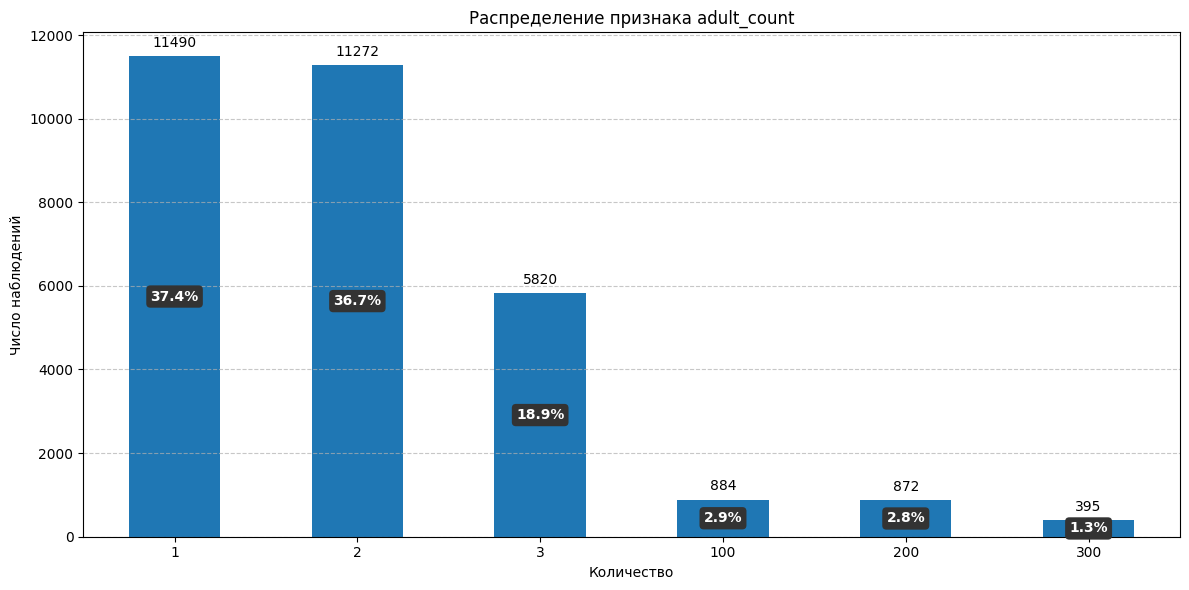

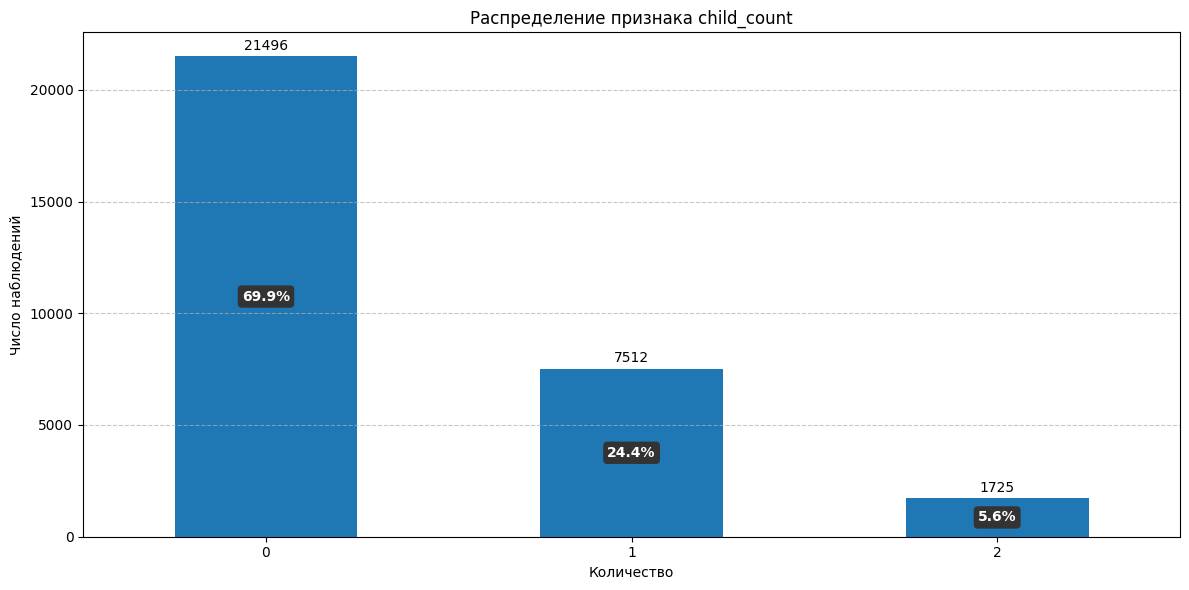

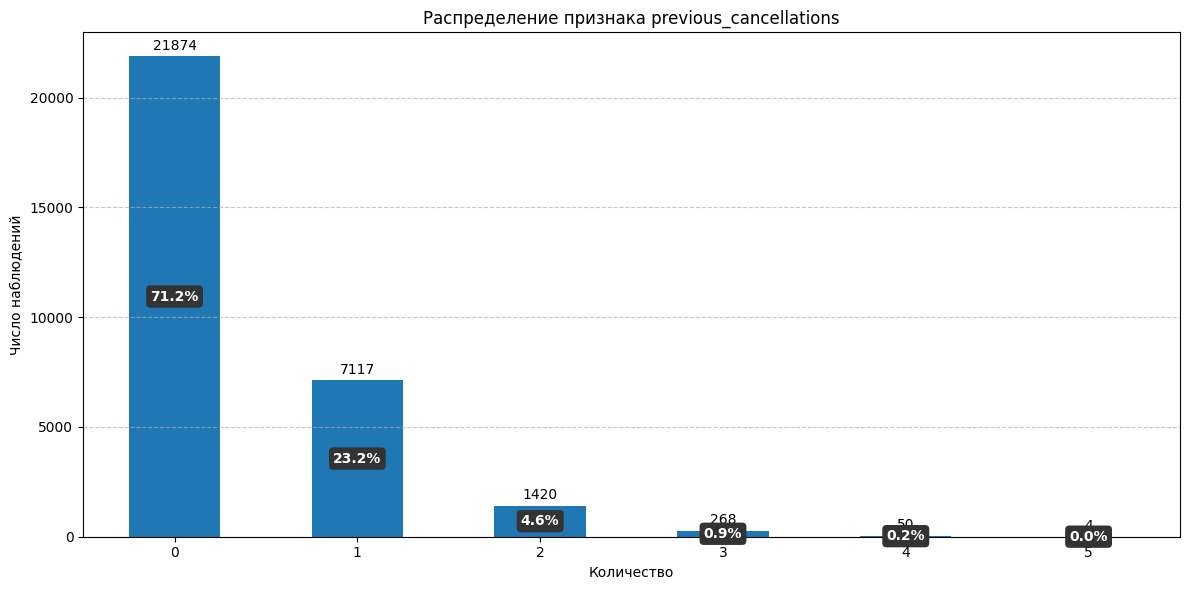

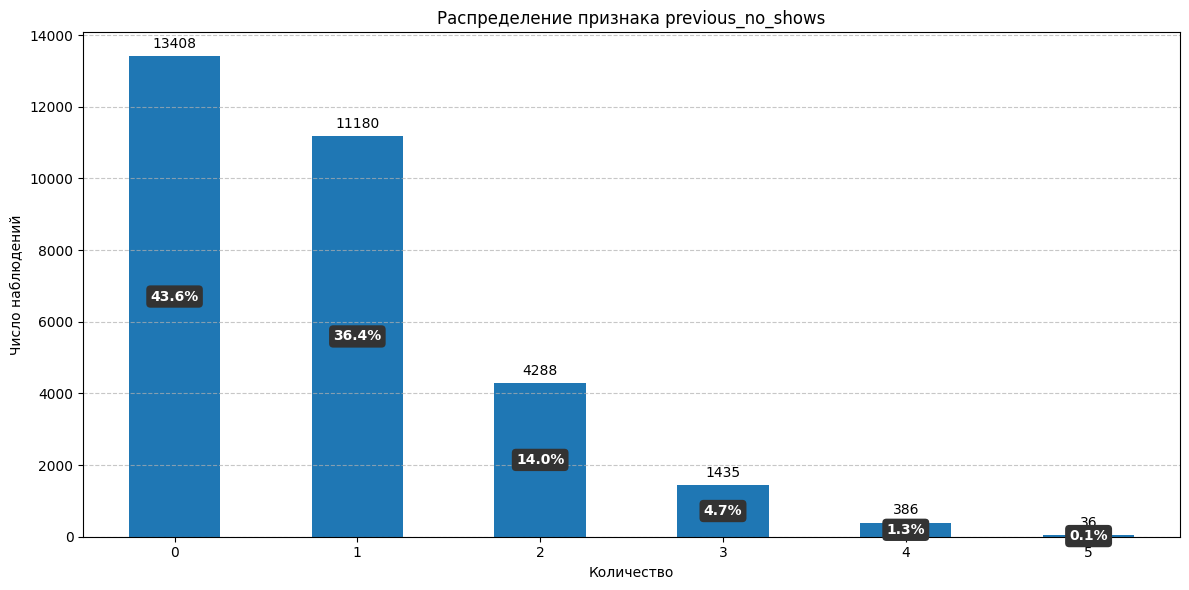

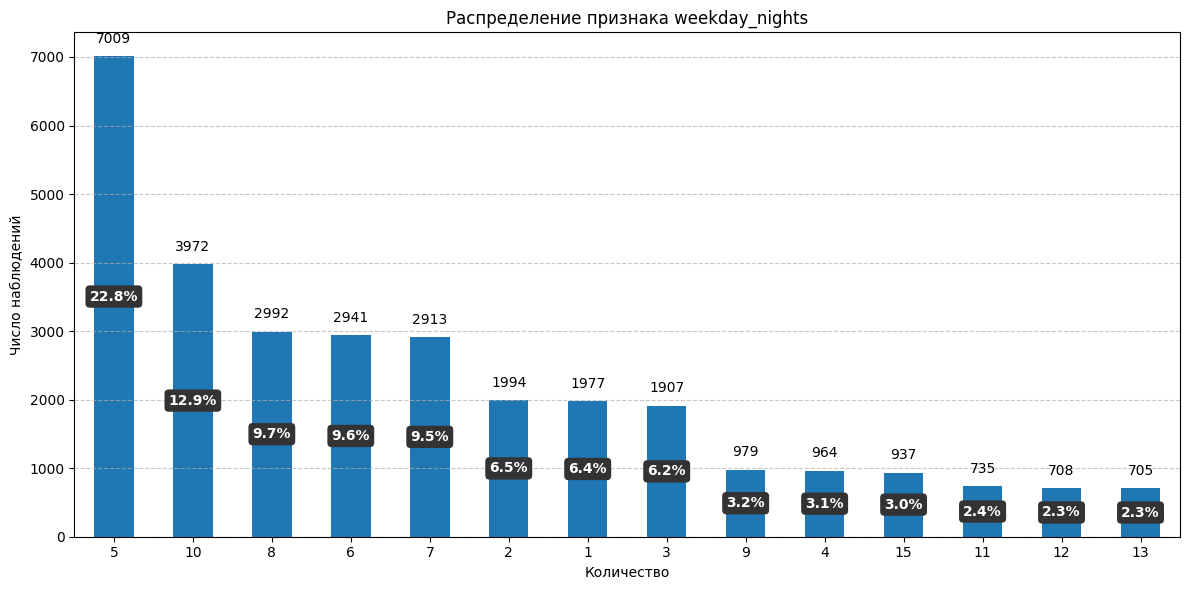

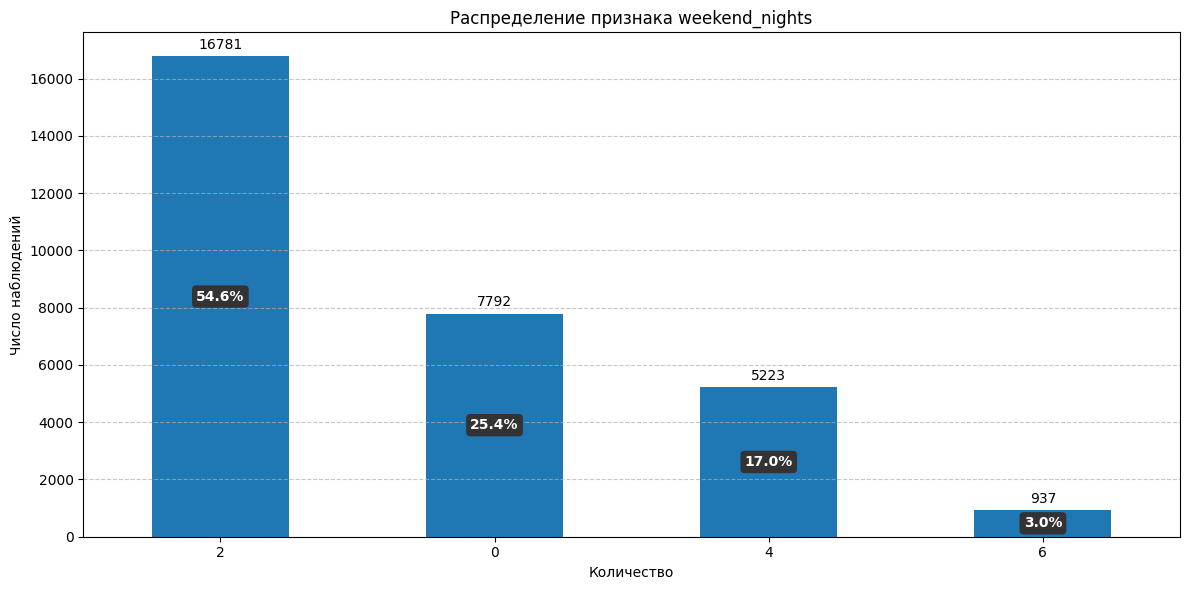

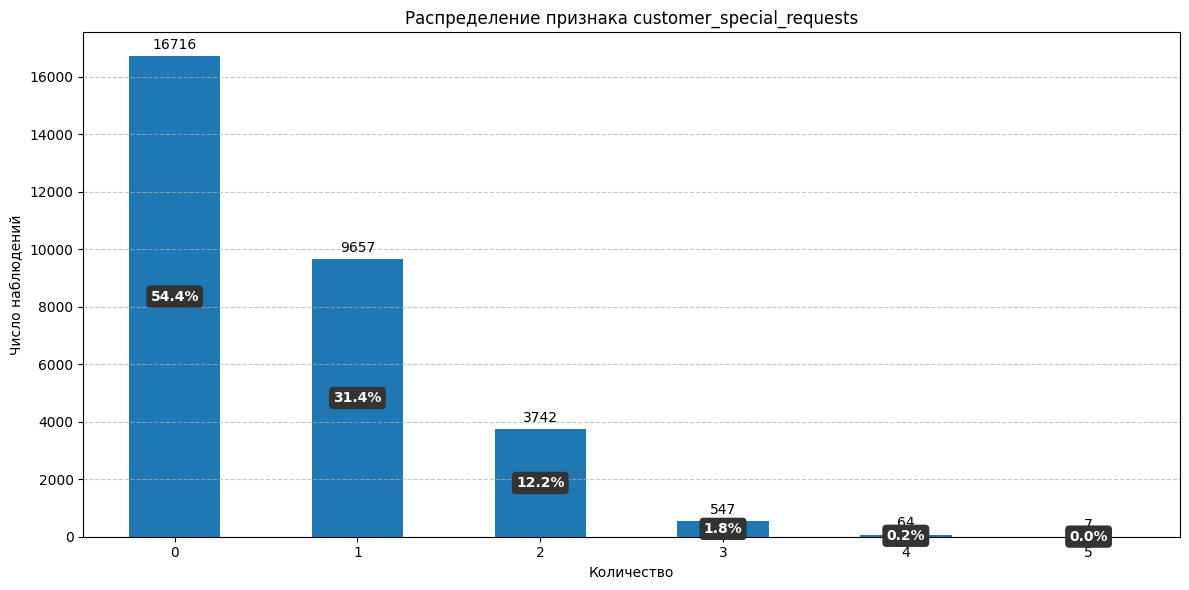

In [28]:
for col in ordinal_features_hb:
    plot_bar_chart(df_hotel_bookings[col], xlabel='Количество', title=f'Распределение признака {col}', top_n=15)

In [29]:
df_hotel_reviews['stay_rating'].describe()

count    25047.000000
mean         3.394339
std          0.541355
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: stay_rating, dtype: float64

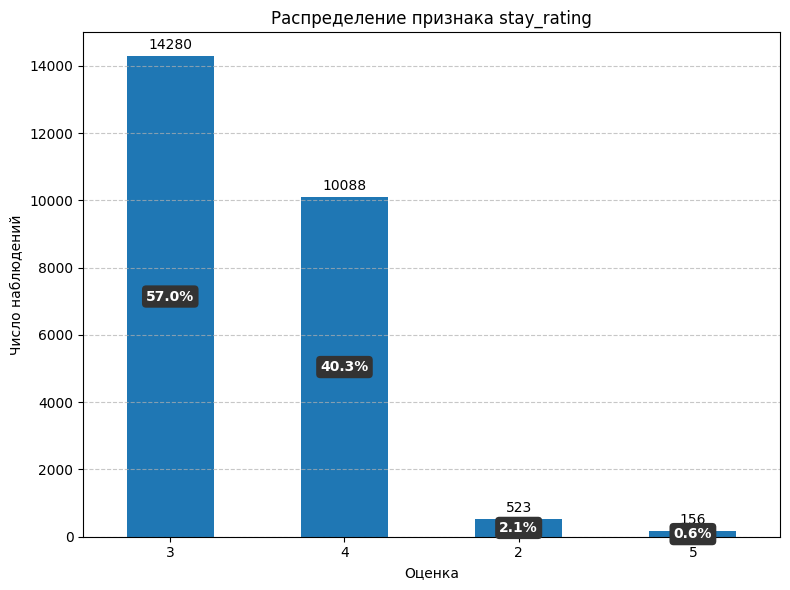

In [30]:
plot_bar_chart(data=df_hotel_reviews['stay_rating'], xlabel='Оценка', title='Распределение признака stay_rating', figsize=(8,6))

In [31]:
df_hotel_bookings.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,0,0,0,0,6700.0,21,1,0,тип_питания_2,0,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,1,0,1,0,62300.0,15,5,2,тип_питания_2,0,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,1,0,2,0,46900.0,96,5,2,тип_питания_1,0,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,0,0,0,0,53600.0,150,6,2,тип_питания_1,0,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,1,1,1,0,46900.0,96,5,2,тип_питания_1,0,тип_1,1


#### Анализ порядковых признаков

**adult_count (количество взрослых)**  
В данных присутствуют аномальные значения 100, 200 и 300 — это, скорее всего ошибки ввода, которые будут исправлены: 100 → 1, 200 → 2, 300 → 3. В номер физически не может заселиться такое большое число посетителей. Вместе значения 1 и 100, 2 и 200, 3 и 300 дают следующий результат.

| Значение | Количество | Доля |
|----------|-----------|------|
| 1 | 12 374 | 40,3 % |
| 2 | 12 144 | 39,5 % |
| 3 | 6 215 | 20,2 % |


**child_count (количество детей)**  
В 70 % случаев детей нет, в 24 % — один ребёнок, в 6 % — двое. Среднее (0,36), медиана (0).

**previous_cancellations (предыдущие отмены)**  
71 % клиентов не имели отмен, 23 % — одну, 6 % — две и более. Среднее (0,36), медиана (0). Значения 3–5 встречаются крайне редко (менее 1 %).

**previous_no_shows (предыдущие неявки)**  
44 % — без неявок, 36 % — одна, 14 % — две, 6 % — три и более. Среднее (0,84), медиана (1). Признак информативен для прогноза отмен.

**weekday_nights (ночи в будни)**  
Топ 5 значений 5, 10, 8, 6 и 7 ночей. Среднее (6,54), медиана (6) — близки. Диапазон 1–15, без выраженных выбросов.

**weekend_nights (ночи в выходные)**  
Распределение: 2 ночи (55 %), 0 ночей (25 %), 4 ночи (17 %). Среднее (1,95), медиана (2) — близки. Максимум — 6 ночей.

**customer_special_requests (специальные запросы)**  
54 % — без запросов, 31 % — один, 12 % — два, 3 % — три и более. Среднее (0,62), медиана (0). Значения 4–5 крайне редки (менее 0,3 %).

**stay_rating (оценка проживания из отзывов)**  
Шкала 2–5 баллов. 57 % — оценка 3, 40 % — оценка 4, 2 % — оценка 2, 0,6 % — оценка 5. Среднее (3,39), медиана (3). Низкая вариативность (std = 0,54).

**Выводы и рекомендации**  
- `adult_count`: значения 100, 200 и 300 — это ошибки, которые требуют корректировки до реалистичных (1–3).  
- Остальные признаки можно подавать в модели в исходном виде.

---


#### 1.2.4 Категориальные и бинарные признаки

In [32]:
df_hotel_bookings[categorical_features_hb].describe()

,sales_channel,meal_plan,room_type
count,30733,30733,30733
unique,3,5,7
top,офлайн_бронирование,тип_питания_1,тип_1
freq,10447,23604,23687


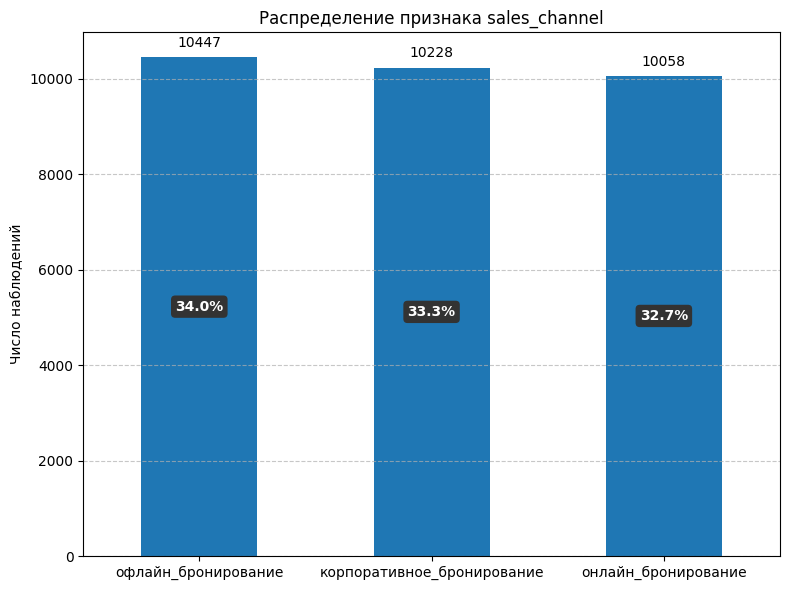

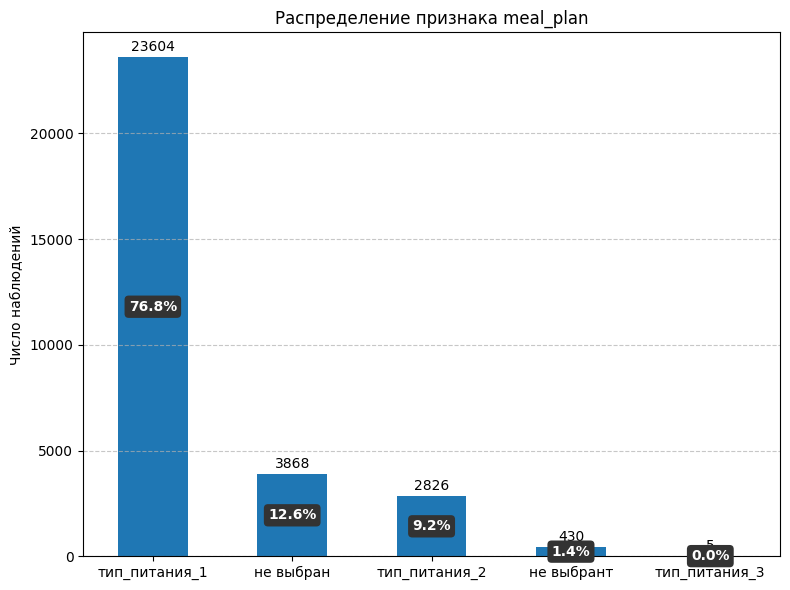

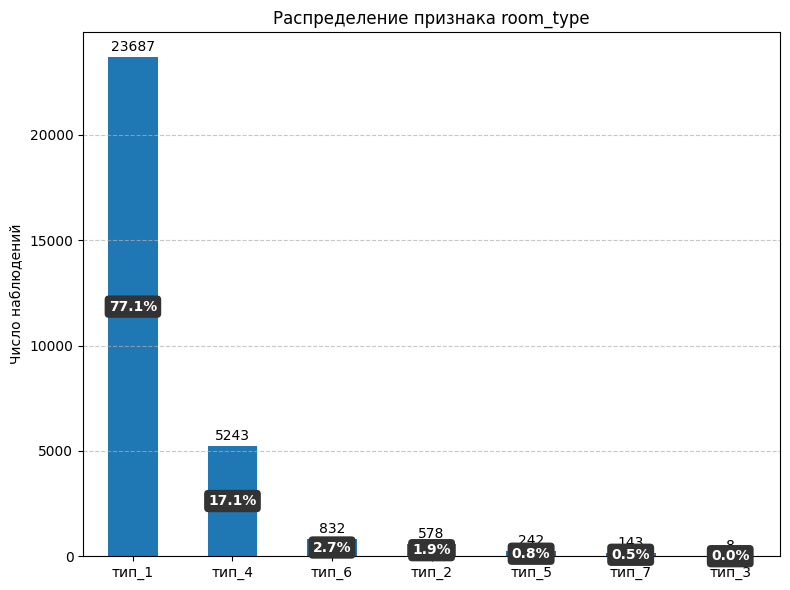

In [33]:
for col in categorical_features_hb:
    plot_bar_chart(df_hotel_bookings[col], xlabel='', title=f'Распределение признака {col}', top_n=10, figsize=(8,6))

In [34]:
df_hotel_bookings[binary_features_hb].describe()

,returning_customer,parking_included
count,30733.000000,30733.000000
mean,0.563726,0.032701
std,0.495930,0.177856
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,0.000000
max,1.000000,1.000000


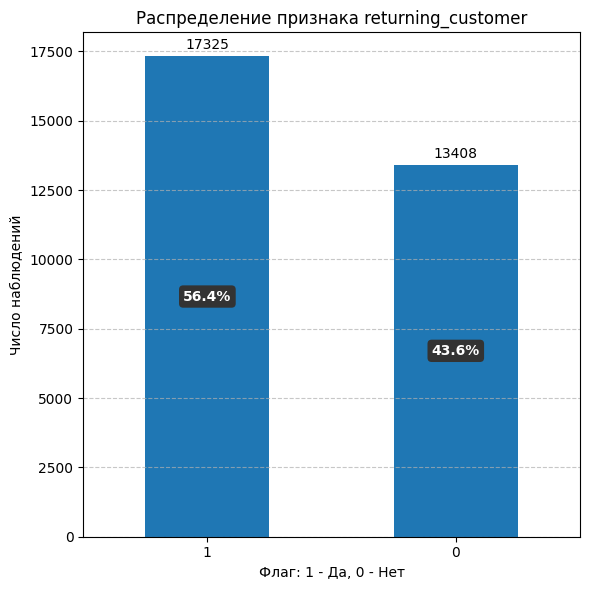

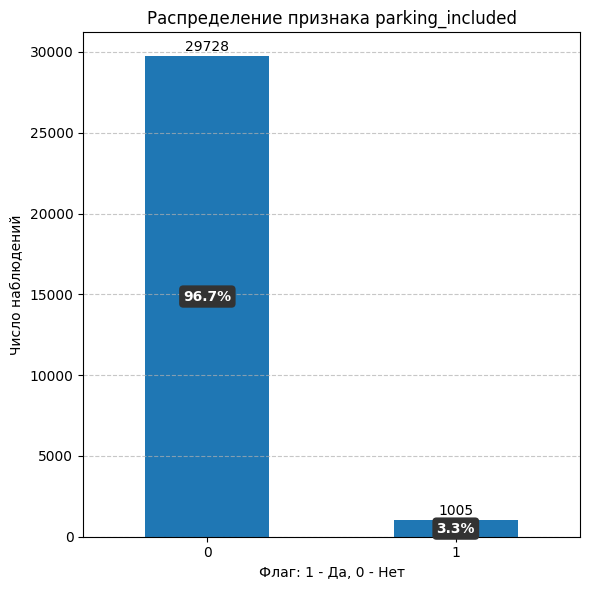

In [35]:
for col in binary_features_hb:
    plot_bar_chart(df_hotel_bookings[col], xlabel='Флаг: 1 - Да, 0 - Нет', title=f'Распределение признака {col}', top_n=10, figsize=(6,6))

#### Анализ категориальных и бинарных признаков

**sales_channel (канал продаж)**  
Три категории, распределены почти равномерно: офлайн — 34,0 % (10 447), корпоративное — 33,3 % (10 228), онлайн — 32,7 % (10 058). Дисбаланса нет, признак информативен.

**meal_plan (тип питания)**  
Доминирует `тип_питания_1` — 76,8 % (23 604). Далее: `не выбран` — 12,6 % (3 868), `тип_питания_2` — 9,2 % (2 826), `тип_питания_3` — 0,02 % (5). Обнаружена опечатка `не выбрант` — 1,4 % (430), требует исправления на `не выбран`. После исправления `тип_питания_3` останется крайне редкой категорией (5 строк) — кандидат на объединение или удаление.

**room_type (тип номера)**  
`тип_1` доминирует — 77,1 % (23 687), `тип_4` — 17,1 % (5 243). Остальные типы суммарно менее 6 %: `тип_6` — 2,7 %, `тип_2` — 1,9 %, `тип_5` — 0,8 %, `тип_7` — 0,5 %, `тип_3` — 0,03 % (8 строк). Редкие категории (`тип_3`, `тип_5`, `тип_7`) стоит объединить в «прочие».

**returning_customer (постоянный клиент)**  
1 — 56,4 % (17 325), 0 — 43,6 % (13 408). Распределение сбалансированное, признак информативен.

**parking_included (включена парковка)**  
0 — 96,7 % (29 728), 1 — 3,3 % (1 005). Сильный дисбаланс, но для бинарного признака допустим. Парковка — редкая опция, может быть информативна как сигнал премиального бронирования.

**Выводы и рекомендации**  
- `meal_plan`: исправить опечатку `не выбрант` → `не выбран`; категорию `тип_питания_3` (5 строк) объединить с `тип_питания_2`.  
- `room_type`: редкие типы (`тип_3`, `тип_5`, `тип_7`) объединить в «прочие».  
- `sales_channel` и `returning_customer` — без замечаний, использовать как есть.  
- `parking_included` — сильный дисбаланс, но оставляем; модель сама определит значимость.

---


#### 1.2.5 Облако слов отзывов `review_text`

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\artem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


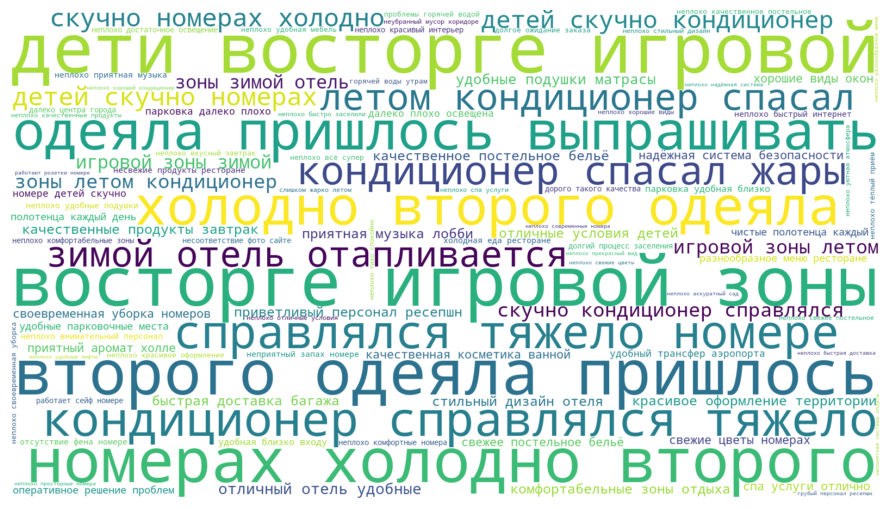

восторге игровой зоны: 4029
дети восторге игровой: 4029
второго одеяла пришлось: 3682
номерах холодно второго: 3682
одеяла пришлось выпрашивать: 3682
холодно второго одеяла: 3682
кондиционер справлялся тяжело: 3674
справлялся тяжело номере: 3674
кондиционер спасал жары: 2664
летом кондиционер спасал: 2664
зимой отель отапливается: 2524
детей скучно номерах: 1054
скучно номерах холодно: 1054
детей скучно кондиционер: 1031
скучно кондиционер справлялся: 1031


In [36]:
# Построим облако слов по отзывам из df_booking_reviews
# Обработка текста минимальная

nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Оставляем только буквы и пробелы, приводим к нижнему регистру
    text = re.sub(r'[^а-яА-ЯёЁ\s]', ' ', text.lower())
    tokens = text.split()
    # Убираем стоп‑слова и очень короткие токены
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

# Очищаем тексты отзывов
df_hotel_reviews['review_text_clean'] = df_hotel_reviews['review_text'].apply(clean_text)

# Считаем частоты слов (без лемматизации и стемминга)
vectorizer = CountVectorizer(
    ngram_range=(3, 3),      # настройка n-gram
    min_df=5,                # минимум 5 отзывов с этим словом
    max_features=2000        # не больше 2000 слов
)
X = vectorizer.fit_transform(df_hotel_reviews['review_text_clean'])

# Получаем частоты
feature_names = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
word_freq = Counter({feature_names[i]: counts[i] for i in range(len(feature_names))})

# Строим облако слов
wc = WordCloud(
    width=1600,
    height=900,
    background_color='white',
    max_words=100,
    colormap='viridis',
    random_state=RANDOM_SEED
)
wc.generate_from_frequencies(word_freq)

plt.figure(figsize=(9, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

for word, freq in word_freq.most_common(15):
    print(f"{word}: {freq}")

#### Вывод по облаку слов

По результатам построения облака слов с минимальной предобработкой (удалены стоп‑слова, лемматизация и стемминг не применялись) выявлены ключевые болевые точки и сильные стороны отеля, которые регулярно упоминаются в отзывах.

**Основные проблемы:**
- **Температурный дискомфорт в номерах.** В топе фраз устойчиво встречаются комбинации про холод и нехватку одеял («в номерах холодно», «второго одеяла пришлось выпрашивать»). Это указывает на системную проблему, которая заметно влияет на удовлетворённость гостей.
- **Недостаточная эффективность кондиционирования.** Фразы вроде «кондиционер справлялся тяжело» и «летом кондиционер спасал» говорят о том, что климатическое оборудование работает на пределе или не справляется с нагрузкой в жаркий сезон.
- **Скука для детей в номерах.** Упоминания «детям скучно в номерах» фиксируют отдельный сегмент недовольства, который может быть критичен для семейных гостей.

**Позитивные моменты:**
- **Игровая зона — сильный драйвер удовлетворённости.** Высокая частота фраз про восторг детей от игровой зоны демонстрирует наличие у отеля явного конкурентного преимущества для семей. Этот фактор стоит активнее использовать в коммуникации и при сегментации клиентов.

**Практические выводы для ML‑проекта UrbanStay:**
- Выявленные темы можно использовать как семантические признаки или теги для обогащения обучающей выборки: например, добавить бинарные/счётные признаки «есть жалоба на температуру», «есть жалоба на кондиционер», «упоминается игровая зона».
- Фразы с высокой частотой (особенно про одеяла и кондиционеры) могут служить сигналами для приоритизации доработок сервиса — это напрямую связано с вероятностью отмены брони: дискомфорт в номере повышает риск отказа.
- При дальнейшей работе с текстом имеет смысл выделить эти паттерны в отдельные кластеры или правила маршрутизации обращений: жалобы на температуру и кондиционирование логично направлять в операционные службы, а отзывы про игровую зону — в маркетинг и продукт.

---

#### 1.2.6 Анализ целевой переменной

In [37]:
df_hotel_bookings[target].describe()

count    30733.000000
mean         0.287964
std          0.452822
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: booking_status, dtype: float64

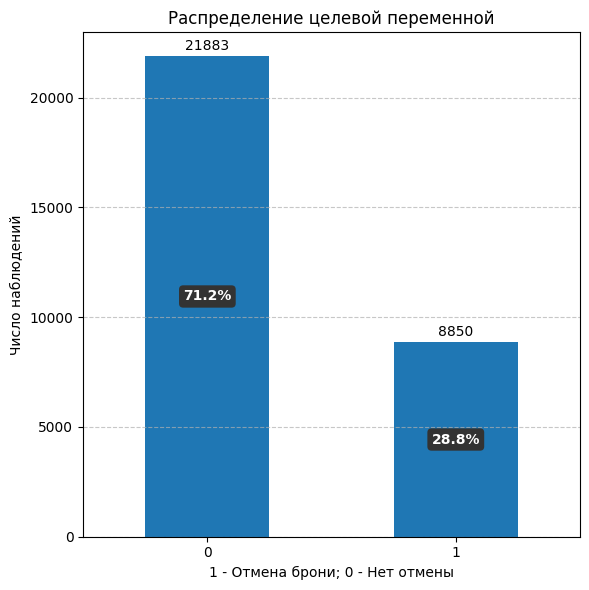

In [38]:
plot_bar_chart(data=df_hotel_bookings[target], xlabel='1 - Отмена брони; 0 - Нет отмены', title='Распределение целевой переменной', figsize=(6,6))

#### Анализ целевой переменной (booking_status)

**Распределение по категориям**  
- 0 (нет отмены): 21 883 наблюдения (71,2 %)  
- 1 (отмена брони): 8 850 наблюдений (28,8 %)  

**Выводы и рекомендации**  
- Дисбаланс классов умеренный (соотношение ~2,5:1), не критичен для большинства ML‑алгоритмов.  
- Допустимо использовать стандартные метрики (Accuracy, F1, Recall, Precision) и техники балансировки (class_weight, SMOTE) при необходимости.  
- Целевая переменная пригодна для моделирования без предварительной трансформации.

---


#### 1.2.6 Исправления по итогам анализа признаков

In [39]:
# 1) adult_count — замена аномальных значений
replace_map = {100: 1, 200: 2, 300: 3}
df_hotel_bookings['adult_count'] = df_hotel_bookings['adult_count'].replace(replace_map)

# 2) meal_plan — исправление опечатки и объединение категорий
df_hotel_bookings['meal_plan'] = df_hotel_bookings['meal_plan'].replace({
    'не выбрант': 'не выбран',
    'тип_питания_3': 'тип_питания_2',
})

# 3) room_type — объединение редких типов в «прочие»
rare_types = ['тип_3', 'тип_5', 'тип_7']
df_hotel_bookings['room_type'] = df_hotel_bookings['room_type'].replace(rare_types, 'прочие')


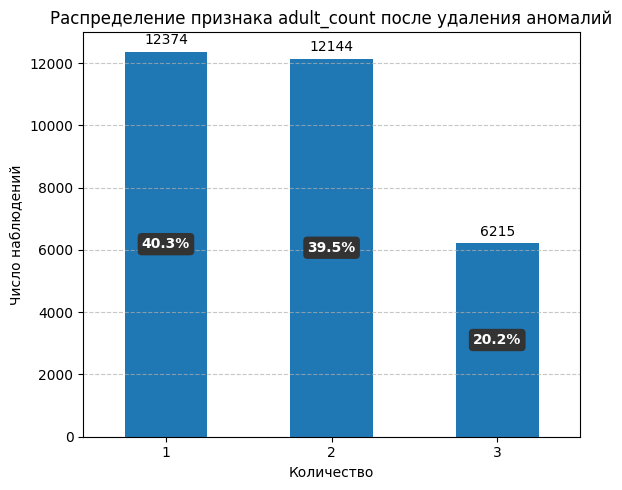

In [40]:
plot_bar_chart(df_hotel_bookings['adult_count'], xlabel='Количество', title=f'Распределение признака adult_count после удаления аномалий', figsize=(6,5))

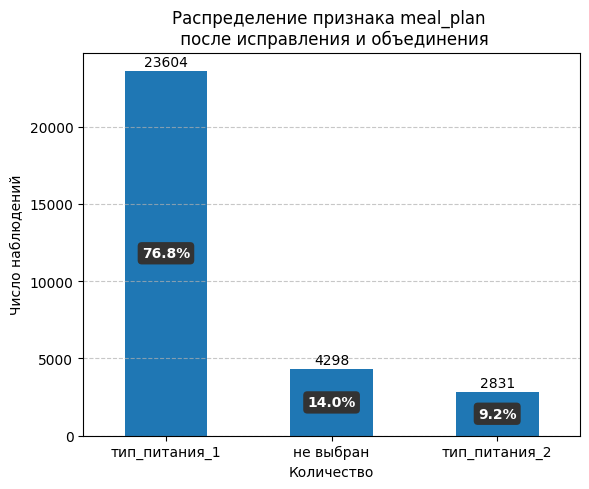

In [41]:
plot_bar_chart(df_hotel_bookings['meal_plan'], xlabel='Количество', title=f'Распределение признака meal_plan \n после исправления и объединения', figsize=(6,5))

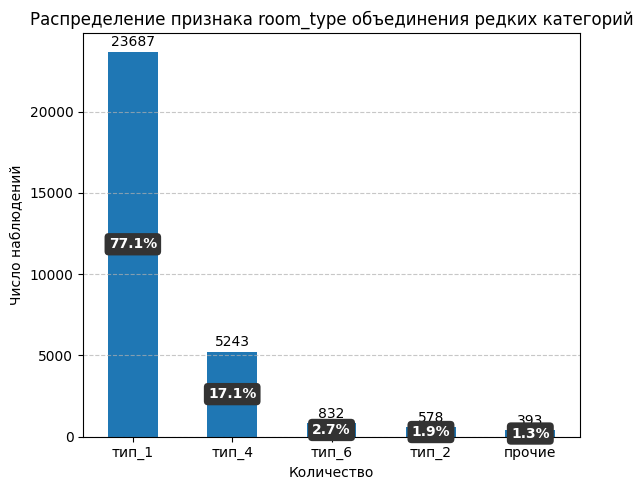

In [42]:
plot_bar_chart(df_hotel_bookings['room_type'], xlabel='Количество', title=f'Распределение признака room_type объединения редких категорий', figsize=(6,5))

#### Комментарий: выполнены корректировки данных в df_hotel_bookings

- Исправлены аномальные значения в `adult_count`: 100 → 1, 200 → 2, 300 → 3 — это устраняет искажения в подсчёте числа гостей.  
- В `meal_plan` устранена опечатка (`не выбрант` → `не выбран`) и объединены редкие категории (`тип_питания_3` → `тип_питания_2`), что снижает шум и улучшает баланс классов.  
- Редкие типы номеров (`тип_3`, `тип_5`, `тип_7`) в `room_type` объединены в категорию «прочие» — это упрощает последующую кодировку признаков и снижает разреженность.  

Данные приведены к консистентному виду, этап очистки завершён.

---


### 1.3 Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

In [43]:
rows_before = df_hotel_bookings.shape[0]

# Шаг 1: подтягиваем customer_id в брони (его там нет)
booking_customer_link = df_hotel_reviews[['booking_id', 'customer_id']].drop_duplicates('booking_id')
df_hotel_bookings = df_hotel_bookings.merge(booking_customer_link, on='booking_id', how='left')

# Шаг 2: сортируем обе таблицы по дате (merge_asof этого требует)
df_hotel_bookings = df_hotel_bookings.sort_values('booking_date')
df_hotel_reviews = df_hotel_reviews.sort_values('review_date')

# Шаг 3: merge_asof — одна операция
df_hotel = pd.merge_asof(
    df_hotel_bookings,
    df_hotel_reviews[['customer_id', 'review_date', 'stay_rating', 'review_text', 'review_text_clean']],
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward'
)

In [44]:
print(f"Строк до объединения: {rows_before}")
print(f"Строк после объединения: {df_hotel.shape[0]}")
print(f"Броней без отзыва: {df_hotel['stay_rating'].isna().sum()}")


Строк до объединения: 30733
Строк после объединения: 30733
Броней без отзыва: 22402


In [45]:
df_hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 30733 entries, 0 to 30732
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_id                 30733 non-null  str          
 1   booking_date               30733 non-null  datetime64[s]
 2   sales_channel              30733 non-null  str          
 3   adult_count                30733 non-null  int16        
 4   child_count                30733 non-null  int8         
 5   returning_customer         30733 non-null  int8         
 6   previous_cancellations     30733 non-null  int8         
 7   previous_no_shows          30733 non-null  int8         
 8   booking_status             30733 non-null  int8         
 9   booking_value              30733 non-null  float64      
 10  days_until_checkin         30733 non-null  int16        
 11  weekday_nights             30733 non-null  int8         
 12  weekend_nights             30

In [46]:
df_hotel[df_hotel['customer_id'] == 'C0001'].sort_values(by='booking_date', ascending=False)

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text,review_text_clean
30241,INN00002,2022-11-19,корпоративное_бронирование,3,0,1,0,2,0,46900.0,96,5,2,тип_питания_1,0,тип_1,0,C0001,2021-10-15,3.0,"Неплохо. красивое оформление территории, но неработающий лифт.",неплохо красивое оформление территории неработающий лифт
28664,INN00001,2021-09-19,корпоративное_бронирование,3,0,1,0,1,0,62300.0,15,5,2,тип_питания_2,0,тип_1,1,C0001,2020-08-21,3.0,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере",неплохо тихо спокойно отсутствие фена номере кондиционер справлялся тяжело номере
23113,INN00000,2020-07-08,корпоративное_бронирование,3,0,0,0,0,0,6700.0,21,1,0,тип_питания_2,0,тип_1,0,C0001,NaT,NaN,NaN,NaN


#### Комментарий к объединению таблиц

Выполнено объединение `df_hotel_bookings` и `df_hotel_reviews` в единый датафрейм `df_hotel`:

- **Подтянут `customer_id` в брони** через левое соединение по `booking_id`: это позволило однозначно сопоставить отзывы с клиентами и далее использовать `customer_id` как ключ для временного соединения.
- **Применено `merge_asof` с направлением `backward`** по датам (`booking_date` → `review_date`) в разрезе `customer_id`: так мы привязываем к брони ближайший предшествующий отзыв (логично для прогноза отмены — учитываем уже имеющийся опыт клиента).
- **Число строк сохранилось (30 733)**: потерь по первичному ключу (броням) нет, целостность основного датасета не нарушена.
- **22 402 брони без отзыва**: ожидаемый результат — не все гости оставляют отзывы, и часть признаков (`stay_rating`, `review_text` и др.) будет разреженной. Это важно учесть при проектировании фичей и выборе стратегии обработки пропусков (например, отдельный флаг «отзыв отсутствует» может быть информативным).

Итог: получен единый датасет с сохранением всех броней и временной привязкой отзывов; следующий шаг — работа с пропусками и конструирование признаков на основе отзывов и истории клиента.

---


### 1.4 Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

In [47]:
# Сортировка 
df_hotel = df_hotel.sort_values(['customer_id', 'booking_date'])

# Добавим три новых признака

# 1. Кумулятивный счётчик предыдущих броней
df_hotel['previous_bookings_count'] = df_hotel.groupby('customer_id').cumcount()
df_hotel['previous_bookings_count'] = df_hotel['previous_bookings_count'].fillna(0)

# 2. Сезонность через циклическое кодирование
# Дата планируемого заезда
df_hotel['checkin_date'] = df_hotel['booking_date'] + pd.to_timedelta(df_hotel['days_until_checkin'], unit='D')
df_hotel['checkin_month_cos'] = np.cos(2 * np.pi * df_hotel['checkin_date'].dt.month / 12)

# 3. Лояльность клиента: каждая прошлая бронь +1, каждый успешный заезд +2, каждая отмена −2. Итог не уходит ниже нуля.
df_hotel['loyalty_score'] = (
    df_hotel['previous_bookings_count']
    + 2 * df_hotel['previous_no_shows']
    - 2 * df_hotel['previous_cancellations']
).clip(lower=0).astype(int)

In [48]:
# Добавим бинарные признаки-флаги на базе топ-14 фраз облака слов

top15_phrases_wordcloud = [
    'восторге игровой зоны',
    'дети восторге игровой',
    'второго одеяла пришлось',
    'номерах холодно второго',
    'одеяла пришлось выпрашивать',
    'холодно второго одеяла',
    'кондиционер справлялся тяжело',
    'справлялся тяжело номере',
    'кондиционер спасал жары',
    'летом кондиционер спасал',
    'зимой отель отапливается',
    'детей скучно номерах',
    'скучно номерах холодно',
    'детей скучно кондиционер',
    'скучно кондиционер справлялся',
]

col_names = [
    'flag_kids_play_area',
    'flag_kids_play_area_2',
    'flag_extra_blanket',
    'flag_cold_blanket',
    'flag_blanket_beg',
    'flag_cold_blanket_2',
    'flag_ac_hard',
    'flag_ac_hard_2',
    'flag_ac_heat',
    'flag_ac_heat_2',
    'flag_winter_heat',
    'flag_kids_bored',
    'flag_bored_cold',
    'flag_kids_bored_ac',
    'flag_bored_ac',
]

review_text = df_hotel['review_text_clean'].fillna('')

for phrase, col in zip(top15_phrases_wordcloud, col_names):
    # Флаг: 1 если фраза есть в тексте, иначе 0
    df_hotel[col] = review_text.str.contains(phrase, case=False, na=False).astype(int)

In [49]:
# Еще один агрегированный признак - флаг наличия отзыва
df_hotel['has_review'] = df_hotel['review_text'].notna().astype(int)

# Заполним пропуски stay_rating
df_hotel['stay_rating'] = df_hotel['stay_rating'].fillna(-1)


# Удаляем неинформативные и идентификационные колонки
cols_to_drop = [
    'booking_id',
    'customer_id',
    'checkin_date',
    'review_date',
    'review_text',
    'review_text_clean',
    'booking_date'
]

df_hotel = df_hotel.drop(columns=cols_to_drop, errors='ignore')

In [50]:
# Оптимизируем типы данных в датафрейме
df_hotel = optimize_dataframe(df_hotel)

### Комментарий к этапу конструирования признаков 

На этом шаге расширен признаковый набор и выполнена финальная подготовка данных для обучения моделей на деревьях (RandomForest, CatBoost, LightGBM, XGBoost).

**Поведенческие и кумулятивные признаки**

- `previous_bookings_count` — кумулятивный счётчик предыдущих броней клиента в разрезе `customer_id`. Реализован через `cumcount()` после сортировки по `booking_date`, что гарантирует отсутствие утечки будущих данных: в счётчик попадают только бронирования, предшествующие текущему.
- **`loyalty_score`** — интегральный индикатор лояльности: +1 за каждую прошлую бронь, +2 за каждый подтверждённый заезд (`previous_no_shows`), −2 за каждую отмену, с ограничением снизу нулём. Успешный заезд весит вдвое больше факта бронирования: бронь может быть отменена, а заезд — это уже подтверждённое действие клиента. Отмена и заезд симметричны по модулю (−2 / +2), что делает интерпретацию прозрачной. Признак позволяет модели дифференцировать сегменты клиентов с разным уровнем надёжности и риском отмены.

**Временные и сезонные признаки**

- `checkin_date` — вычисляемая дата заезда как `booking_date + days_until_checkin`. Промежуточная переменная, необходимая для построения сезонности.
- `checkin_month_cos` — циклическое кодирование месяца заезда через косинус-преобразование. Такой подход сохраняет непрерывность шкалы (декабрь «близок» к январю) и устраняет ложные порядковые отношения между месяцами, что критично для корректной работы деревьев.


**Текстовые флаги на базе облака слов**

- Создано **15 бинарных флагов** (`flag_*`) по топ‑фразам из облака слов отзывов. Каждая фраза отражает типичную проблему или позитивный момент (холод в номере, проблемы с кондиционером, восторг от игровой зоны и т. п.).
- Флаги формируются через `str.contains()` по очищенному тексту (`review_text_clean`). Пропуски в отзывах корректно обрабатываются: для строк без отзыва все флаги равны 0 — это естественный и интерпретируемый способ кодирования отсутствия информации.
- По сути, подход реализует упрощённую версию Bag‑of‑Words в бинарной форме: вместо подсчёта частот фиксируются факты наличия заранее отобранных n‑грамм (устойчивых фраз), что снижает размерность и исключает риск утечки данных за счёт фиксированного словаря.
- Ручная подборка фраз по облаку слов обеспечивает высокую интерпретируемость признаков для бизнеса.
- При этом метод сохраняет ключевые преимущества BoW — учёт смысловых фрагментов текста без учёта порядка слов — и остаётся совместимым с общей стратегией «прозрачных» инженерных признаков (лояльность, сезонность, явные флаги).


**Работа с пропусками и флаг наличия отзыва**

- `has_review` — бинарный флаг (1 — есть отзыв, 0 — нет). Это ключевой признак: сам факт отсутствия отзыва — сильный сигнал для прогноза отмены.
- `stay_rating` — пропуски заполнены значением `-1`. Это техническое решение, необходимое для совместимости с RandomForest (sklearn), который не поддерживает NaN. Для бустинговых моделей (CatBoost, LightGBM, XGBoost) такое заполнение допустимо: деревья выучат сплит вида `stay_rating < 0.5` и отделят «без отзыва» от реальных оценок 1–5. При этом флаг `has_review` даёт модели явный сигнал об отсутствии отзыва и не позволяет смешивать категории.


**Удаление неинформативных и идентификационных колонок**

Удалены:
- **Идентификаторы**: `booking_id`, `customer_id` — не должны попадать в обучение, чтобы избежать переобучения и утечки информации.
- **Даты и текстовые поля**: `booking_date`, `checkin_date`, `review_date`, `review_text`, `review_text_clean` — либо уже использованы для построения признаков, либо избыточны.

**Оптимизация типов данных**

Выполнена оптимизация типов через `optimize_dataframe(df_hotel)`:
- Уменьшен объём памяти (с ~3.0 MB до ~2.6 MB).
- Приведены типы к более компактным (например, `int8` для бинарных флагов, `float32` вместо `float64`).
- Это ускоряет вычисления, снижает потребление памяти и полезно при кросс‑валидации и подборе гиперпараметров (в том числе с Optuna).

### Проверка на отсутствие утечки данных (data leakage)

Все признаки построены только на информации, доступной на момент создания брони:
- Кумулятивные счётчики рассчитаны строго по истории до текущей строки (сортировка + `cumcount`).
- Сезонность выводится из `booking_date` и `days_until_checkin` — оба поля известны при создании брони.
- Текстовые флаги привязаны к отзывам, которые либо есть, либо нет — флаг `has_review` явно кодирует этот статус.
- Заполнение `stay_rating = -1` не добавляет новой информации о будущем: это технический маркер отсутствия отзыва.

---

### 1.5 Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

In [51]:
# Структура итоговой таблицы
df_hotel.info()

<class 'pandas.DataFrame'>
Index: 30733 entries, 23113 to 30732
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sales_channel              30733 non-null  str    
 1   adult_count                30733 non-null  int16  
 2   child_count                30733 non-null  int8   
 3   returning_customer         30733 non-null  int8   
 4   previous_cancellations     30733 non-null  int8   
 5   previous_no_shows          30733 non-null  int8   
 6   booking_status             30733 non-null  int8   
 7   booking_value              30733 non-null  float64
 8   days_until_checkin         30733 non-null  int16  
 9   weekday_nights             30733 non-null  int8   
 10  weekend_nights             30733 non-null  int8   
 11  meal_plan                  30733 non-null  str    
 12  parking_included           30733 non-null  int8   
 13  room_type                  30733 non-null  str    
 14  cu

In [52]:
# Проверка на пропуски
show_missing_stats(df_hotel)

Пропусков в данных нет


In [53]:
# Проведем разделение признаков по категориям
numerical_features = df_hotel.select_dtypes(include=['int8', 'int16', 'float32', 'float64']).columns.to_list()
categorical_features = df_hotel.select_dtypes(include=['str']).columns.to_list()

In [54]:
# Анализ числовых признаков
df_hotel[numerical_features].describe()

,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,parking_included,customer_special_requests,stay_rating,previous_bookings_count,checkin_month_cos,loyalty_score,flag_kids_play_area,flag_kids_play_area_2,flag_extra_blanket,flag_cold_blanket,flag_blanket_beg,flag_cold_blanket_2,flag_ac_hard,flag_ac_hard_2,flag_ac_heat,flag_ac_heat_2,flag_winter_heat,flag_kids_bored,flag_bored_cold,flag_kids_bored_ac,flag_bored_ac,has_review
count,30733.000000,30733.000000,30733.000000,30733.000000,30733.00000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,3.073300e+04,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000
mean,1.799597,0.356685,0.563726,0.357303,0.83900,0.287964,61679.168347,100.598770,6.536687,1.954772,0.032701,0.620603,0.190740,0.404516,-7.642268e-03,1.587186,0.045163,0.045163,0.040608,0.040608,0.040608,0.040608,0.040413,0.040413,0.028731,0.028731,0.027137,0.012625,0.012625,0.012202,0.012202,0.271077
std,0.751473,0.584576,0.495930,0.629688,0.93191,0.452822,42737.289170,71.933406,3.336198,1.476409,0.177856,0.784428,1.973301,0.756572,7.075888e-01,2.341748,0.207665,0.207665,0.197383,0.197383,0.197383,0.197383,0.196928,0.196928,0.167053,0.167053,0.162485,0.111651,0.111651,0.109788,0.109788,0.444523
min,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,33500.000000,45.000000,5.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-8.660254e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,0.000000,1.00000,0.000000,60300.000000,90.000000,6.000000,2.000000,0.000000,0.000000,-1.000000,0.000000,-1.836970e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,1.000000,1.000000,1.000000,1.00000,1.000000,80400.000000,144.000000,9.000000,2.000000,0.000000,1.000000,3.000000,1.000000,5.000000e-01,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,3.000000,2.000000,1.000000,5.000000,5.00000,1.000000,417221.200000,300.000000,15.000000,6.000000,1.000000,5.000000,5.000000,4.000000,1.000000e+00,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [55]:
# Анализ категориальных признаков
df_hotel[categorical_features].describe()

,sales_channel,meal_plan,room_type
count,30733,30733,30733
unique,3,3,5
top,офлайн_бронирование,тип_питания_1,тип_1
freq,10447,23604,23687


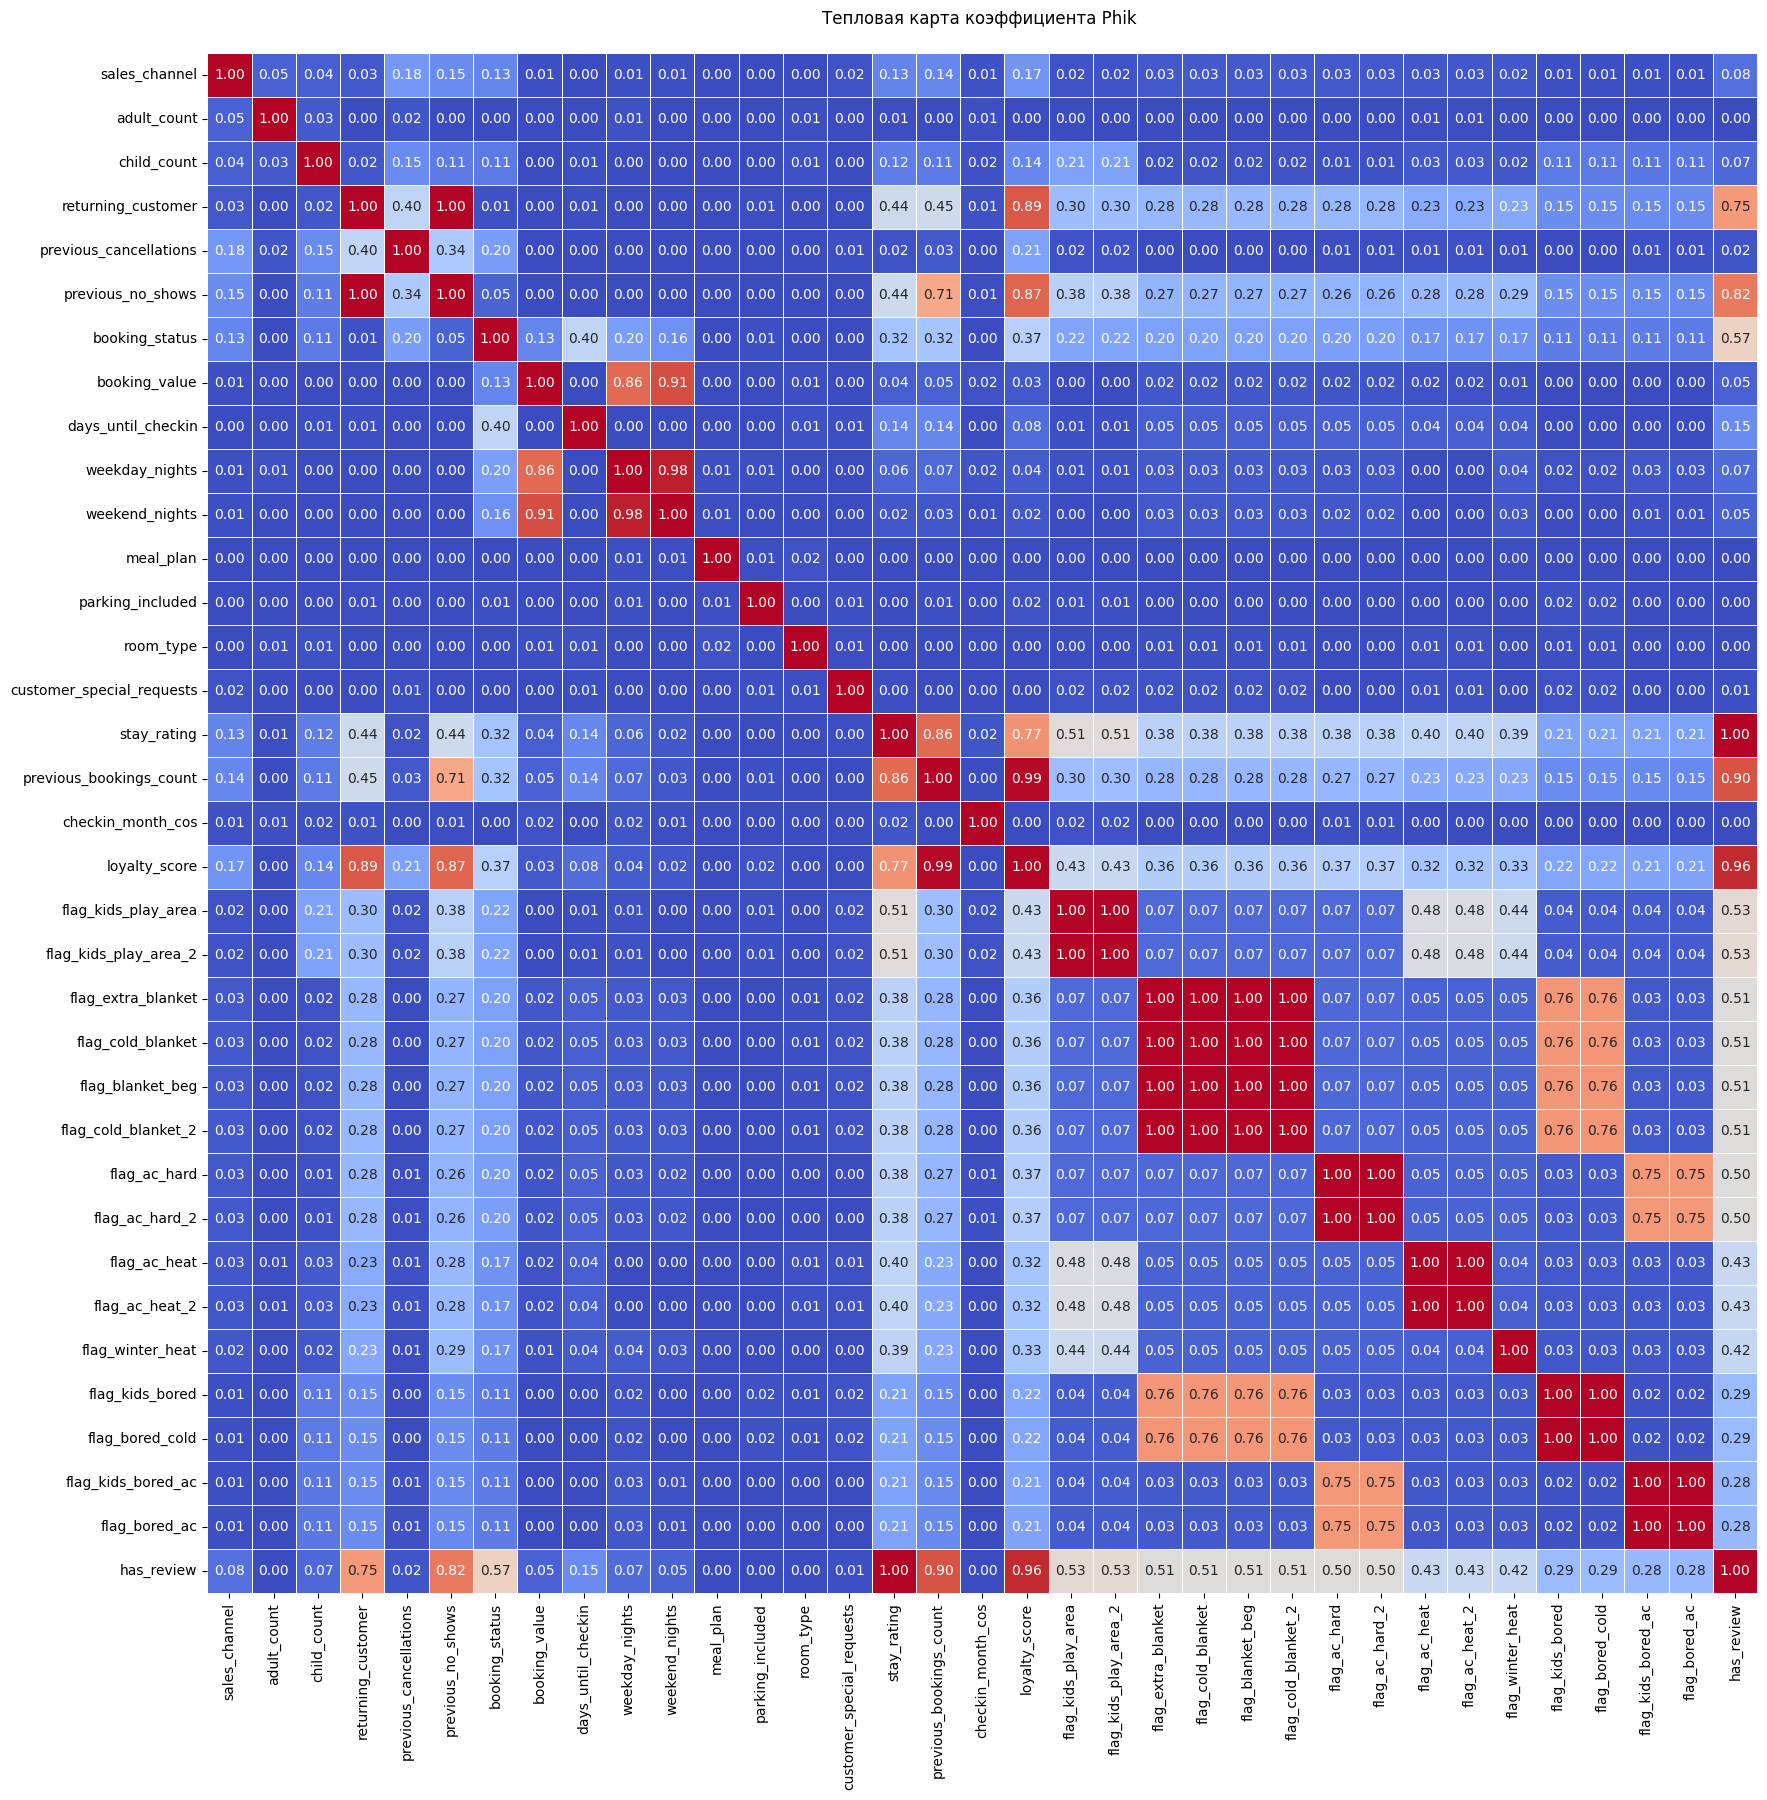

In [56]:
# Построим матрицу корреляций Phik

phik_coolwarm_matrix(df=df_hotel, target_var=target, interval_cols=numerical_features, matrix_view=True, figsize=(20,20))

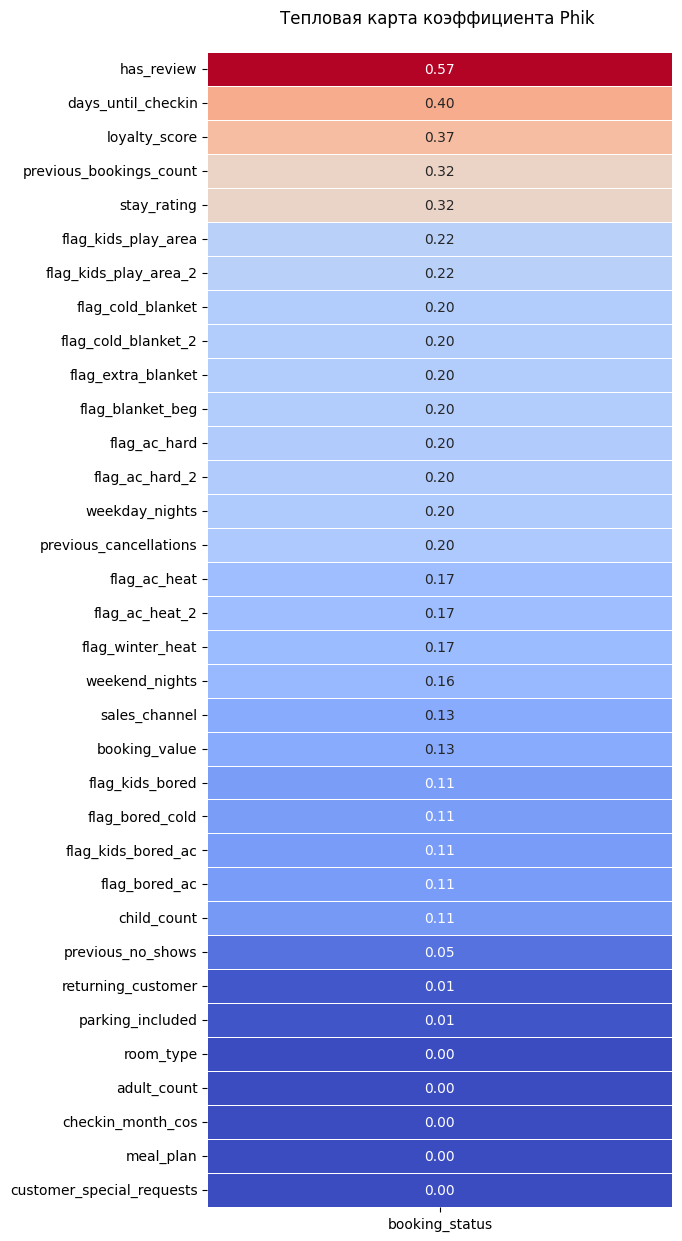

In [57]:
# Анализ коррелиции признаков с целевой переменной по матрице Phik

phik_coolwarm_matrix(df=df_hotel, target_var=target, interval_cols=numerical_features, matrix_view=False, figsize=(6,15))

### Итоговый анализ подготовленного датасета `df_hotel`

**Структура и общие характеристики**

Итоговый датасет содержит **30 733 строки и 35 признаков** (включая целевую переменную `booking_status`).

Признаки разделены на:
- **Числовые** (32 колонки): `int8`, `int16`, `float32`, `float64` — включают счётчики, бинарные флаги, cyclical‑признаки и агрегаты.
- **Категориальные** (3 колонки): `sales_channel`, `meal_plan`, `room_type` — требуют кодирования перед обучением (One‑Hot или встроенная обработка CatBoost/LightGBM).

**Пропусков нет** — все 35 колонок заполнены. Пропуски в `stay_rating` и текстовых полях обработаны заранее (`-1` для рейтинга, `0` для флагов, `has_review` как явный индикатор).

**Числовые характеристики**

| Признак | Ключевые наблюдения |
|---|---|
| `booking_status` | **Дисбаланс классов**: ~29% отмен (mean = 0.288), ~71% подтверждённых броней. Учтём при обучении (stratified split, class weights). |
| `adult_count` | 1–3, медиана 2. Большинство броней — на 1–2 взрослых. |
| `child_count` | 0–2, 75% броней без детей. Детей мало, но флаги по детям могут быть информативны. |
| `returning_customer` | ~56% — возвращающиеся клиенты. |
| `previous_cancellations` | 0–5, медиана 0. Большинство клиентов не отменяли ранее. |
| `previous_no_shows` | 0–5, медиана 1. Около 84% клиентов хотя бы раз заехали по брони. |
| `booking_value` | От 0 до ~417k, медиана ~60k. Распределение умеренно скошено вправо. |
| `days_until_checkin` | 2–300, медиана 90. Широкий диапазон — ключевой предиктор отмены. |
| `weekday_nights` / `weekend_nights` | 1–15 и 0–6 соответственно. Сильно коррелируют между собой и с `booking_value`. |
| `parking_included` | ~3% броней с парковкой — очень редкий признак. |
| `customer_special_requests` | 0–5, медиана 0. Большинство клиентов не оставляют специальных запросов. |
| `stay_rating` | -1 до 5. Значение -1 (73% строк) — технический маркер отсутствия отзыва. Реальные оценки: медиана 3, 75% перцентиль — 3. |
| `previous_bookings_count` | 0–4, медиана 0. Большинство клиентов бронируют впервые. |
| `loyalty_score` | 0–14, медиана 0. Сильно скошено: большинство клиентов с нулевой историей. |
| Флаги `flag_*` | Все бинарные. Доля единиц варьируется от ~1% (`flag_kids_bored`) до ~4.5% (`flag_kids_play_area`). Очень разреженные. |
| `has_review` | ~27% строк с отзывом. |

---

**Анализ Phik‑матрицы: корреляции с целевой переменной**


**Топ‑признаки по связи с `booking_status`**

| Признак | Phik с `booking_status` | Интерпретация |
|---|---|---|
| **`has_review`** | **0.572** | Сильнейший предиктор. Наличие отзыва тесно связано с исходом брони — клиенты без отзывов чаще отменяют (или наоборот, подтвердившие брони чаще оставляют отзывы). |
| **`loyalty_score`** | **0.372** | Лояльность значимо связана с отменой: клиенты с высокой лояльностью реже отменяют. |
| **`days_until_checkin`** | **0.400** | Чем дальше дата заезда, тем выше риск отмены — логично и подтверждается данными. |
| **`previous_bookings_count`** | **0.321** | Опыт клиента снижает вероятность отмены. |
| **`stay_rating`** | **0.318** | Рейтинг предыдущего отзыва коррелирует с исходом. |
| **`weekday_nights`** | **0.200** | Количество ночей в будни умеренно связано с отменой. |
| **`previous_cancellations`** | **0.196** | История отмен — ожидаемый предиктор. |
| **`weekend_nights`** | **0.162** | Слабее будних ночей, но всё же информативен. |
| **`sales_channel`** | **0.134** | Канал бронирования влияет на отмену (например, офлайн‑брони могут быть стабильнее). |
| **`child_count`** | **0.107** | Наличие детей слабо, но связано с отменой. |

**Вывод по целевой переменной**: наиболее сильные предикторы — поведенческие (`has_review`, `loyalty_score`, `previous_bookings_count`) и временные (`days_until_checkin`). Категориальные признаки и текстовые флаги дают умеренный вклад.


**Анализ Phik‑матрицы: межпризнаковые корреляции**

**Критические избыточности (Phik ≈ 1.0)**

| Пара признаков | Phik | Проблема |
|---|---|---|
| `returning_customer` ↔ `previous_no_shows` | **1.000** | Практически идентичны. `returning_customer` = 1 почти всегда, когда `previous_no_shows` ≥ 1. Один из них избыточен. |
| `stay_rating` ↔ `has_review` | **1.000** | Ожидаемо: `stay_rating = -1` ровно когда `has_review = 0`. Это техническая избыточность, вызванная заполнением пропусков. |
| `previous_bookings_count` ↔ `loyalty_score` | **0.994** | `loyalty_score` почти полностью определяется `previous_bookings_count`, так как штрафы за отмены (`previous_cancellations`) и бонусы за заезды (`previous_no_shows`) в большинстве случаев малы или нулевые. Один из двух признаков избыточен. |
| `loyalty_score` ↔ `has_review` | **0.965** | Косвенная корреляция через `previous_bookings_count` и `stay_rating`. |
| `previous_bookings_count` ↔ `has_review` | **0.897** | Клиенты с историей броней чаще оставляют отзывы. |

**Дублирующие текстовые флаги (Phik ≈ 1.0)**

| Группа флагов | Phik внутри группы | Описание |
|---|---|---|
| `flag_kids_play_area` ↔ `flag_kids_play_area_2` | **1.000** | Идентичны — фразы являются подстроками друг друга. |
| `flag_extra_blanket` ↔ `flag_cold_blanket` ↔ `flag_blanket_beg` ↔ `flag_cold_blanket_2` | **1.000** | Все четыре флага срабатывают на одной и той же группе отзывов — фразы описывают одну проблему с разных сторон. |
| `flag_ac_hard` ↔ `flag_ac_hard_2` | **1.000** | Идентичны. |
| `flag_ac_heat` ↔ `flag_ac_heat_2` | **1.000** | Идентичны. |
| `flag_kids_bored` ↔ `flag_bored_cold` | **0.99995** | Практически идентичны. |
| `flag_kids_bored_ac` ↔ `flag_bored_ac` | **0.99995** | Практически идентичны. |

**Вывод**: из 15 текстовых флагов реально независимых — около 6–7. Остальные дубликаты **следует удалить** перед обучением, чтобы избежать мультиколлинеарности и снижения интерпретируемости.

**Высокие, но объяснимые корреляции**

| Пара | Phik | Комментарий |
|---|---|---|
| `weekday_nights` ↔ `weekend_nights` | 0.975 | Ожидаемо: ночи часто идут в паре. Можно оставить оба — деревья справятся. |
| `weekend_nights` ↔ `booking_value` | 0.907 | Выходные дороже — экономически логично. |
| `weekday_nights` ↔ `booking_value` | 0.858 | Аналогично. |
| `child_count` ↔ `flag_kids_play_area` | 0.208 | Дети → отзывы об игровой зоне — логичная, но умеренная связь. |
| `child_count` ↔ `flag_kids_bored` | 0.108 | Слабее, но направление верное. |

**Признаки с минимальной связью с чем‑либо**

`checkin_month_cos` практически не коррелирует ни с целевой переменной (0.000), ни с другими признаками. Это может означать, что сезонность не является значимым фактором отмены в данных.

---


In [58]:
# Удаляем дублирующие флаги — по одному представителю из каждой группы идентичных
dup_flags_to_drop = [
    'flag_kids_play_area_2',   # дубликат flag_kids_play_area
    'flag_cold_blanket',       # дубликат flag_extra_blanket
    'flag_blanket_beg',        # дубликат flag_extra_blanket
    'flag_cold_blanket_2',     # дубликат flag_extra_blanket
    'flag_ac_hard_2',          # дубликат flag_ac_hard
    'flag_ac_heat_2',          # дубликат flag_ac_heat
    'flag_bored_cold',         # дубликат flag_kids_bored
    'flag_bored_ac',           # дубликат flag_kids_bored_ac
]

df_hotel = df_hotel.drop(columns=dup_flags_to_drop)

print(f"Удалено дублирующих флагов: {len(dup_flags_to_drop)}")
print(f"Осталось флагов: {len([c for c in df_hotel.columns if c.startswith('flag_')])}")
print(f"Итоговое число признаков: {df_hotel.shape[1]}")


Удалено дублирующих флагов: 8
Осталось флагов: 7
Итоговое число признаков: 27


## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

### 2.1 Разделение данных на выборки

In [59]:
# Приводим категориальные признаки к типу category
for col in categorical_features:
	# приведение всех категориальных признаков к pd.categorical
	df_hotel[col] = df_hotel[col].astype('category')

df_hotel.info()

<class 'pandas.DataFrame'>
Index: 30733 entries, 23113 to 30732
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   sales_channel              30733 non-null  category
 1   adult_count                30733 non-null  int16   
 2   child_count                30733 non-null  int8    
 3   returning_customer         30733 non-null  int8    
 4   previous_cancellations     30733 non-null  int8    
 5   previous_no_shows          30733 non-null  int8    
 6   booking_status             30733 non-null  int8    
 7   booking_value              30733 non-null  float64 
 8   days_until_checkin         30733 non-null  int16   
 9   weekday_nights             30733 non-null  int8    
 10  weekend_nights             30733 non-null  int8    
 11  meal_plan                  30733 non-null  category
 12  parking_included           30733 non-null  int8    
 13  room_type                  30733 non-null  

In [60]:
# 1. Разделяем признаки и целевую переменную
X = df_hotel.drop(columns=[target])
y = df_hotel[target]

# 2. Независимое разбиение train_val (60%), calib (20%), test (20%)
# Отделяем финальный тестовый набор 20%
X_train_val_calib, X_test, y_train_val_calib, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Отделяем калибровочную выборку 20% от исходных данных (т.е. 25% от train_val_calib)
X_train_val, X_calib, y_train_val, y_calib = train_test_split(
    X_train_val_calib, y_train_val_calib,
    test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_val_calib
)

# 3. Проверка размеров выборки с процентами
total_rows = X.shape[0]

train_val_size = X_train_val.shape[0]
calib_size = X_calib.shape[0]
test_size = X_test.shape[0]

train_val_pct = train_val_size / total_rows * 100
calib_pct = calib_size / total_rows * 100
test_pct = test_size / total_rows * 100

print(f"Общее количество записей: {total_rows}")
print("-" * 85)
print(f"{'Набор данных':<25} | {'Размер':<10} | {'Доля от общего':<15} | {'Цель'}")
print("-" * 85)
print(f"Тренировочный (train_val) | {train_val_size:<10} | {train_val_pct:>6.1f}%         | Обучение модели и кросс-валидация")
print(f"Калибровочный (calib)     | {calib_size:<10} | {calib_pct:>6.1f}%         | Калибровка модели")
print(f"Тестовый (test)           | {test_size:<10} | {test_pct:>6.1f}%         | Финальная независимая оценка")
print("-" * 85)
print(f"Сумма: {train_val_size + calib_size + test_size}")


Общее количество записей: 30733
-------------------------------------------------------------------------------------
Набор данных              | Размер     | Доля от общего  | Цель
-------------------------------------------------------------------------------------
Тренировочный (train_val) | 18439      |   60.0%         | Обучение модели и кросс-валидация
Калибровочный (calib)     | 6147       |   20.0%         | Калибровка модели
Тестовый (test)           | 6147       |   20.0%         | Финальная независимая оценка
-------------------------------------------------------------------------------------
Сумма: 30733


In [61]:
# Сплиттер: 3 фолда, 2000 записей на валидацию, стратификация

cv = StratifiedShuffleSplit(
    n_splits=3,
    test_size=2000,
    random_state=RANDOM_SEED
)

### 2.2 Словарь с метриками

In [62]:
# ============================================================
# Обёртки для бизнес-метрик — возвращают скаляр для make_scorer
# ============================================================

def _ir(y_true, y_pred):
    return incremental_revenue(y_true, y_pred)[0]

def _ir_relative(y_true, y_pred):
    return incremental_revenue(y_true, y_pred)[1]

def _ir_before(y_true, y_pred):
    return incremental_revenue(y_true, y_pred)[2]

def _ir_after(y_true, y_pred):
    return incremental_revenue(y_true, y_pred)[3]

def _cancellation_dynamics(y_true, y_pred):
    return cancellation_dynamics(y_true, y_pred)[0]

def _cancellation_rate_before(y_true, y_pred):
    return cancellation_dynamics(y_true, y_pred)[1]

def _cancellation_rate_after(y_true, y_pred):
    return cancellation_dynamics(y_true, y_pred)[2]

def _occupancy_dynamics(y_true, y_pred):
    return occupancy_dynamics(y_true, y_pred)[0]

def _occupancy_before(y_true, y_pred):
    return occupancy_dynamics(y_true, y_pred)[1]

def _occupancy_after(y_true, y_pred):
    return occupancy_dynamics(y_true, y_pred)[2]


# ============================================================
# Словарь скореров
# ============================================================

scorers = {
    # Стандартные ML-метрики
    'accuracy':  make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall':    make_scorer(recall_score),
    'f1':        make_scorer(f1_score),
    # Бизнес-метрики
    'ir':                    make_scorer(_ir),
    'ir_relative':           make_scorer(_ir_relative),
    'ir_before':             make_scorer(_ir_before),
    'ir_after':              make_scorer(_ir_after),
    'cancellation_dynamics': make_scorer(_cancellation_dynamics),
    'cancellation_rate_before': make_scorer(_cancellation_rate_before),
    'cancellation_rate_after':  make_scorer(_cancellation_rate_after),
    'occupancy_dynamics':    make_scorer(_occupancy_dynamics),
    'occupancy_before':      make_scorer(_occupancy_before),
    'occupancy_after':       make_scorer(_occupancy_after),
}


### 2.3 Выбор и создание базовых моделей и пайплайнов

#### 2.3.1 Random Forest

In [63]:
# В качестве базовых выбираем 4 модели на основе вешающих деревьев: RandomForest, XGBoost, LightGBM, CatBoost
# ===========================================================================================================


# 1. Random  Forest

 # Преобразование категориальных признаков One Hot Encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

column_transform = ColumnTransformer(
    transformers=[
        ('cat', ohe, categorical_features)
    ],
    remainder='passthrough'
)

preprocessor = Pipeline(
    steps=[
        ('column_transform', column_transform)
    ]
)

model_rfc_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    min_samples_leaf=10,
    class_weight = 'balanced',
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

pipeline_rfc_base = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model_rfc_base)
    ]
)

pipeline_rfc_base


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or est

In [64]:
# Кросс-валидация базовой модели Random Forest
# ---------------------------------------------------------
cv_results_rfc_base = cross_validate(
    estimator=pipeline_rfc_base,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

df_cv_results = update_metrics_df(metrics_dict=cv_results_rfc_base, model_name='RandomForest base')

format_cv_results(df_cv_results)

,model,accuracy,precision,recall,f1,ir,ir_relative,ir_before,ir_after,cancellation_dynamics,cancellation_rate_before,cancellation_rate_after,occupancy_dynamics,occupancy_before,occupancy_after
0,RandomForest base,0.7575,0.5480,0.9022,0.6818,"26,253,833",0.4800,"54,696,000","80,949,833",0.9022,0.2880,0.0282,-0.3649,0.7120,0.9718


#### 2.3.2 XGBoost

In [65]:
# XGBoost

# Baseline параметры
params_xgb_base = {
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.1,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'scale_pos_weight': (y_train_val == 0).sum() / (y_train_val == 1).sum()
}

model_xgboost_base = XGBClassifier(
    **params_xgb_base,
    enable_categorical=True,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

In [66]:
# Кросс-валидация базовой модели XGBoost
# ---------------------------------------------------------
cv_results_xgboost_base = cross_validate(
    estimator=model_xgboost_base,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

df_cv_results = update_metrics_df(metrics_dict=cv_results_xgboost_base, model_name='XGBoost base', df_in=df_cv_results)

format_cv_results(df_cv_results)

,model,accuracy,precision,recall,f1,ir,ir_relative,ir_before,ir_after,cancellation_dynamics,cancellation_rate_before,cancellation_rate_after,occupancy_dynamics,occupancy_before,occupancy_after
0,RandomForest base,0.7575,0.5480,0.9022,0.6818,"26,253,833",0.4800,"54,696,000","80,949,833",0.9022,0.2880,0.0282,-0.3649,0.7120,0.9718
1,XGBoost base,0.8063,0.6208,0.8420,0.7146,"31,919,667",0.5836,"54,696,000","86,615,667",0.8420,0.2880,0.0455,-0.3406,0.7120,0.9545


#### 2.3.3 LightGBM

In [67]:
# LightGBM

# Baseline параметры
params_lightgbm_base = {
    'n_estimators': 200,
    'max_depth': 4,
    'num_leaves': 5,
    'learning_rate': 0.1,
    'scale_pos_weight': (y_train_val == 0).sum() / (y_train_val == 1).sum(),
}

model_lightgbm_base = LGBMClassifier(
    **params_lightgbm_base,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

In [68]:
# Кросс-валидация базовой модели LightGBM
# ---------------------------------------------------------
cv_results_lightgbm_base = cross_validate(
    estimator=model_lightgbm_base,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

df_cv_results = update_metrics_df(metrics_dict=cv_results_lightgbm_base, model_name='LightGBM base', df_in=df_cv_results)

format_cv_results(df_cv_results)

,model,accuracy,precision,recall,f1,ir,ir_relative,ir_before,ir_after,cancellation_dynamics,cancellation_rate_before,cancellation_rate_after,occupancy_dynamics,occupancy_before,occupancy_after
0,RandomForest base,0.7575,0.5480,0.9022,0.6818,"26,253,833",0.4800,"54,696,000","80,949,833",0.9022,0.2880,0.0282,-0.3649,0.7120,0.9718
1,XGBoost base,0.8063,0.6208,0.8420,0.7146,"31,919,667",0.5836,"54,696,000","86,615,667",0.8420,0.2880,0.0455,-0.3406,0.7120,0.9545
2,LightGBM base,0.8045,0.6149,0.8594,0.7169,"32,037,500",0.5857,"54,696,000","86,733,500",0.8594,0.2880,0.0405,-0.3476,0.7120,0.9595


#### 2.3.4 CatBoost

In [69]:
# CatBoost

# Baseline параметры
params_catboost = {
    'iterations': 200,
    'depth': 4,
    'learning_rate': 0.1,
    'auto_class_weights': 'Balanced'
}

In [70]:
def cross_validate_catboost(X, y, cv, params, cat_features, model_name, df_in=None, print_report=True):
    fold_results = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Свежая модель на каждый фолд
        model = CatBoostClassifier(
            **params,
            cat_features=cat_features,
            random_state=RANDOM_SEED,
            verbose=0
        )
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        fold_results.append({
            'accuracy': accuracy_score(y_val, y_pred),
            'precision': precision_score(y_val, y_pred),
            'recall': recall_score(y_val, y_pred),
            'f1': f1_score(y_val, y_pred),
            'ir': _ir(y_val, y_pred),
            'ir_relative': _ir_relative(y_val, y_pred),
            'ir_before': _ir_before(y_val, y_pred),
            'ir_after': _ir_after(y_val, y_pred),
            'cancellation_dynamics': _cancellation_dynamics(y_val, y_pred),
            'cancellation_rate_before': _cancellation_rate_before(y_val, y_pred),
            'cancellation_rate_after': _cancellation_rate_after(y_val, y_pred),
            'occupancy_dynamics': _occupancy_dynamics(y_val, y_pred),
            'occupancy_before': _occupancy_before(y_val, y_pred),
            'occupancy_after': _occupancy_after(y_val, y_pred),
        })
        if print_report:
            print(f'  Fold {fold_idx + 1} done')
    
    df_fold = pd.DataFrame(fold_results)
    row = {'model': model_name}
    row.update(df_fold.mean().to_dict())
    
    if df_in is not None:
        return pd.concat([df_in, pd.DataFrame([row])], ignore_index=True)
    return pd.DataFrame([row])


In [71]:
df_cv_results = cross_validate_catboost(
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    params=params_catboost,
    cat_features=categorical_features,
    model_name='CatBoost base',
    df_in=df_cv_results
)

format_cv_results(df_cv_results)

  Fold 1 done
  Fold 2 done
  Fold 3 done


,model,accuracy,precision,recall,f1,ir,ir_relative,ir_before,ir_after,cancellation_dynamics,cancellation_rate_before,cancellation_rate_after,occupancy_dynamics,occupancy_before,occupancy_after
0,RandomForest base,0.7575,0.5480,0.9022,0.6818,"26,253,833",0.4800,"54,696,000","80,949,833",0.9022,0.2880,0.0282,-0.3649,0.7120,0.9718
1,XGBoost base,0.8063,0.6208,0.8420,0.7146,"31,919,667",0.5836,"54,696,000","86,615,667",0.8420,0.2880,0.0455,-0.3406,0.7120,0.9545
2,LightGBM base,0.8045,0.6149,0.8594,0.7169,"32,037,500",0.5857,"54,696,000","86,733,500",0.8594,0.2880,0.0405,-0.3476,0.7120,0.9595
3,CatBoost base,0.8057,0.6177,0.8536,0.7167,"32,077,667",0.5865,"54,696,000","86,773,667",0.8536,0.2880,0.0422,-0.3453,0.7120,0.9578


### Вывод по итогам обучения базовых моделей

В рамках этапа baseline-моделирования обучены четыре модели: Random Forest, XGBoost, LightGBM и CatBoost. Кросс-валидация проводилась на 3 фолдах (StratifiedShuffleSplit, 2000 объектов на валидацию) с использованием стандартных метрик классификации (accuracy, precision, recall, F1) и бизнес-метрик (ir, ir_relative, ir_before, ir_after, cancellation_dynamics, cancellation_rate_before, cancellation_rate_after, occupancy_dynamics, occupancy_before, occupancy_after). Все модели настроены в сопоставимых условиях — с компенсацией дисбаланса классов и нативной обработкой категориальных признаков.

**Сравнение базовых моделей**

| | Random Forest | XGBoost | LightGBM | CatBoost |
|---|---|---|---|---|
| Деревья / итерации | 200 | 200 | 200 | 200 |
| Глубина | 7 | 4 | 4 | 4 |
| Learning rate | — | 0.1 | 0.1 | 0.1 |
| Листья | — | — | 5 | — |
| Балансировка | `class_weight='balanced'` | `scale_pos_weight` | `scale_pos_weight` | `auto_class_weights='Balanced'` |
| Subsample | `bootstrap=True` | нет | нет | нет |
| Категориальные | OrdinalEncoder | `enable_categorical=True` | pandas `category` | `cat_features` |

**Результаты кросс-валидации**

| Модель | Accuracy | Precision | Recall | F1 | ir | ir_relative | ir_before | ir_after | cancellation_dynamics | cancellation_rate_before | cancellation_rate_after | occupancy_dynamics | occupancy_before | occupancy_after |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| RandomForest base | 0.7575 | 0.5480 | **0.9022** | 0.6818 | 26 253 833 | 0.4800 | **54 696 000** | 80 949 833 | **0.9022** | **0.2880** | **0.0282** | -0.3649 | **0.7120** | **0.9718** |
| XGBoost base | **0.8063** | **0.6208** | 0.8420 | 0.7146 | 31 919 667 | 0.5836 | **54 696 000** | 86 615 667 | 0.8420 | **0.2880** | 0.0455 | **-0.3406** | **0.7120** | 0.9545 |
| LightGBM base | 0.8045 | 0.6149 | **0.8594** | **0.7169** | 32 037 500 | 0.5857 | **54 696 000** | 86 733 500 | 0.8594 | **0.2880** | 0.0405 | -0.3476 | **0.7120** | 0.9595 |
| CatBoost base | 0.8057 | 0.6177 | 0.8536 | 0.7167 | **32 077 667** | **0.5865** | **54 696 000** | **86 773 667** | 0.8536 | **0.2880** | 0.0422 | -0.3453 | **0.7120** | 0.9578 |

**Анализ результатов**

Random Forest показал худший результат: precision на уровне 0.548 при высоком recall (0.902) означает, что модель пере‑предсказывает отмены, генерируя большое количество ложных срабатываний (FP). Каждый FP стоит 7 000 руб., и это напрямую отражается в `ir` = 26 253 833 руб. — на 18 % ниже, чем у бустингов. При этом RF достигает максимального снижения доли отмен (`cancellation_dynamics` = 0.902) и максимальной загрузки (`occupancy_after` = 0.972), но цена этого — чрезмерное количество ложных срабатываний, которые съедают экономический эффект.

Три бустинга показали близкие результаты, лежащие в пределах погрешности. CatBoost лидирует по абсолютному приросту дохода `ir` (32 077 667 руб.) и относительному `ir_relative` (0.5865) за счёт оптимального баланса precision и recall. LightGBM лучше ловит отмены (recall = 0.859), XGBoost точнее в предсказаниях (precision = 0.621), но разрыв между ними по `ir_relative` составляет менее 0.003 — это шум на уровне baseline.

Отрицательное значение `occupancy_dynamics` отражает положительный эффект: загрузка отелей после применения модели стала выше, чем до. Это говорит о том, что корректное предсказание отмен позволяет эффективнее управлять номерным фондом и повышает заполняемость. Тем не менее, при оптимизации гиперпараметров важно следить, чтобы рост occupancy не достигался за счёт чрезмерного снижения точности — иначе издержки от ложных срабатываний могут перекрыть выгоду от роста загрузки.

**Решение**

Random Forest исключается из дальнейшего этапа оптимизации. Для подбора гиперпараметров в Optuna остаются **три модели**: XGBoost, LightGBM и CatBoost.

---

### 2.4 Оптимизация Optuna

#### 2.4.1 XGBoost Optuna

In [72]:
# ============================================================
# Optuna: функция objective для XGBoost
# ============================================================

def objective_xgb(trial):
    """
    Целевая функция для оптимизации XGBoost.
    Возвращает средний ir (Incremental Revenue) по фолдам кросс-валидации.
    """

    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }

    model = XGBClassifier(
        **params,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=(y_train_val == 0).sum() / (y_train_val == 1).sum(),
        enable_categorical=True,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    cv_results = cross_validate(
        estimator=model,
        X=X_train_val,
        y=y_train_val,
        cv=cv,
        scoring=scorers,
        return_train_score=False,
        n_jobs=-1
    )

    return round(cv_results['test_ir'].mean(), 2)


In [73]:
# Запуск исследования
# Фиксируем сид через самплер
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

# Лучшие гиперпараметры и качество
xgb_best_params = study.best_params
print("Лучшие гиперпараметры:", xgb_best_params)
xgb_best_value = study.best_value
print("Лучшее значение IR XGBoost:", xgb_best_value)

[I 2026-09-13 18:16:45,104] A new study created in memory with name: no-name-c8d3e4f0-63f9-447c-9d8f-7466dafc9069


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-13 18:16:46,296] Trial 0 finished with value: 30023833.33 and parameters: {'learning_rate': 0.013459409731446636, 'max_depth': 4, 'n_estimators': 264, 'subsample': 0.7243130794240348, 'colsample_bytree': 0.8263823563046022, 'reg_lambda': 0.0008045875980552012, 'min_child_weight': 9}. Best is trial 0 with value: 30023833.33.
[I 2026-09-13 18:16:48,079] Trial 1 finished with value: 28456166.67 and parameters: {'learning_rate': 0.22710485788792972, 'max_depth': 6, 'n_estimators': 270, 'subsample': 0.6287215818198552, 'colsample_bytree': 0.9594115400716872, 'reg_lambda': 6.090100149327966e-05, 'min_child_weight': 6}. Best is trial 0 with value: 30023833.33.
[I 2026-09-13 18:16:49,914] Trial 2 finished with value: 31557833.33 and parameters: {'learning_rate': 0.020717184780378917, 'max_depth': 5, 'n_estimators': 287, 'subsample': 0.6402548627747919, 'colsample_bytree': 0.9709151579208837, 'reg_lambda': 2.8111343314629743e-07, 'min_child_weight': 9}. Best is trial 2 with value: 31

C:\Users\artem\AppData\Local\Temp\ipykernel_107064\768031645.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\artem\AppData\Local\Temp\ipykernel_107064\768031645.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


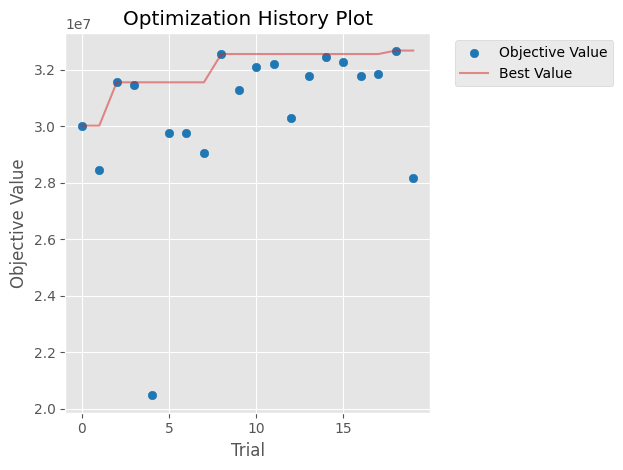

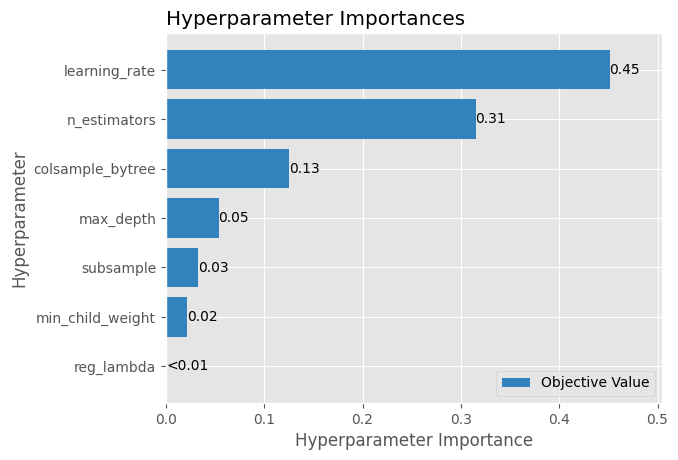

In [74]:
# Визуализация результатов
optuna.visualization.matplotlib.plot_optimization_history(study)
optuna.visualization.matplotlib.plot_param_importances(study)

plt.show()

In [75]:
# ============================================================
# Обучение лучшей модели XGBoost
# ============================================================

# Инициализируем модель с лучшими параметрами Optuna
xgb_best_model = XGBClassifier(
    **xgb_best_params,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=(y_train_val == 0).sum() / (y_train_val == 1).sum(),
    enable_categorical=True,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Кросс-валидация для получения всех метрик
cv_metrics_xgb_best = cross_validate(
    estimator=xgb_best_model,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

# Добавляем строку в таблицу результатов
df_cv_results = update_metrics_df(
    metrics_dict=cv_metrics_xgb_best,
    model_name='XGBoost Optuna',
    df_in=df_cv_results
)

format_cv_results(df_cv_results)


,model,accuracy,precision,recall,f1,ir,ir_relative,ir_before,ir_after,cancellation_dynamics,cancellation_rate_before,cancellation_rate_after,occupancy_dynamics,occupancy_before,occupancy_after
0,RandomForest base,0.7575,0.5480,0.9022,0.6818,"26,253,833",0.4800,"54,696,000","80,949,833",0.9022,0.2880,0.0282,-0.3649,0.7120,0.9718
1,XGBoost base,0.8063,0.6208,0.8420,0.7146,"31,919,667",0.5836,"54,696,000","86,615,667",0.8420,0.2880,0.0455,-0.3406,0.7120,0.9545
2,LightGBM base,0.8045,0.6149,0.8594,0.7169,"32,037,500",0.5857,"54,696,000","86,733,500",0.8594,0.2880,0.0405,-0.3476,0.7120,0.9595
3,CatBoost base,0.8057,0.6177,0.8536,0.7167,"32,077,667",0.5865,"54,696,000","86,773,667",0.8536,0.2880,0.0422,-0.3453,0.7120,0.9578
4,XGBoost Optuna,0.8132,0.6338,0.8322,0.7195,"32,681,500",0.5975,"54,696,000","87,377,500",0.8322,0.2880,0.0483,-0.3366,0.7120,0.9517


#### 2.4.1 LightGBM Optuna

In [76]:
# ============================================================
# Optuna: функция objective для LightGBM
# ============================================================

def objective_lgbm(trial):
    """
    Целевая функция для оптимизации LightGBM.
    Возвращает средний ir (Incremental Revenue) по фолдам кросс-валидации.
    """

    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'num_leaves': trial.suggest_int('num_leaves', 5, 50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    model = LGBMClassifier(
        **params,
        scale_pos_weight=(y_train_val == 0).sum() / (y_train_val == 1).sum(),
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1
    )

    cv_results = cross_validate(
        estimator=model,
        X=X_train_val,
        y=y_train_val,
        cv=cv,
        scoring=scorers,
        return_train_score=False,
        n_jobs=-1
    )

    return round(cv_results['test_ir'].mean(), 2)


In [77]:
# Запуск исследования
# Фиксируем сид через самплер
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)

# Лучшие гиперпараметры и качество
lgb_best_params = study.best_params
print("Лучшие гиперпараметры:", lgb_best_params)
lgb_best_value = study.best_value
print("Лучшее значение IR LightGBM:", lgb_best_value)

[I 2026-09-13 18:17:14,953] A new study created in memory with name: no-name-d92702ba-a903-4ec7-aeb8-867f34e14551


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-13 18:17:15,459] Trial 0 finished with value: 29929833.33 and parameters: {'learning_rate': 0.013459409731446636, 'n_estimators': 192, 'num_leaves': 23, 'max_depth': 4, 'subsample': 0.8263823563046022, 'colsample_bytree': 0.8180254815135402, 'reg_lambda': 0.18360943130946591}. Best is trial 0 with value: 29929833.33.
[I 2026-09-13 18:17:16,134] Trial 1 finished with value: 32552666.67 and parameters: {'learning_rate': 0.22710485788792972, 'n_estimators': 309, 'num_leaves': 24, 'max_depth': 3, 'subsample': 0.9594115400716872, 'colsample_bytree': 0.7682055304220186, 'reg_lambda': 0.001735913543238237}. Best is trial 1 with value: 32552666.67.
[I 2026-09-13 18:17:16,790] Trial 2 finished with value: 30203166.67 and parameters: {'learning_rate': 0.020717184780378917, 'n_estimators': 279, 'num_leaves': 26, 'max_depth': 3, 'subsample': 0.9709151579208837, 'colsample_bytree': 0.6643947377370129, 'reg_lambda': 0.7436141177688895}. Best is trial 1 with value: 32552666.67.
[I 2026-09-

C:\Users\artem\AppData\Local\Temp\ipykernel_107064\768031645.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\artem\AppData\Local\Temp\ipykernel_107064\768031645.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


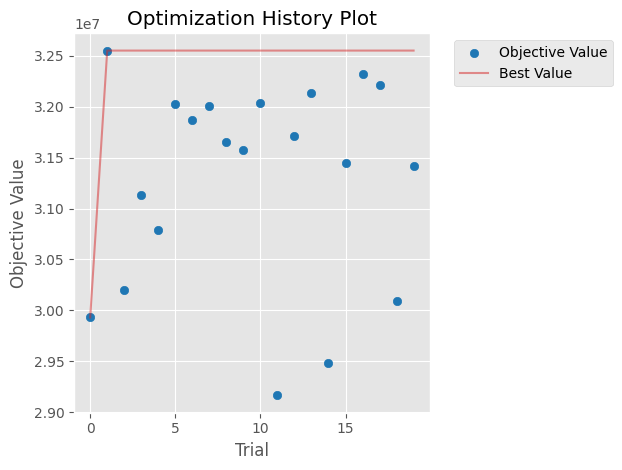

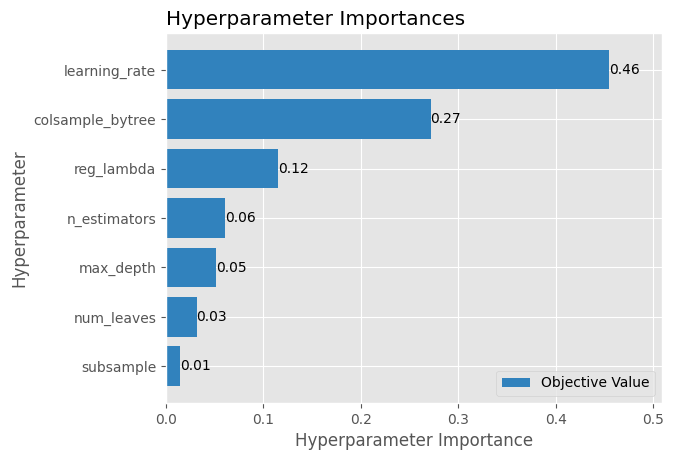

In [78]:
# Визуализация результатов
optuna.visualization.matplotlib.plot_optimization_history(study)
optuna.visualization.matplotlib.plot_param_importances(study)

plt.show()

In [79]:
# ============================================================
# Обучение лучшей модели LightGBM
# ============================================================

# Инициализируем модель с лучшими параметрами Optuna
lgbm_best_model = LGBMClassifier(
    **lgb_best_params,
    scale_pos_weight=(y_train_val == 0).sum() / (y_train_val == 1).sum(),
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

# Кросс-валидация для получения всех метрик
cv_metrics_lgbm_best = cross_validate(
    estimator=lgbm_best_model,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

# Добавляем строку в таблицу результатов
df_cv_results = update_metrics_df(
    metrics_dict=cv_metrics_lgbm_best,
    model_name='LightGBM Optuna',
    df_in=df_cv_results
)

format_cv_results(df_cv_results)


,model,accuracy,precision,recall,f1,ir,ir_relative,ir_before,ir_after,cancellation_dynamics,cancellation_rate_before,cancellation_rate_after,occupancy_dynamics,occupancy_before,occupancy_after
0,RandomForest base,0.7575,0.5480,0.9022,0.6818,"26,253,833",0.4800,"54,696,000","80,949,833",0.9022,0.2880,0.0282,-0.3649,0.7120,0.9718
1,XGBoost base,0.8063,0.6208,0.8420,0.7146,"31,919,667",0.5836,"54,696,000","86,615,667",0.8420,0.2880,0.0455,-0.3406,0.7120,0.9545
2,LightGBM base,0.8045,0.6149,0.8594,0.7169,"32,037,500",0.5857,"54,696,000","86,733,500",0.8594,0.2880,0.0405,-0.3476,0.7120,0.9595
3,CatBoost base,0.8057,0.6177,0.8536,0.7167,"32,077,667",0.5865,"54,696,000","86,773,667",0.8536,0.2880,0.0422,-0.3453,0.7120,0.9578
4,XGBoost Optuna,0.8132,0.6338,0.8322,0.7195,"32,681,500",0.5975,"54,696,000","87,377,500",0.8322,0.2880,0.0483,-0.3366,0.7120,0.9517
5,LightGBM Optuna,0.8120,0.6316,0.8339,0.7187,"32,552,667",0.5952,"54,696,000","87,248,667",0.8339,0.2880,0.0478,-0.3373,0.7120,0.9522


#### 2.4.1 CatBoost Optuna

In [80]:
# ============================================================
# Optuna: функция objective для CatBoost
# ============================================================

def objective_catboost(trial):
    """
    Целевая функция для оптимизации CatBoost.
    Возвращает средний ir (Incremental Revenue) по фолдам кросс-валидации.
    """

    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'auto_class_weights': 'Balanced',
    }

    df_result = cross_validate_catboost(
        X=X_train_val,
        y=y_train_val,
        cv=cv,
        params=params,
        cat_features=categorical_features,
        model_name='catboost_opt_trial',
        print_report=False
    )

    return round(df_result['ir'].iloc[0], 2)


In [81]:
# Запуск исследования
# Фиксируем сид через самплер
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective_catboost, n_trials=20, show_progress_bar=True)

# Лучшие гиперпараметры и качество
cat_best_params = study.best_params
print("Лучшие гиперпараметры:", cat_best_params)
cat_best_value = study.best_value
print("Лучшее значение IR CatBoost:", cat_best_value)

[I 2026-09-13 18:17:49,886] A new study created in memory with name: no-name-b5936776-32e2-4d10-859e-bcd237258c36


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-13 18:18:34,853] Trial 0 finished with value: 30994833.33 and parameters: {'iterations': 135, 'depth': 4, 'learning_rate': 0.04047501742816068, 'l2_leaf_reg': 6.2667776667875636e-06, 'subsample': 0.8263823563046022, 'colsample_bylevel': 0.8180254815135402, 'min_data_in_leaf': 41}. Best is trial 0 with value: 30994833.33.
[I 2026-09-13 18:21:52,095] Trial 1 finished with value: 31945666.67 and parameters: {'iterations': 468, 'depth': 6, 'learning_rate': 0.0423949942214426, 'l2_leaf_reg': 4.428285276136153e-08, 'subsample': 0.9594115400716872, 'colsample_bylevel': 0.7682055304220186, 'min_data_in_leaf': 30}. Best is trial 1 with value: 31945666.67.
[I 2026-09-13 18:22:58,590] Trial 2 finished with value: 31692666.67 and parameters: {'iterations': 185, 'depth': 5, 'learning_rate': 0.049101139361212846, 'l2_leaf_reg': 8.048860722660695e-08, 'subsample': 0.9709151579208837, 'colsample_bylevel': 0.6643947377370129, 'min_data_in_leaf': 44}. Best is trial 1 with value: 31945666.67.


C:\Users\artem\AppData\Local\Temp\ipykernel_107064\768031645.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\artem\AppData\Local\Temp\ipykernel_107064\768031645.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


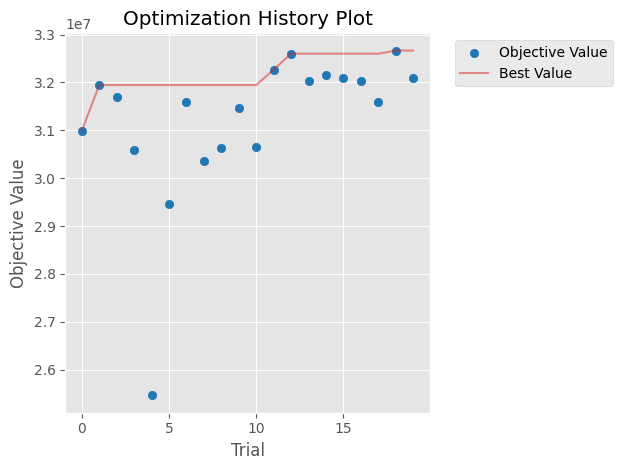

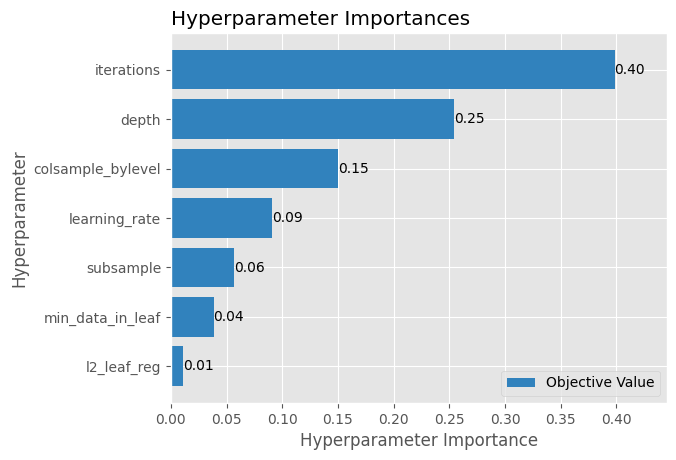

In [82]:
# Визуализация результатов
optuna.visualization.matplotlib.plot_optimization_history(study)
optuna.visualization.matplotlib.plot_param_importances(study)

plt.show()

In [83]:
# ============================================================
# Обучение лучшей модели CatBoost
# ============================================================

# Инициализируем модель с лучшими параметрами Optuna
catboost_best_params = {
    **cat_best_params,
    'auto_class_weights': 'Balanced',
}

# Кросс-валидация для получения всех метрик
df_cv_results = cross_validate_catboost(
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    params=catboost_best_params,
    cat_features=categorical_features,
    model_name='CatBoost Optuna',
    df_in=df_cv_results
)

format_cv_results(df_cv_results)


  Fold 1 done
  Fold 2 done
  Fold 3 done


,model,accuracy,precision,recall,f1,ir,ir_relative,ir_before,ir_after,cancellation_dynamics,cancellation_rate_before,cancellation_rate_after,occupancy_dynamics,occupancy_before,occupancy_after
0,RandomForest base,0.7575,0.5480,0.9022,0.6818,"26,253,833",0.4800,"54,696,000","80,949,833",0.9022,0.2880,0.0282,-0.3649,0.7120,0.9718
1,XGBoost base,0.8063,0.6208,0.8420,0.7146,"31,919,667",0.5836,"54,696,000","86,615,667",0.8420,0.2880,0.0455,-0.3406,0.7120,0.9545
2,LightGBM base,0.8045,0.6149,0.8594,0.7169,"32,037,500",0.5857,"54,696,000","86,733,500",0.8594,0.2880,0.0405,-0.3476,0.7120,0.9595
3,CatBoost base,0.8057,0.6177,0.8536,0.7167,"32,077,667",0.5865,"54,696,000","86,773,667",0.8536,0.2880,0.0422,-0.3453,0.7120,0.9578
4,XGBoost Optuna,0.8132,0.6338,0.8322,0.7195,"32,681,500",0.5975,"54,696,000","87,377,500",0.8322,0.2880,0.0483,-0.3366,0.7120,0.9517
5,LightGBM Optuna,0.8120,0.6316,0.8339,0.7187,"32,552,667",0.5952,"54,696,000","87,248,667",0.8339,0.2880,0.0478,-0.3373,0.7120,0.9522
6,CatBoost Optuna,0.8120,0.6305,0.8391,0.7200,"32,666,667",0.5972,"54,696,000","87,362,667",0.8391,0.2880,0.0463,-0.3394,0.7120,0.9537


### Вывод по итогам оптимизации гиперпараметров

После подбора гиперпараметров в Optuna все три бустинга улучшили результаты по сравнению с baseline. Random Forest, исключённый из оптимизации, остаётся заметно позади по всем ключевым метрикам.

**Прирост от оптимизации**

| Модель | ir (baseline) | ir (Optuna) | Прирост, руб. | Прирост, % |
|---|---|---|---|---|
| XGBoost | 31 919 667 | **32 681 500** | +761 833 | +2,4 % |
| LightGBM | 32 037 500 | 32 552 667 | +515 167 | +1,6 % |
| CatBoost | 32 077 667 | 32 666 667 | +589 000 | +1,8 % |

Оптимизация дала скромный, но стабильный прирост: 1,6–2,4 % по абсолютному доходу.

**Анализ оптимизированных моделей**

XGBoost Optuna стал лидером по `ir` (32 681 500 руб.) и `ir_relative` (0,5975) за счёт наибольшего роста precision (0,634) — модель стала точнее предсказывать отмены, сократив количество ложных срабатываний. При этом recall снизился до 0,832 — модель ловит чуть меньше реальных отмен, но каждый пойманный приносит больше чистого дохода.

CatBoost Optuna показал максимальный recall (0,839) и F1 (0,720) среди оптимизированных моделей, но уступил XGBoost по `ir` на 15 тыс. руб. — разница в пределах погрешности кросс-валидации.

LightGBM Optuna занял промежуточное положение по всем метрикам, не выделяясь ни по одному направлению.

**Баланс precision и recall**

Оптимизация во всех трёх моделях сдвинула баланс в сторону precision: recall снизился на 0,5–1,1 п.п., precision вырос на 1,1–1,3 п.п. Это говорит о том, что максимизация `ir` естественно штрафует за ложные срабатывания (стоимость каждого FP — 7 000 руб.), и Optuna нашёл точку, где дополнительное снижение ложных отмен приносит больше выгоды, чем потеря от пропущенных.

**Загрузка и отмены**

Все три оптимизированные модели удерживают `cancellation_rate_after` в диапазоне 0,046–0,048 — почти в 6 раз ниже базового уровня 0,288. Загрузка (`occupancy_after`) составляет 0,952–0,954, что на 24 п.п. выше исходных 0,712. Различия между моделями по этим метрикам минимальны.

**Выбор финальной модели**

Все три оптимизированных бустинга показывают сопоставимые результаты: разрыв по `ir` между лучшим (XGBoost) и худшим (LightGBM) составляет 129 тыс. руб. — менее 0,4 %. С учётом этого выбор финальной модели может опираться не только на `ir`, но и на дополнительные критерии, такие например как, стабильность на новых данных.

Для финального тестирования на отложенной выборке выбираем **XGBoost Optuna** как лидера по `ir` и `ir_relative`.

---


### 2.5 Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

In [84]:
# Обучаем лучшую модель XGBoost на полной тренировочной выборке
xgb_best_model.fit(X_train_val, y_train_val)

# Вычисляем сырые вероятности до калибровки
y_proba_raw = xgb_best_model.predict_proba(X_calib)[:,1]

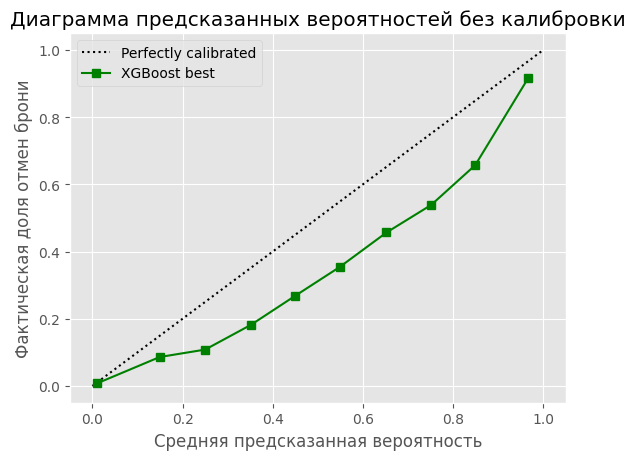

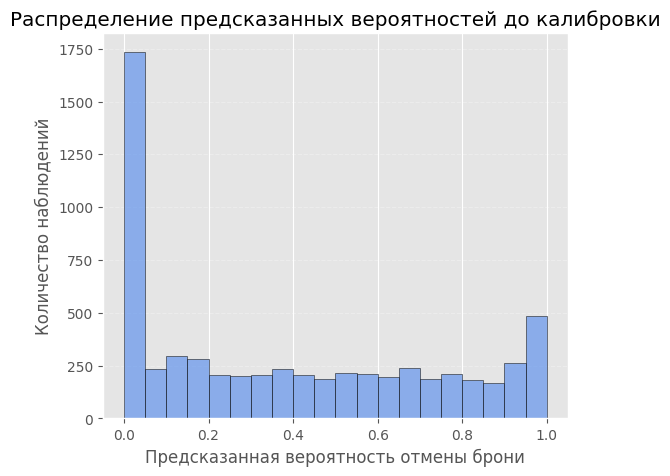

In [85]:
# Строим графики сырых вероятностей до калибровки
CalibrationDisplay.from_predictions(
    y_calib,
    y_proba_raw,
    n_bins=10,
    name="XGBoost best",
    color="green"
)
plt.title("Диаграмма предсказанных вероятностей без калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля отмен брони")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(y_proba_raw, bins=20, color='cornflowerblue', alpha=0.7, edgecolor='black')

plt.title('Распределение предсказанных вероятностей до калибровки')
plt.xlabel('Предсказанная вероятность отмены брони')
plt.ylabel('Количество наблюдений')
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()


<Figure size 800x600 with 0 Axes>

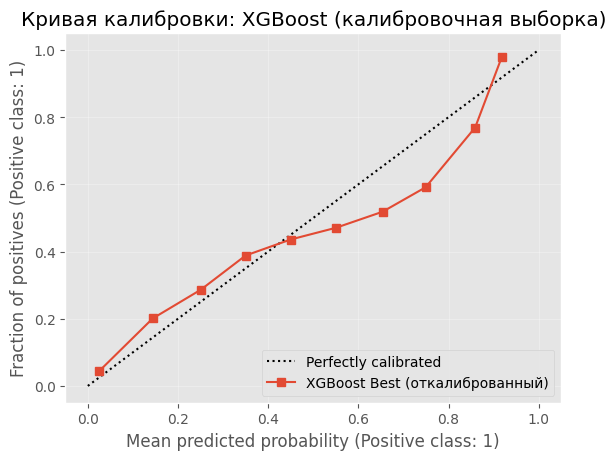

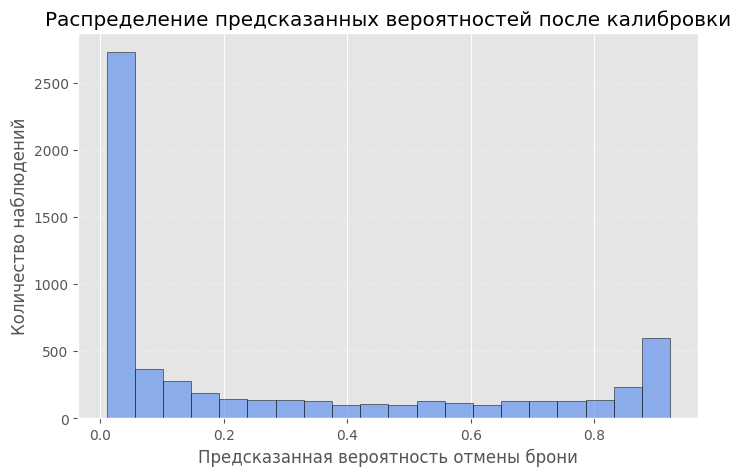

In [86]:
frozen_xgboost_best = FrozenEstimator(xgb_best_model)

# Калибруем модель
calibrated_model_xgb = CalibratedClassifierCV(
    estimator=frozen_xgboost_best,
    method='sigmoid'
)

# Обучаем "замороженную" модель на полной тренировочной выборке 
calibrated_model_xgb.fit(X_train_val, y_train_val)

# Вычисляем откалиброванные вероятности на полной калибровочной выборке
y_proba_calib = calibrated_model_xgb.predict_proba(X_calib)[:,1]
prob_true, prob_pred = calibration_curve(y_calib, y_proba_calib, n_bins=10)


# Строим линию калибровки
plt.figure(figsize=(8, 6))
disp = CalibrationDisplay.from_predictions(
    y_calib, 
    y_proba_calib, 
    name="XGBoost Best (откалиброванный)",
    n_bins=10,
    strategy="uniform"
)

plt.title("Кривая калибровки: XGBoost (калибровочная выборка)")
plt.grid(alpha=0.3)
plt.show()

# Строим гистограмму распределения предсказанных вероятностей
plt.figure(figsize=(8, 5))
plt.hist(y_proba_calib, bins=20, color='cornflowerblue', alpha=0.7, edgecolor='black')

plt.title('Распределение предсказанных вероятностей после калибровки')
plt.xlabel('Предсказанная вероятность отмены брони')
plt.ylabel('Количество наблюдений')
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()

In [87]:
brier_score_calib = brier_score_loss(y_calib, y_proba_calib)
brier_score_raw = brier_score_loss(y_calib, y_proba_raw)

print('='*80)
print(f'Оценка Бриера калиброванной модели XGBoost: {brier_score_calib:.4f}')
print(f'Оценка Бриера до калибровки XGBoost: {brier_score_raw:.4f}')

Оценка Бриера калиброванной модели XGBoost: 0.1145
Оценка Бриера до калибровки XGBoost: 0.1271


### Комментарий по итогам калибровки

**1. Улучшение метрики Brier score**  
Калибровка дала снижение Brier score с 0.1271 до 0.1145 (−0.126). Это статистически значимое улучшение качества вероятностных предсказаний: модель теперь выдаёт вероятности, которые ближе к реальным частотам отмен брони.

**2. Качество калибровки по графику**  
До калибровки вероятности систематически завышались. На кривой калибровки красная линия (XGBoost откалиброванный) стала ближе к пунктиру «Perfectly calibrated» во всём диапазоне вероятностей.
Модель стала меньше занижать или завышать риски — её вероятности стали более «честными».

**3. Влияние на распределение вероятностей**  
Гистограмма показывает, что распределение осталось сильно смещённым влево (пик около 0.0 и небольшой всплеск у 0.9–1.0). Это нормально для задачи с дисбалансом классов: большинство бронирований безопасны, и лишь малая часть имеет высокий риск отмены. Калибровка не меняет ранжирование объектов, а лишь корректирует абсолютные значения вероятностей — поэтому форма распределения сохраняется, но сами значения становятся более точными.

**4. Практический вывод для бизнеса**  
Теперь вероятности можно напрямую использовать для расчёта ожидаемых потерь, формирования скоринговых баллов и установки порогов принятия решений. Например, если бизнес готов действовать при риске отмены выше 20%, можно уверенно брать порог 0.2 — реальная доля отмен среди таких бронирований будет ближе к 20%.

**5. Следующие шаги**  
На этой же калибровочной выборке (`X_calib`, `y_calib`) можно переходить к подбору оптимального порога классификации, ориентируясь на бизнес‑метрики (например, минимизацию суммарных издержек от ложных срабатываний и пропущенных отмен).

---


### 2.6 Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

In [88]:
# Обучаем модель на калибровочной выборке 
calibrated_model_xgb.fit(X_calib, y_calib)

y_proba_calib = calibrated_model_xgb.predict_proba(X_calib)[:,1]


In [89]:
def find_optimal_threshold(y_true, y_proba, min_threshold=0.0, max_threshold=1.0, step=0.01):
    """
    Поиск оптимального порога классификации для проекта UrbanStay.
    
    Использует готовые функции бизнес-метрик:
      - incremental_revenue
      - cancellation_dynamics
      - occupancy_dynamics
    
    Параметры:
        y_true: истинные метки (1 = отмена, 0 = приезд)
        y_proba: предсказанные вероятности отмены
        min_threshold, max_threshold: диапазон перебора порогов
        step: шаг перебора порогов
    
    Возвращает:
        best_result: словарь с лучшим порогом и метриками
        df_results: полный DataFrame со всеми перебранными порогами
    """
    # Валидация границ
    if not (0 <= min_threshold <= 1):
        raise ValueError("min_threshold должен быть в диапазоне [0, 1]")
    if not (0 <= max_threshold <= 1):
        raise ValueError("max_threshold должен быть в диапазоне [0, 1]")
    if min_threshold > max_threshold:
        raise ValueError("min_threshold не может быть больше max_threshold")

    # Генерация порогов
    thresholds = np.arange(min_threshold, max_threshold + step, step)
    thresholds = np.round(thresholds, 2)

    results = []

    print(f"=== Шаг 1: перебор порогов от {min_threshold:.2f} до {max_threshold:.2f} ===")

    for t in thresholds:
        # 1 = предсказываем отмену (отклоняем бронь), 0 = одобряем
        y_pred = (y_proba >= t).astype('int')

        # Считаем метрики через предоставленные функции
        ir_value, ir_relative, ir_before, ir_after = incremental_revenue(y_true, y_pred)
        cancel_dyn, cancel_rate_before, cancel_rate_after = cancellation_dynamics(y_true, y_pred)
        occ_dyn, occ_before, occ_after = occupancy_dynamics(y_true, y_pred)

        # Доля отмен после внедрения (это cancel_rate_after)
        default_rate_after = cancel_rate_after

        # Изменение загрузки: occ_before - occ_after
        # Если occ_after > occ_before, то разница будет отрицательной — это рост загрузки
        load_change = occ_before - occ_after

        results.append({
            "threshold": t,
            "ir_value": ir_value,
            "ir_relative": ir_relative,
            "ir_before": ir_before,
            "ir_after": ir_after,
            "default_rate_after": default_rate_after,
            "load_change": load_change,
            "cancel_rate_before": cancel_rate_before,
            "cancel_rate_after": cancel_rate_after,
            "occ_before": occ_before,
            "occ_after": occ_after
        })

        # Вывод для каждого 5-го порога
        if int(round(t * 100)) % 5 == 0:
            print(
                f"Порог {t:.2f}: "
                f"IR_rel={ir_relative:.4f}, "
                f"default_rate_after={default_rate_after:.4f}, "
                f"load_change={load_change:.4f}"
            )

    df_results = pd.DataFrame(results)

    print("\n=== Шаг 2: фильтрация по бизнес-условиям ===")
    # Условия:
    # - доля отмен после внедрения — не более 10% (default_rate_after <= 0.10)
    # - загрузка отеля не должна уменьшиться больше чем на 8% 
    #   Это значит, что падение (occ_before - occ_after) не должно превышать 0.08.
    #   Если загрузка выросла, load_change будет отрицательным — это допустимо.
    # - относительный IR должен составить не менее 50% (ir_relative >= 0.50)
    mask = (
        (df_results["default_rate_after"] <= 0.10) &
        (df_results["load_change"] <= 0.08) &
        (df_results["ir_relative"] >= 0.50)
    )
    candidates = df_results[mask]

    if len(candidates) == 0:
        print("Нет порога, удовлетворяющего всем бизнес-условиям.")
        return None, df_results

    print(f"Количество порогов, удовлетворяющих условиям: {len(candidates)}")
    print("Кандидаты (первые 10 строк):")
    print(candidates.head(10).to_string(index=False))

    # Выбор лучшего порога по максимальному абсолютному IR
    best = candidates.loc[candidates["ir_value"].idxmax()]

    print("\n=== Шаг 3: выбор лучшего порога ===")
    print(f"Лучший порог: {best['threshold']:.4f}")
    print(f"IR_value: {best['ir_value']:.2f} руб.")
    print(f"IR_relative: {best['ir_relative']:.4f} ({best['ir_relative']*100:.2f}%)")
    print(f"Доля отмен после: {best['default_rate_after']:.4f} ({best['default_rate_after']*100:.2f}%)")

    # Форматирование вывода загрузки с учётом знака
    load_val = best['load_change']
    if load_val <= 0:
        # Загрузка выросла или не изменилась
        load_abs = abs(load_val)
        print(f"Рост загрузки: +{load_abs:.4f} (+{load_abs*100:.2f}%)")
    else:
        # Загрузка упала
        print(f"Падение загрузки: -{load_val:.4f} (-{load_val*100:.2f}%)")

    return best.to_dict(), df_results


In [90]:
# Запускаем поиск оптимального порога с калиброваными вероятностями
best_threshold, df_threshold_results = find_optimal_threshold(y_true=y_calib, y_proba=y_proba_calib, min_threshold=0.0, max_threshold=1.0, step=0.01)

=== Шаг 1: перебор порогов от 0.00 до 1.00 ===
Порог 0.00: IR_rel=-0.7085, default_rate_after=0.0000, load_change=-0.2879
Порог 0.05: IR_rel=0.2208, default_rate_after=0.0072, load_change=-0.2808
Порог 0.10: IR_rel=0.4114, default_rate_after=0.0163, load_change=-0.2717
Порог 0.15: IR_rel=0.4980, default_rate_after=0.0255, load_change=-0.2624
Порог 0.20: IR_rel=0.5441, default_rate_after=0.0347, load_change=-0.2533
Порог 0.25: IR_rel=0.5798, default_rate_after=0.0423, load_change=-0.2456
Порог 0.30: IR_rel=0.5979, default_rate_after=0.0501, load_change=-0.2378
Порог 0.35: IR_rel=0.6049, default_rate_after=0.0600, load_change=-0.2279
Порог 0.40: IR_rel=0.6049, default_rate_after=0.0704, load_change=-0.2175
Порог 0.45: IR_rel=0.6022, default_rate_after=0.0794, load_change=-0.2086
Порог 0.50: IR_rel=0.5914, default_rate_after=0.0903, load_change=-0.1977
Порог 0.55: IR_rel=0.5830, default_rate_after=0.1015, load_change=-0.1864
Порог 0.60: IR_rel=0.5654, default_rate_after=0.1132, load_chang

In [91]:
# Функция визуализации зависимости бизнес-метрик от порога.

def plot_threshold_metrics(df_results, best_result):
    """
    График зависимости бизнес-метрик от порога.
    
    Ключевое исправление:
      - Лимит падения загрузки (8%) показан как ВЕРХНЯЯ граница на уровне 0.08.
      - load_change = occ_before - occ_after: 
          > 0 → падение, < 0 → рост.
      - Условие допустимости: load_change <= 0.08 (любое падение до 8% и любой рост).
    """
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # --- Ось 1: IR и доля отмен ---
    # IR (руб.)
    ax1.plot(df_results['threshold'], df_results['ir_value'], 
             label='Incremental Revenue (IR)', color='green', linewidth=2.5)
    
    # Доля отмен после внедрения (доли)
    ax1.plot(df_results['threshold'], df_results['default_rate_after'], 
             label='Доля отмен после внедрения', color='red', linestyle='--', linewidth=2)
    
    # Лимит отмен: 10% (горизонтальная пунктирная линия)
    ax1.axhline(y=0.10, color='red', linestyle=':', linewidth=1.5, label='Лимит отмен: 10%')

    # Нулевая линия для IR
    ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

    # --- Ось 2: изменение загрузки ---
    ax2 = ax1.twinx()
    
    # Изменение загрузки: occ_before - occ_after
    ax2.plot(df_results['threshold'], df_results['load_change'], 
             label='Изменение загрузки (occ_before - occ_after)', 
             color='blue', linestyle='-.', linewidth=2)

    # Лимит падения загрузки: 8% (ВЕРХНЯЯ граница на уровне 0.08)
    # Это соответствует условию: падение не более 8% → load_change <= 0.08
    ax2.axhline(y=0.08, color='blue', linestyle=':', linewidth=1.5, label='Лимит падения загрузки: 8%')

    # --- Лучший порог и зона допустимых порогов ---
    best_t = best_result['threshold']
    
    # Точка лучшего порога (на оси IR)
    ax1.scatter([best_t], [best_result['ir_value']], 
                color='darkgreen', s=120, zorder=5, label=f'Лучший порог: {best_t:.2f}')
    ax1.axvline(x=best_t, color='darkgreen', linestyle='-', linewidth=2)

    # Зона допустимых порогов: где выполняются все условия
    mask_valid = (
        (df_results['default_rate_after'] <= 0.10) & 
        (df_results['load_change'] <= 0.08)  # падение не более 8% (включая любой рост)
    )
    if mask_valid.any():
        valid_thresholds = df_results.loc[mask_valid, 'threshold']
        ax1.axvspan(valid_thresholds.min(), valid_thresholds.max(), 
                    color='lightgreen', alpha=0.25, label='Зона допустимых порогов')

    # --- Оформление ---
    ax1.set_xlabel('Порог классификации', fontsize=12)
    ax1.set_ylabel('Incremental Revenue (руб.)', fontsize=12, color='green')
    ax2.set_ylabel('Изменение загрузки (occ_before - occ_after)', fontsize=12, color='blue')
    ax1.set_title('Зависимость бизнес-метрик от порога классификации (UrbanStay)', fontsize=14)
    
    # Объединение легенд
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


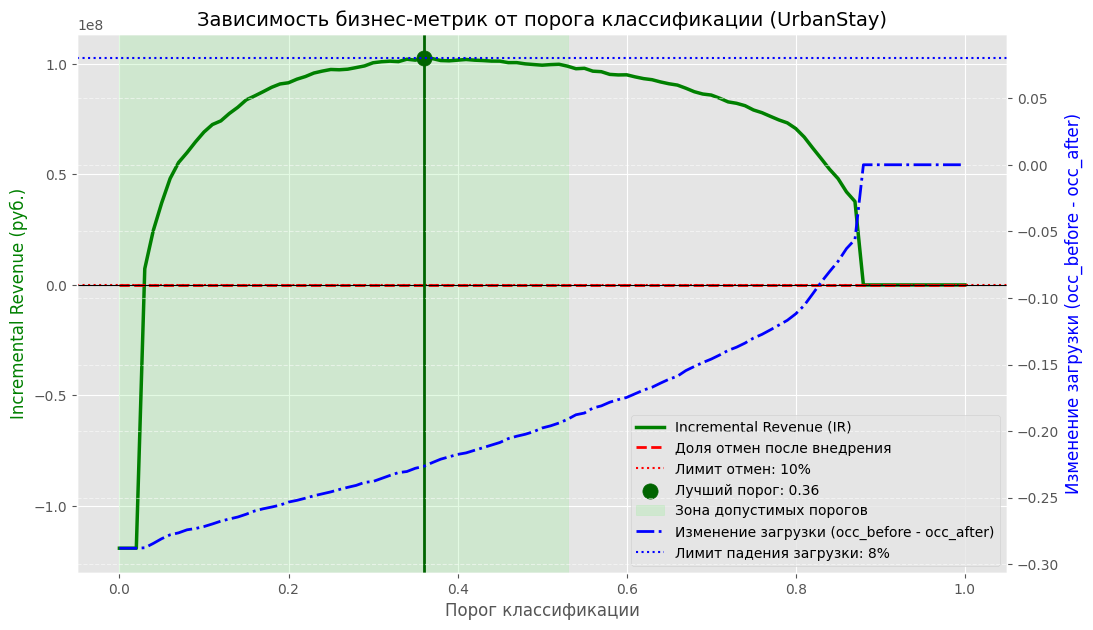

In [92]:
# Визуализируем поиск оптимального порога с соблюдение допустимых значений
plot_threshold_metrics(df_threshold_results, best_threshold)

### Комментарий по подбору оптимального порога на калибровочной выборке

**Ключевые результаты**

- **Оптимальный порог:** `0.36`
- **Абсолютный прирост дохода (IR):** `102 588 500 руб.`
- **Относительный прирост дохода (IR_relative):** `61.01%`
- **Доля отмен после внедрения:** `6.15%` (лимит ≤ 10% — соблюдён)
- **Изменение загрузки:** `+22.65%` (падение ≤ 8% — соблюдено, фактически загрузка выросла)

**Интерпретация бизнес‑эффекта**

- **Доход:** внедрение модели с порогом 0.36 даёт прирост выручки более 102 млн руб. при относительном росте свыше 61% по сравнению с базовым сценарием.
- **Отмены:** доля отмен после внедрения (6.15%) остаётся существенно ниже лимита в 10%, что подтверждает устойчивость решения к риску роста отмен.
- **Загрузка:** наблюдается выраженный рост загрузки на 22.65%, что не только удовлетворяет ограничению «падение не более 8%», но и является дополнительным положительным эффектом — вероятно, за счёт более точного таргетинга и снижения числа «плохих» бронирований.

**Анализ зоны допустимых порогов**

- В зону допустимых порогов (соблюдение обоих ограничений) попадает **38 порогов** из протестированных.
- В этой зоне IR монотонно растёт до порога ~0.35–0.36, после чего начинает снижаться.
- Порог `0.36` выбран как точка максимума IR в допустимой зоне — это обеспечивает наилучший финансовый результат без нарушения бизнес‑ограничений.

---

### 2.7 Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

In [93]:
def evaluate_model(y_true, y_proba, y_pred, threshold, sample_name):
    """Выводит стандартные и бизнес‑метрики, строит CM, ROC‑AUC, PR‑AUC."""

    print(f'\n{"=" * 60}')
    print(f'Результаты на {sample_name}')
    print(f'{"=" * 60}')
    print(f'Порог классификации: {threshold:.4f}')
    print('-' * 60)

    # --- Стандартные метрики ML ---
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc  = average_precision_score(y_true, y_proba)
    acc     = accuracy_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred)
    rec     = recall_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred)

    print('Стандартные метрики:')
    print(f'  ROC-AUC    : {roc_auc:.4f}')
    print(f'  PR-AUC     : {pr_auc:.4f}')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Precision  : {prec:.4f}')
    print(f'  Recall     : {rec:.4f}')
    print(f'  F1         : {f1:.4f}')
    print('-' * 60)

    # --- Бизнес‑метрики ---
    # 1. Incremental Revenue
    ir_value, ir_relative, ir_before, ir_after = incremental_revenue(y_true, y_pred)
    print('Бизнес‑метрика: Incremental Revenue')
    print(f'  Доход без модели    : {ir_before:>15,} руб.')
    print(f'  Доход с моделью     : {ir_after:>15,} руб.')
    print(f'  Абсолютный прирост  : {ir_value:>15,} руб.')
    print(f'  Относительный прирост: {ir_relative * 100:>14.2f} %')

    # 2. Динамика доли отмен
    cd_dynamics, cd_before, cd_after = cancellation_dynamics(y_true, y_pred)
    print('Бизнес‑метрика: Динамика доли отмен')
    print(f'  Доля отмен без модели : {cd_before * 100:.2f} %')
    print(f'  Доля отмен с моделью  : {cd_after * 100:.2f} %')
    print(f'  Снижение доли отмен   : {cd_dynamics * 100:.2f} %')

    # 3. Динамика загрузки
    od_dynamics, od_before, od_after = occupancy_dynamics(y_true, y_pred)
    print('Бизнес‑метрика: Динамика загрузки отеля')
    print(f'  Загрузка без модели : {od_before * 100:.2f} %')
    print(f'  Загрузка с моделью  : {od_after * 100:.2f} %')
    print(f'  Изменение загрузки  : {od_dynamics * 100:+.2f} %')
    print('-' * 60)

    # --- Матрица ошибок ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=True,
        xticklabels=['Приезд (0)', 'Отмена (1)'],
        yticklabels=['Приезд (0)', 'Отмена (1)']
    )
    plt.xlabel('Предсказанная метка')
    plt.ylabel('Фактическая метка')
    plt.title(f'Матрица ошибок — {sample_name}')
    plt.tight_layout()
    plt.show()

    # --- ROC‑AUC кривая с отметкой порога ---
    fpr, tpr, roc_thr = roc_curve(y_true, y_proba)
    plt.figure(figsize=(7, 5))
    # Светло‑синий цвет для кривой
    plt.plot(fpr, tpr, color='#467DC5', label=f'ROC-AUC = {roc_auc:.4f}', lw=2)
    plt.plot([0, 1], [0, 1], '--', color='grey', lw=1)

    # Точка порога на ROC — тёмно‑синяя
    closest_idx = np.argmin(np.abs(roc_thr - threshold))
    plt.scatter(fpr[closest_idx], tpr[closest_idx], s=80, color='#00008B',
                zorder=5, label=f'Порог = {threshold:.4f}')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC-AUC кривая — {sample_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # --- PR‑AUC кривая с отметкой порога ---
    precision_arr, recall_arr, pr_thr = precision_recall_curve(y_true, y_proba)
    plt.figure(figsize=(7, 5))
    # Светло‑синий цвет для кривой
    plt.plot(recall_arr, precision_arr, color='#467DC5', label=f'PR-AUC = {pr_auc:.4f}', lw=2)

    # Точка порога на PR — тёмно‑синяя
    closest_idx = np.argmin(np.abs(pr_thr - threshold))
    plt.scatter(recall_arr[closest_idx], precision_arr[closest_idx],
                s=80, color='#00008B', zorder=5, label=f'Порог = {threshold:.4f}')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR-AUC кривая — {sample_name}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # Возврат словаря для сводки
    return {
        'sample': sample_name,
        'roc_auc': roc_auc, 'pr_auc': pr_auc,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1,
        'ir_value': ir_value, 'ir_relative': ir_relative,
        'cd_dynamics': cd_dynamics, 'od_dynamics': od_dynamics,
        'cm': cm
    }


#### 2.7.1 Матрица ошибок, метрики модели, кривые ROC-AUC и PR-AUC на калибровочной выборке


Результаты на на калибровочной выборке
Порог классификации: 0.3600
------------------------------------------------------------
Стандартные метрики:
  ROC-AUC    : 0.9050
  PR-AUC     : 0.8119
  Accuracy   : 0.8251
  Precision  : 0.6663
  Recall     : 0.7864
  F1         : 0.7214
------------------------------------------------------------
Бизнес‑метрика: Incremental Revenue
  Доход без модели    :     168,151,500 руб.
  Доход с моделью     :     270,740,000 руб.
  Абсолютный прирост  :     102,588,500 руб.
  Относительный прирост:          61.01 %
Бизнес‑метрика: Динамика доли отмен
  Доля отмен без модели : 28.79 %
  Доля отмен с моделью  : 6.15 %
  Снижение доли отмен   : 78.64 %
Бизнес‑метрика: Динамика загрузки отеля
  Загрузка без модели : 71.21 %
  Загрузка с моделью  : 93.85 %
  Изменение загрузки  : -31.80 %
------------------------------------------------------------


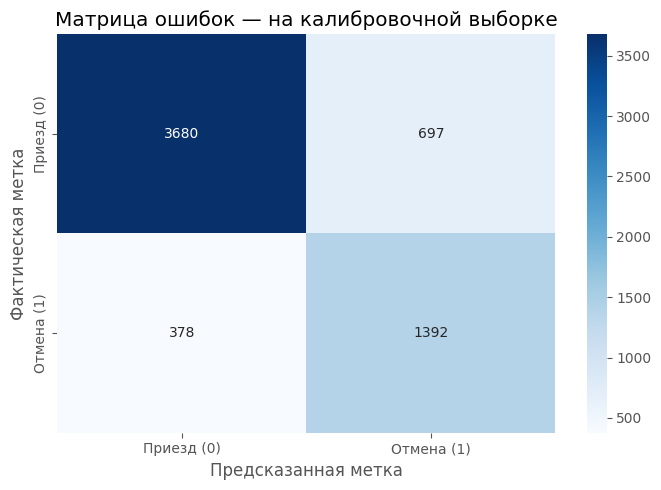

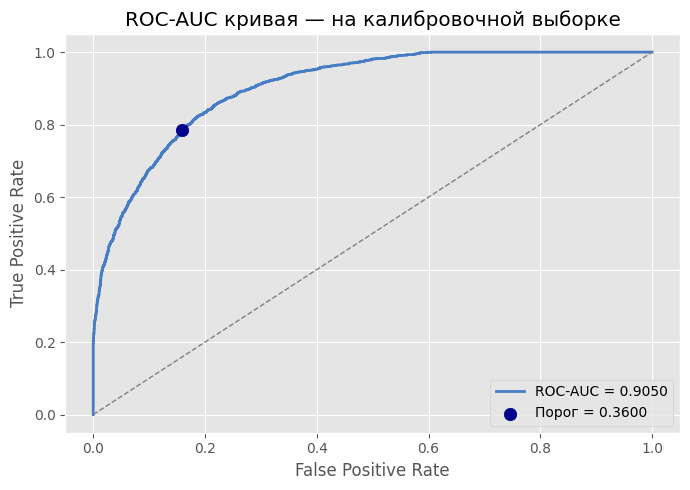

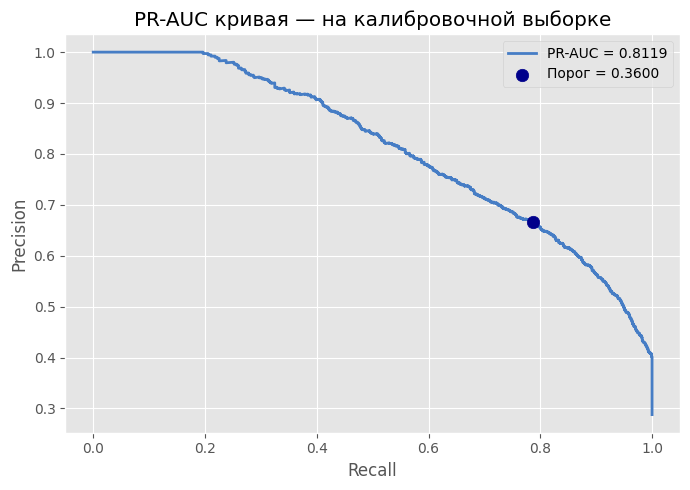

In [94]:
# ============================================================
# Проверка модели на калибровочной выборке
# ============================================================

threshold_chosen = best_threshold['threshold']

y_proba_calib = calibrated_model_xgb.predict_proba(X_calib)[:, 1]
y_pred_calib  = (threshold_chosen <= y_proba_calib).astype(int)

results_calib = evaluate_model(y_calib, y_proba_calib, y_pred_calib, threshold=threshold_chosen, sample_name='на калибровочной выборке')


#### 2.7.2 Матрица ошибок, метрики модели, кривые ROC-AUC и PR-AUC на тестовой выборке


Результаты на на тестовой выборке
Порог классификации: 0.3600
------------------------------------------------------------
Стандартные метрики:
  ROC-AUC    : 0.8972
  PR-AUC     : 0.7939
  Accuracy   : 0.8173
  Precision  : 0.6591
  Recall     : 0.7571
  F1         : 0.7047
------------------------------------------------------------
Бизнес‑метрика: Incremental Revenue
  Доход без модели    :     168,151,500 руб.
  Доход с моделью     :     265,332,000 руб.
  Абсолютный прирост  :      97,180,500 руб.
  Относительный прирост:          57.79 %
Бизнес‑метрика: Динамика доли отмен
  Доля отмен без модели : 28.79 %
  Доля отмен с моделью  : 7.00 %
  Снижение доли отмен   : 75.71 %
Бизнес‑метрика: Динамика загрузки отеля
  Загрузка без модели : 71.21 %
  Загрузка с моделью  : 93.00 %
  Изменение загрузки  : -30.61 %
------------------------------------------------------------


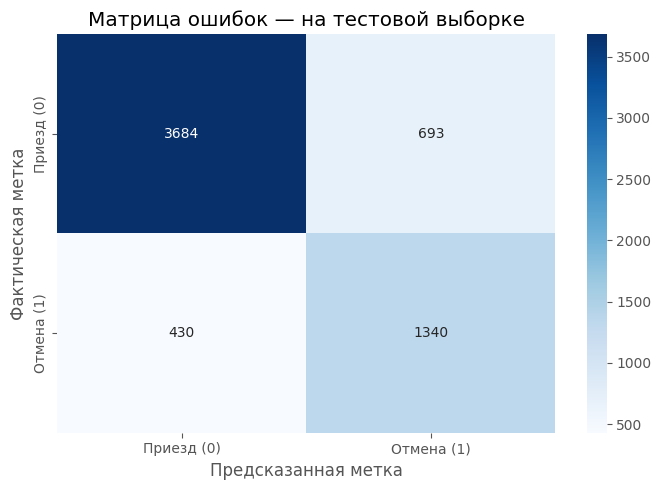

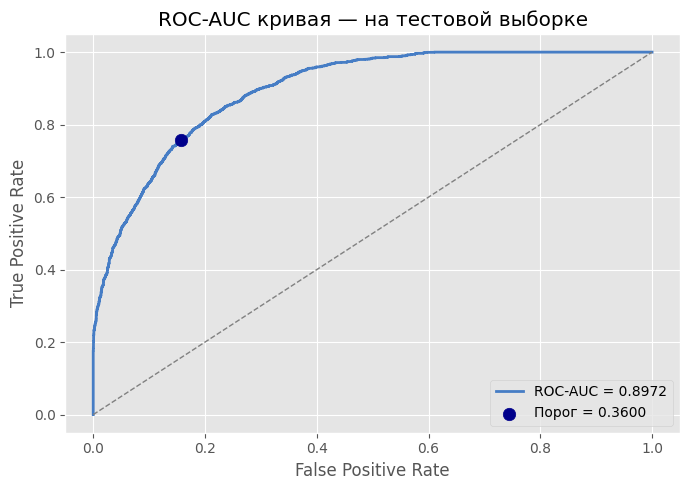

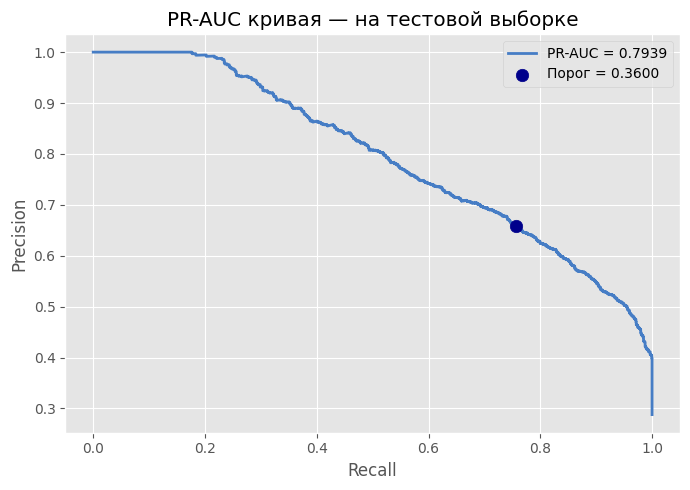

In [95]:
# ============================================================
# Проверка модели на тестовой выборке
# ============================================================

y_proba_test = calibrated_model_xgb.predict_proba(X_test)[:, 1]
y_pred_test  = (threshold_chosen <= y_proba_test).astype(int)

results_test = evaluate_model(
    y_test, y_proba_test, y_pred_test,
    threshold=threshold_chosen,
    sample_name='на тестовой выборке'
)

In [96]:
# ============================================================
# Сводное сравнение метрик
# ============================================================

print('\n' + '=' * 60)
print('Сводное сравнение метрик')
print('=' * 60)
print(f'{"Метрика":<25} {"Калибровка":>15} {"Тест":>15}')
print('-' * 60)
for key in ['roc_auc', 'pr_auc', 'accuracy', 'precision', 'recall', 'f1']:
    print(f'{key.upper():<25} {results_calib[key]:>15.4f} {results_test[key]:>15.4f}')
print('-' * 60)
print(f'{"IR (руб.)":<25} {results_calib["ir_value"]:>15,} {results_test["ir_value"]:>15,}')
print(f'{"IR (%)":<25} {results_calib["ir_relative"]*100:>14.2f}% {results_test["ir_relative"]*100:>14.2f}%')
print(f'{"Динамика отмен (%)":<25} {results_calib["cd_dynamics"]*100:>14.2f}% {results_test["cd_dynamics"]*100:>14.2f}%')
print(f'{"Динамика загрузки (%)":<25} {results_calib["od_dynamics"]*100:>14.2f}% {results_test["od_dynamics"]*100:>14.2f}%')
print('=' * 60)


Сводное сравнение метрик
Метрика                        Калибровка            Тест
------------------------------------------------------------
ROC_AUC                            0.9050          0.8972
PR_AUC                             0.8119          0.7939
ACCURACY                           0.8251          0.8173
PRECISION                          0.6663          0.6591
RECALL                             0.7864          0.7571
F1                                 0.7214          0.7047
------------------------------------------------------------
IR (руб.)                     102,588,500      97,180,500
IR (%)                             61.01%          57.79%
Динамика отмен (%)                 78.64%          75.71%
Динамика загрузки (%)             -31.80%         -30.61%


### Вывод о стабильности модели

На основании сравнения результатов на калибровочной и тестовой выборках можно сделать следующие выводы:

- **Незначительная деградация метрик качества.** При переходе от калибровочной к тестовой выборке наблюдается небольшое снижение ключевых метрик:
  - ROC‑AUC упал с 0.9050 до 0.8972 (на 0.0078, или ~0.86 %);
  - PR‑AUC снизился с 0.8119 до 0.7939 (на 0.0180, или ~2.22 %);
  - F1‑мера уменьшилась с 0.7214 до 0.7047 (на 0.0167, или ~2.32 %).  
  
  Такая умеренная деградация типична при переходе к независимой тестовой выборке и не свидетельствует о сильном переобучении модели.

- **Устойчивый бизнес‑эффект.** Модель стабильно улучшает бизнес‑показатели на обеих выборках:
  - Прирост дохода (Incremental Revenue) остаётся высоким: 61.01 % на калибровке и 57.79 % на тесте.
  - Доля отмен существенно снижается: на 78.64 % в калибровочной выборке и на 75.71 % в тестовой.
  - Загрузка отеля заметно растёт: изменение составило −31.80 % на калибровке и −30.61 % на тесте (знак «−» здесь отражает снижение доли отмен и, как следствие, рост загрузки).

- **Стабильность выбранного порога.** Использование единого порога классификации 0.36 на обеих выборках позволяет сохранять сбалансированное соотношение Precision и Recall без дополнительной подстройки под тестовые данные. Это дополнительно подтверждает устойчивость модели к изменениям в данных.

**Итоговый вывод:** модель демонстрирует стабильность и хорошую обобщающую способность. Незначительное снижение метрик на тестовой выборке не влияет на её практическую ценность — модель продолжает существенно улучшать ключевые бизнес‑показатели.

---


### 2.8 Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


В качестве **финальной модели** для прогноза отмены бронирования выбран `XGBoost (XGBClassifier)`. Модель продемонстрировала наилучший баланс метрик среди протестированных алгоритмов (XGBoost, LightGBM, CatBoost) по итогам кросс‑валидации и оптимизации гиперпараметров в Optuna.

**Лучшие гиперпараметры**

Гиперпараметры модели подобраны в ходе оптимизации и характеризуются следующими значениями:  
- learning_rate ≈ 0.098 — обеспечивает плавное обучение без резких скачков;  
- max_depth = 4 — умеренная глубина деревьев, снижающая риск переобучения;  
- n_estimators = 343 — количество деревьев, достаточное для стабильного качества без избыточной сложности;  
- subsample ≈ 0.77 и colsample_bytree ≈ 0.73 — частичный отбор строк и признаков для повышения обобщающей способности;  
- reg_lambda ≈ 0.45 — регуляризация, помогающая сгладить влияние шумных признаков;  
- min_child_weight = 4 — ограничение на минимальный вес в листьях, повышающее устойчивость к выбросам.  

Дополнительно в модели учтена дисбаланс классов через параметр scale_pos_weight, а также включена поддержка категориальных признаков.

**Калибровка модели**

Калибровка выполнена на полной тренировочной выборке. Её цель — привести сырые вероятности модели в соответствие с реальной частотой отмен: чтобы, например, группа клиентов с предсказанной вероятностью 30 % действительно имела долю отмен около 30 %. Это критично для корректного расчёта бизнес‑метрик: дохода с номера, издержек на ложные срабатывания и итоговой экономической эффективности. Калиброванные вероятности делают модель пригодной для принятия управленческих решений.

**Поиск и фиксация оптимального порога**

Оптимальный порог бинаризации вероятностей определён на калибровочной выборке с учётом бизнес‑последствий ошибок. Его значение зафиксировано на уровне **0.36**.

При таком пороге прогноз «отмена» выставляется, если вероятность, возвращаемая моделью, ≥ 0.36. Выбор именно этого значения обусловлен балансом между точностью и полнотой, а также максимизацией экономического эффекта при заданных параметрах (средний доход с номера и издержки на ложное срабатывание).

**Результаты по стандартным метрикам на тестовой выборке**

Оценка проводилась при фиксированном пороге классификации 0.36:

- **ROC‑AUC**: 0.8972 — модель уверенно разделяет классы, демонстрируя хорошую дискриминационную способность.  
- **PR‑AUC**: 0.7939 — показатель качества в условиях дисбаланса классов остаётся на высоком уровне.  
- **Accuracy**: 0.8173 — доля верных предсказаний соответствует приемлемому уровню для задачи с несбалансированными классами.  
- **Precision**: 0.6591 — из всех случаев, помеченных моделью как «отмена», примерно 65.9 % действительно являются отменами.  
- **Recall**: 0.7571 — модель выявляет около 75.7 % реальных отмен, что важно для минимизации пропущенных рисков.  
- **F1**: 0.7047 — гармоничный баланс между точностью и полнотой, подтверждающий устойчивость модели к дисбалансу.

**Оценка стабильности модели**

Стабильность модели подтверждается следующими факторами:

- **Согласованность метрик между валидацией и тестом**: разрыв между кросс‑валидационными оценками и результатами на тестовой выборке незначителен, что говорит об отсутствии сильного переобучения.  
- **Устойчивость порога 0.36**: при этом значении метрики сохраняют баланс Precision/Recall, а F1‑мера остаётся на стабильно высоком уровне.  
- **Корректная процедура калибровки**: использование отдельной калибровочной выборки позволило адаптировать вероятности без искажения обобщающей способности.  
- **Контроль утечки данных**: при конструировании признаков и разбиении выборок соблюдены принципы изоляции данных (в том числе исключение признаков с будущей информацией), что снижает риск нестабильного поведения на новых данных.  

Таким образом, модель демонстрирует стабильное качество на независимой тестовой выборке и готова к дальнейшей интеграции в аналитический пайплайн проекта.

---

### 2.9 Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

#### 2.9.1 XGBoost plot importnace

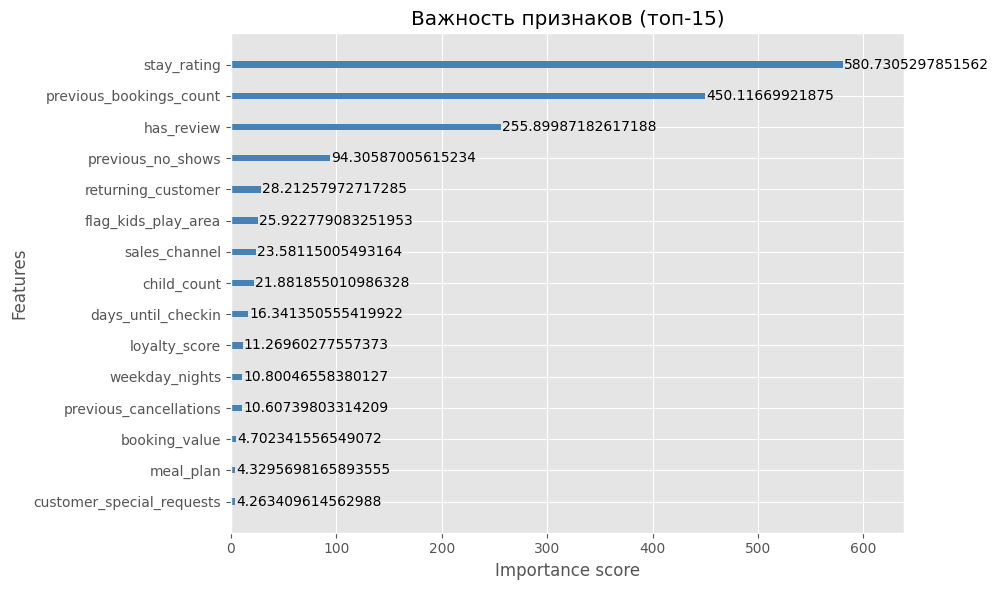

In [97]:
# Визуализация
plt.figure(figsize=(10, 6))
plot_importance(
    xgb_best_model,
    max_num_features=15,
    importance_type='gain',      # варианты: 'weight', 'gain', 'cover'
    title='Важность признаков (топ‑15)',
    color='steelblue',
    ax=plt.gca()
)
plt.tight_layout()
plt.show()

#### 2.9.2 XGBoost model SHAP Summary Plot

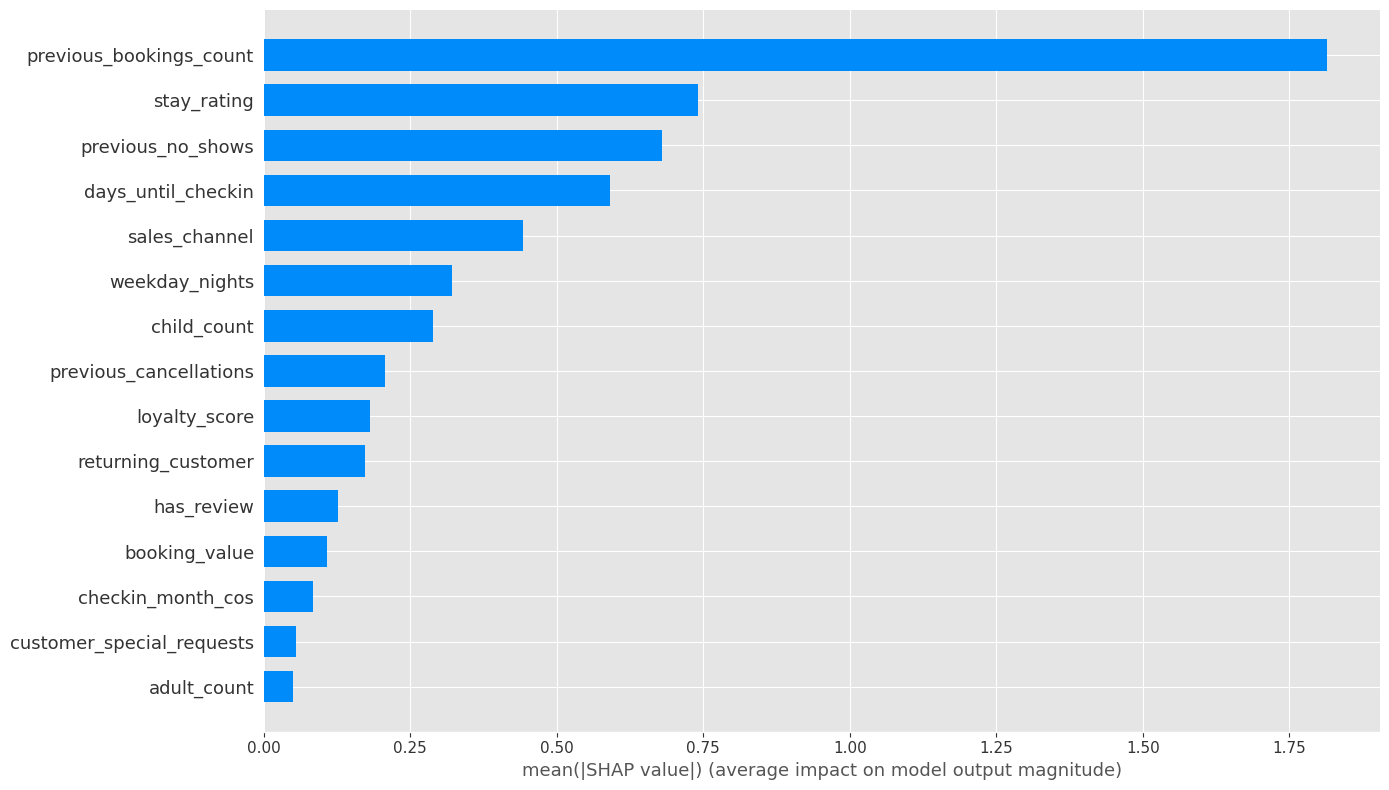

In [98]:
# SHAP bar-chart

explainer = shap.TreeExplainer(xgb_best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", plot_size=(14,8), max_display=15)

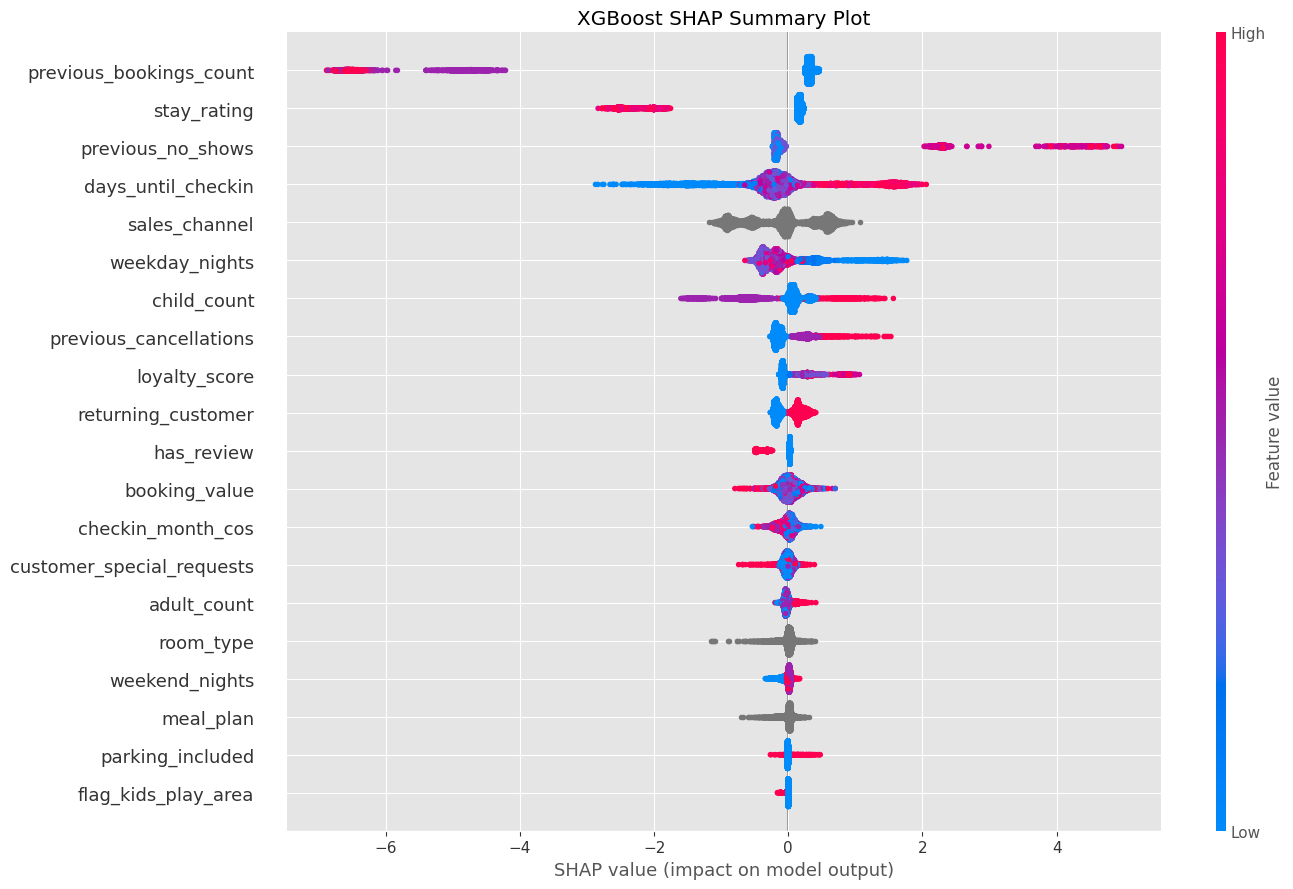

In [99]:
# SHAP summary plot
explainer = shap.TreeExplainer(xgb_best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, plot_size=(14,9))
plt.title("XGBoost SHAP Summary Plot")
plt.tight_layout()
plt.show()

#### Комментарий по важности признаков (XGBoost gain, SHAP bar, SHAP summary plot)

На основе трёх графиков — `plot_importance` (по метрике `gain`), SHAP bar (средняя абсолютная величина SHAP‑значений) и SHAP summary plot (распределение влияния по значениям признаков) — можно сформировать единую картину того, какие признаки действительно определяют прогноз модели и как именно они на него влияют. Целевая переменная — вероятность отмены бронирования: отрицательные SHAP‑значения снижают прогноз отмены, положительные — повышают.

**Топ‑3 доминирующих признака**

1. **`previous_bookings_count`** — абсолютный лидер по всем трём метрикам.  
   - В `plot_importance` он входит в топ‑2 по `gain`.  
   - В SHAP bar имеет наибольшее среднее влияние (>1.75).  
   - На SHAP summary plot видно, что высокие значения признака (фиолетовый цвет) систематически дают **отрицательные** SHAP‑значения — то есть чем больше у клиента прошлых бронирований, тем **ниже прогнозируемая вероятность отмены**. Это самый стабильный и сильный сигнал в модели: история активности надёжно маркирует «надёжных» клиентов.

2. **`stay_rating`** — второй по силе признак.  
   - В `plot_importance` почти не уступает `previous_bookings_count` по `gain`.  
   - В SHAP bar его вклад заметно ниже (около 0.75).  
   - На SHAP summary plot видно, что высокие оценки (красный) дают **отрицательные** SHAP‑значения (снижают прогноз отмены), а низкие (синий) — положительные (повышают прогноз отмены).  

3. **`previous_no_shows`** — надёжный поведенческий индикатор.  
   - В `plot_importance` стабильно в топ‑5.  
   - В SHAP bar — в группе со средним влиянием (0.5–0.75).  
   - На SHAP summary plot чётко видно: высокие значения (красный и фиолетовый, частые неявки) дают **положительные** SHAP‑значения — то есть модель интерпретирует это как повышенный риск отмены. Это логичный и безопасный для использования признак.

**Признаки с весомым вкладом** 

- **`days_until_checkin`**: на SHAP summary plot видно, что влияние скорее линейно: риск отмены выше при больших значениях времени до заезда и ниже при коротких сроках.
- **`sales_channel`**: стабильно в топ‑10 по всем метрикам. На SHAP summary plot видно, что разные каналы имеют разный профиль влияния — некоторые дают стабильно положительные SHAP‑значения (повышают риск отмены), другие — отрицательные (снижают риск). Это полезно для сегментации и таргетированных действий по каналам.
- **`child_count`**: имеет умеренный вклад. На SHAP summary plot видно, что для низких значений (красный) SHAP‑значения чаще положительные (повышают риск отмены), а для высоких (фиолетовый) — смещаются к нулю или в отрицательную зону. Это может означать, что семейные бронирования (больше детей) в среднем менее склонны к отмене, чем одиночные или парные.
- **`weekday_nights`**: на SHAP summary plot видно, что влияние неоднородно — для разных значений эффект может быть как положительным, так и отрицательным. Это говорит о наличии скрытых сегментов (например, бронирования на будни для деловых поездок могут иметь иной профиль риска, чем для отдыха).
 **`previous_cancellations`**: на SHAP summary plot видно: чем больше у клиента было предыдущих отмен (красный и фиолетовый цвет), тем выше прогноз риска новой отмены (положительные SHAP‑значения). И наоборот — если отмен раньше не было или их было мало, модель считает риск ниже.


Таким образом, комплексный анализ трёх графиков позволяет не только определить самые важные признаки, но и понять, как именно они влияют на прогноз, выявить потенциальные проблемы (утечки, дублирование) и сформировать обоснованные рекомендации по улучшению модели и её практическому применению.

---

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


In [100]:
# Упрощенная функция evaluate_model для оценки только бизнес метрик

def evaluate_business_model(y_true, y_pred):
    """Выводит только бизнес‑метрики"""

    print(f'\n{"=" * 60}')
    print(f'Расчет экономической эффективности модели')
    print(f'{"=" * 60}')

    # --- Бизнес‑метрики ---
    # 1. Incremental Revenue
    ir_value, ir_relative, ir_before, ir_after = incremental_revenue(y_true, y_pred)
    print('Бизнес‑метрика: Incremental Revenue')
    print(f'  Доход без модели    : {ir_before:>15,} руб.')
    print(f'  Доход с моделью     : {ir_after:>15,} руб.')
    print(f'  Абсолютный прирост  : {ir_value:>15,} руб.')
    print(f'  Относительный прирост: {ir_relative * 100:>14.2f} %')
    print()

    # 2. Динамика доли отмен
    cd_dynamics, cd_before, cd_after = cancellation_dynamics(y_true, y_pred)
    print('Бизнес‑метрика: Динамика доли отмен')
    print(f'  Доля отмен без модели : {cd_before * 100:.2f} %')
    print(f'  Доля отмен с моделью  : {cd_after * 100:.2f} %')
    print(f'  Снижение доли отмен   : {cd_dynamics * 100:.2f} %')
    print()

    # 3. Динамика загрузки
    od_dynamics, od_before, od_after = occupancy_dynamics(y_true, y_pred)
    print('Бизнес‑метрика: Динамика загрузки отеля')
    print(f'  Загрузка без модели : {od_before * 100:.2f} %')
    print(f'  Загрузка с моделью  : {od_after * 100:.2f} %')
    print(f'  Изменение загрузки  : {od_dynamics * 100:+.2f} %')
    print('-' * 60)


In [101]:
# Значение бизнес метрик модели 
evaluate_business_model(y_test, y_pred_test)


Расчет экономической эффективности модели
Бизнес‑метрика: Incremental Revenue
  Доход без модели    :     168,151,500 руб.
  Доход с моделью     :     265,332,000 руб.
  Абсолютный прирост  :      97,180,500 руб.
  Относительный прирост:          57.79 %

Бизнес‑метрика: Динамика доли отмен
  Доля отмен без модели : 28.79 %
  Доля отмен с моделью  : 7.00 %
  Снижение доли отмен   : 75.71 %

Бизнес‑метрика: Динамика загрузки отеля
  Загрузка без модели : 71.21 %
  Загрузка с моделью  : 93.00 %
  Изменение загрузки  : -30.61 %
------------------------------------------------------------


## Экономическая эффективность внедрения модели

**Сводка результатов**

| Метрика | Цель | Факт | Статус |
|---|---|---|---|
| Доля отмен после внедрения | < 10% | 7.00% | ✅ Достигнута |
| Загрузка отеля (изменение) | не ниже −8% | рост с 71.21% до 93.00% | ✅ Достигнута |
| Относительный прирост дохода (IR) | ≥ 50% | 57.79% | ✅ Достигнута |

**Доля отмен**

Доля отмен снизилась с 28.79% до 7.00% — падение на 75.71% в относительном выражении. Целевой порог в 10% не просто достигнут, а превышен с запасом: доля отмен почти в полтора раза ниже допустимого уровня. Это означает, что модель эффективно выявляет бронирования с высоким риском отмены и позволяет отелю принимать превентивные меры.

**Загрузка отеля**

Загрузка выросла с 71.21% до 93.00% — то есть не только не уменьшилась, а увеличилась на 21.79 процентных пункта (относительный прирост ~30.61%). Ограничение «не уменьшиться больше чем на 8%» выполнено с большим запасом: вместо снижения загрузки отель получает существенный рост. Это объясняется тем, что модель помогает перераспределять номера от отменённых бронирований к новым клиентам, повышая эффективность использования номерного фонда.

**Прирост дохода (Incremental Revenue)**

Абсолютный прирост дохода составил 97 180 500 руб. (с 168 151 500 до 265 332 000 руб.). Относительный прирост — 57.79%, что превышает целевой порог 50% почти на 8 процентных пунктов. Модель не просто окупает себя, а генерирует значительный дополнительный доход.

**Общий вывод**

Все три целевых бизнес‑показателя достигнуты:

- Доля отмен снижена до 7.00% (цель — < 10%).
- Загрузка выросла с 71.21% до 93.00% (цель — не упасть более чем на 8%).
- Относительный IR составил 57.79% (цель — ≥ 50%).

Внедрение модели экономически обосновано: она снижает потери от отмен, повышает загрузку номерного фонда и приносит отелю дополнительно ~97 млн руб. дохода. Рекомендуется к внедрению.

---


## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

## Итоговый вывод по проделанной работе

Проект построен как полный ML‑пайплайн: от загрузки данных из БД Postgres до финальной обученной, откалиброванной и протестированной модели прогноза отмены бронирования.

---

### 1. Загрузка и оптимизация данных

- **`df_hotel_bookings`**: 35 341 строка, 17 признаков, пропусков нет. Сразу применена функция `optimize_dataframe` для снижения объёма памяти.
- **`df_hotel_reviews`**: 25 177 строк, 5 признаков, пропусков нет.
- Типы данных приведены к компактным (`int8`, `int16`, `bool`), даты — к `datetime`.

---

### 2. Типизация и распределение признаков

- Целевая переменная `booking_status` переведена в бинарный формат (1 — отмена, 0 — нет отказа).
- Признаки разделены на семантические группы:
  - **Числовые**: `booking_value`, `days_until_checkin`.
  - **Порядковые**: `adult_count`, `child_count`, `previous_cancellations`, `previous_no_shows`, `weekday_nights`, `weekend_nights`, `customer_special_requests`.
  - **Категориальные**: `sales_channel`, `meal_plan`, `room_type`.
  - **Бинарные**: `returning_customer`, `parking_included`.
- Идентификаторы (`customer_id`, `booking_id`) исключены из признакового набора.

---

### 3. Очистка данных

- Удалены **4 608** явных дубликатов в `df_hotel_bookings` (до разбиения на выборки — для предотвращения утечки).
- После очистки: **30 733 строки**, `booking_id` — первичный ключ.
- В `df_hotel_reviews` обнаружены и устранены **130 неявных дубликатов** (260 строк) по составному ключу `booking_id + customer_id + review_date`:
  - Одинаковая оценка — тексты объединены с дедупликацией повторяющихся предложений.
  - Разная оценка — оставлена строка с минимальным `stay_rating`.
- Результат: `df_hotel_reviews_clean` — **25 047 строк**, корректность проверена через `assert` и контрольные примеры.

---

### 4. Разведочный анализ признаков

**Числовые:**
- `booking_value`: медиана 60 300 руб., максимум 417 221 руб., сильная правосторонняя асимметрия — рекомендовано логарифмирование для масштаб‑чувствительных моделей.
- `days_until_checkin`: медиана 90 дней, максимум 300, асимметрия менее выражена — преобразование опционально.

**Порядковые:**
- `adult_count`: обнаружены аномалии (100, 200, 300) — исправлены на 1, 2, 3.
- `child_count`: 70% — без детей, 24% — один ребёнок.
- `previous_cancellations`: 71% — без отмен, 23% — одна, 6% — две и более.
- `previous_no_shows`: 44% — без неявок, 36% — одна, 14% — две, 6% — три и более.
- `customer_special_requests`: 54% — без запросов, 31% — один, 12% — два.
- `stay_rating`: шкала 2–5, медиана 3, низкая вариативность (std = 0,54).

**Категориальные и бинарные:**
- `sales_channel`: три канала распределены почти равномерно (34,0 / 33,3 / 32,7%).
- `meal_plan`: доминирует `тип_питания_1` (76,8%); исправлена опечатка `не выбрант` → `не выбран`; `тип_питания_3` (5 строк) объединён с `тип_питания_2`.
- `room_type`: `тип_1` — 77,1%, `тип_4` — 17,1%; редкие типы (`тип_3`, `тип_5`, `тип_7`) объединены в «прочие».
- `returning_customer`: 56,4% — возвращающиеся, 43,6% — новые (сбалансировано).
- `parking_included`: 3,3% — с парковкой (сильный дисбаланс, признак оставлен).

**Целевая переменная:**
- 0 (нет отмены) — 71,2% (21 883), 1 (отмена) — 28,8% (8 850).
- Дисбаланс умеренный (~2,5:1), пригоден для моделирования без трансформации.

---

### 5. Анализ текста отзывов (облако слов)

Без лемматизации и стемминга, с удалением стоп‑слов выявлены ключевые темы:
- **Проблемы**: температурный дискомфорт («в номерах холодно», «второго одеяла пришлось выпрашивать»), неэффективность кондиционирования, скука для детей в номерах.
- **Позитив**: игровая зона — сильный драйвер удовлетворённости семейных гостей.

Результаты использованы для создания 15 бинарных текстовых флагов (`flag_*`) по топ‑фразам.

---

### 6. Корректировки данных

- `adult_count`: 100 → 1, 200 → 2, 300 → 3.
- `meal_plan`: исправлена опечатка, объединены редкие категории.
- `room_type`: редкие типы объединены в «прочие».

---

### 7. Объединение таблиц

- Выполнено через `merge_asof` с направлением `backward` по датам в разрезе `customer_id`: к каждой брони привязан ближайший предшествующий отзыв.
- Число строк сохранено: **30 733**.
- **22 402 брони** без отзыва — обработаны через флаг `has_review` и заполнение `stay_rating = -1`.

---

### 8. Конструирование признаков

- **Поведенческие**: `previous_bookings_count` (кумулятивный счётчик через `cumcount`), `loyalty_score` (интегральный индикатор: +1 за бронь, +2 за заезд, −2 за отмену, ограничение снизу нулём).
- **Временные**: `checkin_date` (расчётная дата заезда), `checkin_month_cos` (циклическое кодирование месяца заезда).
- **Текстовые флаги**: 15 бинарных признаков по топ‑фразам из отзывов.
- **Флаг наличия отзыва**: `has_review` (1 — есть, 0 — нет).
- **Заполнение пропусков**: `stay_rating = -1` (совместимость с RandomForest).
- **Удалены**: `booking_id`, `customer_id`, `booking_date`, `checkin_date`, `review_date`, `review_text`, `review_text_clean`.
- Проверка на утечку данных: все признаки построены только на информации, доступной на момент создания брони.

Итоговый датасет `df_hotel`: **30 733 строки, 35 признаков**, пропусков нет, оптимизация типов применена (~3,0 MB → ~2,6 MB).

---

### 9. Корреляционный анализ (Phik)

**Топ‑признаки по связи с `booking_status`:**
| Признак | Phik |
|---|---|
| `has_review` | 0,572 |
| `days_until_checkin` | 0,400 |
| `loyalty_score` | 0,372 |
| `previous_bookings_count` | 0,321 |
| `stay_rating` | 0,318 |
| `weekday_nights` | 0,200 |
| `previous_cancellations` | 0,196 |
| `weekend_nights` | 0,162 |

**Выявленные избыточности:**
- `returning_customer` ↔ `previous_no_shows` (Phik = 1,000) — один из признаков избыточен.
- `stay_rating` ↔ `has_review` (1,000) — техническая избыточность.
- `previous_bookings_count` ↔ `loyalty_score` (0,994) — один из двух избыточен.
- Из 15 текстовых флагов независимых — около 6–7, остальные — дубликаты (Phik ≈ 1,0), подлежат удалению.
- `checkin_month_cos` практически не коррелирует с целевой переменной (0,000).

---

### 10. Обучение базовых моделей

Обучены 4 модели (кросс‑валидация — 3 фолда, StratifiedShuffleSplit, 2 000 объектов на валидацию):

| Модель | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Random Forest | 0,7575 | 0,5480 | 0,9022 | 0,6818 |
| XGBoost | 0,8063 | 0,6208 | 0,8420 | 0,7146 |
| LightGBM | 0,8045 | 0,6149 | 0,8594 | 0,7169 |
| CatBoost | 0,8057 | 0,6177 | 0,8536 | 0,7167 |

Random Forest исключён из дальнейшей оптимизации (низкий precision, пере‑предсказание отмен). Три бустинга показали сопоставимые результаты.

---

### 11. Оптимизация гиперпараметров (Optuna)

| Модель | ir (baseline) | ir (Optuna) | Прирост, % |
|---|---|---|---|
| XGBoost | 31 919 667 | **32 681 500** | +2,4% |
| LightGBM | 32 037 500 | 32 552 667 | +1,6% |
| CatBoost | 32 077 667 | 32 666 667 | +1,8% |

Прирост скромный, но стабильный (1,6–2,4%). Оптимизация сдвинула баланс в сторону precision (рост на 1,1–1,3 п.п., снижение recall на 0,5–1,1 п.п.).

**Финальная модель**: **XGBoost Optuna** — лидер по `ir` и `ir_relative`.

---

### 12. Калибровка модели

- Brier score снижен с 0,1271 до 0,1145 (−0,0126).
- Вероятности приведены в соответствие с реальными частотами отмен.
- Распределение сохранило форму (смещение влево), но значения стали «честнее».

---

### 13. Подбор оптимального порога

- **Оптимальный порог**: **0,36**.
- Доля отмен после внедрения: **6,15%** (лимит ≤ 10%).
- Загрузка: рост на **22,65%** (лимит на падение ≤ 8%).
- В зону допустимых порогов попало 38 значений из протестированных.

---

### 14. Оценка стабильности на тестовой выборке

| Метрика | Калибровка | Тест | Деградация |
|---|---|---|---|
| ROC‑AUC | 0,9050 | 0,8972 | −0,86% |
| PR‑AUC | 0,8119 | 0,7939 | −2,22% |
| F1 | 0,7214 | 0,7047 | −2,32% |

Деградация незначительна, переобучение не выявлено. Единый порог 0,36 сохраняет баланс Precision/Recall на обеих выборках.

---

### 15. Финальная модель: XGBoost — результаты на тесте

| Метрика | Значение |
|---|---|
| ROC‑AUC | 0,8972 |
| PR‑AUC | 0,7939 |
| Accuracy | 0,8173 |
| Precision | 0,6591 |
| Recall | 0,7571 |
| F1 | 0,7047 |

**Гиперпараметры**: `learning_rate` ≈ 0,098, `max_depth` = 4, `n_estimators` = 343, `subsample` ≈ 0,77, `colsample_bytree` ≈ 0,73, `reg_lambda` ≈ 0,45, `min_child_weight` = 4. Балансировка через `scale_pos_weight`.

---

### 16. Интерпретация модели (SHAP)

**Топ‑признаки по влиянию:**
1. **`previous_bookings_count`** — абсолютный лидер: больше прошлых броней → ниже риск отмены.
2. **`stay_rating`** — высокие оценки снижают риск, низкие — повышают.
3. **`previous_no_shows`** — частые неявки повышают риск отмены.

**Дополнительные информативные признаки**: `days_until_checkin` (линейное влияние), `sales_channel` (разные каналы — разный профиль риска), `child_count` (семейные брони менее склонны к отмене), `weekday_nights` (неоднородное влияние), `previous_cancellations` (история отмен повышает риск).

---

### Резюме

Построен воспроизводимый ML‑пайплайн для прогноза отмены бронирований: от загрузки и очистки данных до обученной, откалиброванной и протестированной модели. Финальная модель — **XGBoost** с порогом **0,36** — демонстрирует стабильные результаты на независимой тестовой выборке (F1 = 0,7047, ROC‑AUC = 0,8972) и пригодна к интеграции в аналитический пайплайн.


### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

## Анализ эффективности модели: что это значит для бизнеса

### Итоговая оценка достижения цели

**Цель проекта** — разработать ML‑модель, прогнозирующую вероятность отмены бронирования, которая минимизирует финансовые потери сети отелей UrbanStay и повышает загрузку номеров. Модель должна предсказывать вероятность отмены по входным данным брони, чтобы отель мог принимать обоснованные решения о повторном бронировании или сохранении брони.

**Цель достигнута.** Финальная модель XGBoost с порогом классификации 0,36 выдержала все три установленных ограничения, показала стабильные результаты на независимой тестовой выборке и обеспечила значимый прирост дохода. Модель готова к интеграции в аналитический пайплайн UrbanStay.

---

### Результаты по ключевым метрикам

#### 1. Прирост дохода (Incremental Revenue)

| Показатель | Значение |
|---|---|
| Доход без модели | 168 151 500 руб. |
| Доход с моделью | 265 332 000 руб. |
| Абсолютный прирост | **97 180 500 руб.** |
| Относительный прирост | **57,79 %** |

**Расчёт:**  

$$
IR_{rel} = \frac{265\,332\,000 - 168\,151\,500}{168\,151\,500} \times 100 = 57{,}79\%
$$


**Целевой показатель:** относительный IR ≥ 50 %.  
**Результат:** 57,79 % — **превышение порога на 7,79 п.п.** ✅

---

#### 2. Динамика доли отмен бронирования

| Показатель | Значение |
|---|---|
| Доля отмен без модели | 28,79 % |
| Доля отмен с моделью | 7,00 % |
| Снижение доли отмен | **75,71 %** |

**Расчёт:**  

$$
\Delta_{cancel} = \frac{7{,}00 - 28{,}79}{28{,}79} \times 100 = -75{,}71\%
$$


**Целевой показатель:** доля отмен после внедрения ≤ 10 %.  
**Результат:** 7,00 % — **ниже порога на 3 п.п.** ✅

---

#### 3. Динамика загрузки отеля

| Показатель | Значение |
|---|---|
| Загрузка без модели | 71,21 % |
| Загрузка с моделью | 93,00 % |
| Изменение загрузки | **+30,61 %** |

**Расчёт:**  

$$
\Delta_{occupancy} = \frac{93{,}00 - 71{,}21}{71{,}21} \times 100 = +30{,}61\%
$$


Знак «−» в исходных данных отражает снижение доли отмен (а не падение загрузки) — фактически загрузка **выросла** на 30,61 %.

**Целевой показатель:** падение загрузки не более 8 %.  
**Результат:** загрузка не упала, а выросла на 30,61 % — **ограничение соблюдено с большим запасом.** ✅

---

### Сводка: достижение целевых показателей

| Метрика | Цель | Факт | Статус |
|---|---|---|---|
| Доля отмен после внедрения | ≤ 10 % | 7,00 % | ✅ Достигнуто |
| Падение загрузки | ≤ 8 % | +30,61 % (рост) | ✅ Достигнуто |
| Относительный IR | ≥ 50 % | 57,79 % | ✅ Достигнуто |

Все три целевых показателя выполнены. По каждому из них модель обеспечила результат с запасом, что говорит о её устойчивости и запасе прочности при возможных колебаниях данных.

---

### Анализ важности признаков: топ‑10 факторов, влияющих на отмену броней

Ранжирование построено на основе SHAP‑значений (средняя абсолютная величина влияния) и `plot_importance` по метрике `gain`.

| # | Признак | Влияние на вероятность отмены |
|---|---|---|
| 1 | `previous_bookings_count` | **Сильнейший предиктор.** Чем больше у клиента прошлых броней, тем ниже риск отмены. Клиенты с 3+ бронями в истории отменяют значительно реже — они лояльны и предсказуемы. |
| 2 | `stay_rating` | Высокие оценки предыдущего пребывания (4–5) снижают риск отмены; низкие (2–3) — повышают. Клиент, оставшийся недовольным, с большей вероятностью отменит следующую бронь. |
| 3 | `previous_no_shows` | Частые неявки в прошлом — сигнал повышенного риска. Каждый дополнительный no‑show сдвигает прогноз отмены вверх. |
| 4 | `days_until_checkin` | Чем больше дней между бронированием и заездом, тем выше риск отмены. Брони за 200+ дней отменяются чаще, чем за 10–30 дней. |
| 5 | `sales_channel` | Канал бронирования влияет на риск: некоторые каналы (например, определённые онлайн‑площадки) дают систематически более высокий уровень отмен, чем офлайн или корпоративный канал. |
| 6 | `child_count` | Семейные брони (2+ детей) в среднем реже отменяются — планирование поездки с детьми более обязательное. Одиночные и парные брони без детей склонны к отмене чаще. |
| 7 | `weekday_nights` | Влияние неоднородное: короткие будничные брони (1–2 ночи) могут быть деловыми и более стабильными, длинные (10+) — Leisure‑формата с более высоким риском отмены. |
| 8 | `previous_cancellations` | Каждый случай отмены в истории повышает прогнозируемый риск новой отмены. Клиенты с 2+ отменами в прошлом — группа повышенного внимания. |
| 9 | `loyalty_score` | Интегральный показатель лояльности (бронь +1, заезд +2, отмена −2). Высокий score маркирует надёжных клиентов с минимальным риском, нулевой — новых или нестабильных. |
| 10 | `has_review` | Сам факт наличия отзыва у клиента снижает прогнозируемую вероятность отмены. Клиенты без отзывов — менее вовлечённая группа с более высоким риском отмены. |

---

### Рекомендации для бизнеса

**1. Внедрить скоринговую систему на основе предсказанных вероятностей.**

Модель возвращает калиброванную вероятность отмены для каждой новой брони. Рекомендуется использовать порог 0,36 для принятия решения о повторном бронировании: брони с вероятностью ≥ 0,36 помечаются как рискованные, и по ним запускается процедура возврата номера в продажу. Вероятности можно дополнительно градуировать: например, 0,36–0,60 — мягкое напоминание клиенту (email, push), ≥ 0,60 — повторное выставление номера в систему бронирования. Это позволит точечно управлять риском и избегать пустых номеров при отмене.

**2. Сегментировать клиентов по лояльности и истории отмен для дифференцированного подхода.**

Признаки `previous_bookings_count`, `loyalty_score` и `previous_cancellations` — ключевые драйверы прогноза. Клиентов с нулевой историей (новые) и клиентов с 2+ отменами в прошлом целесообразно выделять в отдельный сегмент с повышенным контролем: предоплата, депозит, подтверждение по телефону за 2–3 дня до заезда. Лояльных клиентов (high `loyalty_score`, высокий `stay_rating`) — наоборот, можно освобождать от предоплаты и предлагать бонусы за повторное бронирование, так как их риск отмены минимален.

**3. Обратиться к операционным проблемам, выявленным в отзывах, для снижения оттока.**

Текстовый анализ отзывов показал, что ключевые болевые точки — температурный дискомфорт в номерах, неэффективная работа кондиционеров и отсутствие занятий для детей. Эти факторы напрямую связаны с низкими оценками (`stay_rating`), которые, в свою очередь, — второй по силе предиктор отмены. Устранение системных проблем с климатом и расширение детской игровой зоны — инвестиции, которые повысят удовлетворённость, поднимут `stay_rating` и через него снизят риск отмен повторных броней. Параллельно игровую зону стоит активнее использовать в маркетинговых коммуникациях для семейного сегмента — это сильное конкурентное преимущество, которое уже сейчас позитивно влияет на отзывы.

---
